In [1]:
COMPETITION_MODE = False
ROBOT_ID = 27

EVAL_STATUS_LOG_EVERY_STEP = True
EVAL_TIME_LIMIT_SEC = 181.0
FINAL_EVAL_STATUS_ON_EXIT = True

STREAM_WITH_EVAL_OVERLAY = False

if COMPETITION_MODE:
    ROBOT_NAME = f"competition"
else:
    ROBOT_NAME = f"robot{ROBOT_ID}"

RL_MODEL_FILENAME = "offline_rl_candidate_aware_qsafe_w500.pt"

# motion / timing
Z_PICK = 0.0
Z_SAFE = 0.30

In [2]:

from pathlib import Path
import os
import sys
import re
import time
import math
import json
import yaml
from glob import glob
from typing import Any, Dict, Optional, Iterable, Sequence

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Bootstrap: RGMC project root
# =========================================================
def find_project_root(start: Path) -> Path:
    """
    Find repository root without depending on machine-specific absolute paths.

    Expected portable layout:
        <PROJECT_ROOT>/src/task2
        <PROJECT_ROOT>/src/models
        <PROJECT_ROOT>/src/calibration
        <PROJECT_ROOT>/src/cloudgripper-api

    This also tolerates execution from:
        <PROJECT_ROOT>/exec/task2
        <PROJECT_ROOT>/src/task2
        <PROJECT_ROOT>/notebooks/...
    """
    start = Path(start).resolve()
    checked = []
    for p in [start, *start.parents]:
        checked.append(str(p))
        src = p / "src"
        if src.exists() and (src / "task2").exists():
            return p
    raise RuntimeError(
        f"Directory does not exists. start={start}, "
        "expected markers: src/, configs/, data/, exec/."
    )


def first_existing_dir(candidates: Sequence[Path], fallback: Path) -> Path:
    for p in candidates:
        p = Path(p).resolve()
        if p.exists() and p.is_dir():
            return p
    return Path(fallback).resolve()


def first_existing_file(candidates: Sequence[Path]) -> Optional[Path]:
    for p in candidates:
        p = Path(p).resolve()
        if p.exists() and p.is_file():
            return p
    return None


def add_sys_path(path: Path) -> None:
    path = Path(path).resolve()
    if path.exists():
        s = str(path)
        if s in sys.path:
            sys.path.remove(s)
        sys.path.insert(0, s)


def add_parent_if_module_exists(module_filename: str, roots: Sequence[Path]) -> None:
    """Add parent directory of module_filename.py if found under any root."""
    filename = module_filename if module_filename.endswith(".py") else f"{module_filename}.py"
    for root in roots:
        root = Path(root).resolve()
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            add_sys_path(root)
            return
        for found in root.rglob(filename):
            add_sys_path(found.parent)
            return


CWD = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CWD)

SRC_ROOT = PROJECT_ROOT / "src"
TASK2_DIR = SRC_ROOT / "task2"
CALIBRATION_DIR = SRC_ROOT / "calibration"
COMMON_DIR = SRC_ROOT / "common"
COMMON_CAMERA_DIR = COMMON_DIR / "camera"
MODELS_ROOT = SRC_ROOT / "models"

# These folders may not exist in the current RGMC2026 layout, so resolve them flexibly.
CONFIG_ROOT = first_existing_dir(
    [PROJECT_ROOT / "configs", PROJECT_ROOT / "config", SRC_ROOT / "configs", SRC_ROOT / "config"],
    PROJECT_ROOT / "configs",
)
DATA_ROOT = first_existing_dir(
    [PROJECT_ROOT / "data", SRC_ROOT / "data", PROJECT_ROOT / "exec" / "data"],
    PROJECT_ROOT / "data",
)
NOTEBOOK_ROOT = first_existing_dir(
    [PROJECT_ROOT / "notebooks", PROJECT_ROOT / "notebook", PROJECT_ROOT / "exec" / "notebooks"],
    PROJECT_ROOT / "notebooks",
)

# cloudgripper folder in this repo uses a hyphen: src/cloudgripper-api
CLOUDGRIPPER_API_DIR = SRC_ROOT / "cloudgripper-api"
CLOUDGRIPPER_API_ALT_DIR = SRC_ROOT / "cloudgripper_api"
CLOUDGRIPPER_CLIENT_CANDIDATE_DIRS = [
    CLOUDGRIPPER_API_DIR,
    CLOUDGRIPPER_API_DIR / "client",
    CLOUDGRIPPER_API_DIR / "src",
    CLOUDGRIPPER_API_DIR / "cloudgripper_api",
    CLOUDGRIPPER_API_ALT_DIR,
    CLOUDGRIPPER_API_ALT_DIR / "client",
    CLOUDGRIPPER_API_ALT_DIR / "src",
]

# Put repo-local modules before site-packages.
for p in [
    TASK2_DIR,
    SRC_ROOT,
    CALIBRATION_DIR,
    COMMON_DIR,
    COMMON_CAMERA_DIR,
    MODELS_ROOT,
    *CLOUDGRIPPER_CLIENT_CANDIDATE_DIRS,
]:
    add_sys_path(p)

# Also search for known standalone modules and add their parent folders.
add_parent_if_module_exists("cloudgripper_client", [SRC_ROOT, CLOUDGRIPPER_API_DIR, CLOUDGRIPPER_API_ALT_DIR])
add_parent_if_module_exists("pixel_to_workspace", [SRC_ROOT, COMMON_DIR, COMMON_CAMERA_DIR])
add_parent_if_module_exists("state_homography", [SRC_ROOT, TASK2_DIR])
add_parent_if_module_exists("der_nonmouse", [SRC_ROOT, TASK2_DIR])

print("CWD                :", CWD)
print("PROJECT_ROOT       :", PROJECT_ROOT)
print("SRC_ROOT           :", SRC_ROOT, SRC_ROOT.exists())
print("TASK2_DIR          :", TASK2_DIR, TASK2_DIR.exists())
print("CALIBRATION_DIR    :", CALIBRATION_DIR, CALIBRATION_DIR.exists())
print("COMMON_CAMERA_DIR  :", COMMON_CAMERA_DIR, COMMON_CAMERA_DIR.exists())
print("CLOUDGRIPPER_API   :", CLOUDGRIPPER_API_DIR, CLOUDGRIPPER_API_DIR.exists())
print("MODELS_ROOT        :", MODELS_ROOT, MODELS_ROOT.exists())
print("CONFIG_ROOT        :", CONFIG_ROOT, CONFIG_ROOT.exists())
print("DATA_ROOT          :", DATA_ROOT, DATA_ROOT.exists())

# =========================================================
# .env load
# =========================================================
try:
    from dotenv import load_dotenv
    ENV_PATH = PROJECT_ROOT / ".env"
    load_dotenv(ENV_PATH)
    print("dotenv loaded from:", ENV_PATH, ENV_PATH.exists())
except Exception as e:
    print("dotenv not used:", repr(e))

# =========================================================
# Imports
# =========================================================
from cloudgripper_client import GripperRobot
from pixel_to_workspace import PixelToWorkspaceMapper
from calibration.detector import YOLOGripperDetector
import importlib
import torch


def mean_node_error_mm(current_points, goal_points):
    current_points = np.asarray(current_points, dtype=np.float32)
    goal_points = np.asarray(goal_points, dtype=np.float32)
    return float(np.mean(np.linalg.norm(current_points - goal_points, axis=1)) * 1000.0)


def rmse_mm(current_points, goal_points):
    current_points = np.asarray(current_points, dtype=np.float32)
    goal_points = np.asarray(goal_points, dtype=np.float32)
    return float(np.sqrt(np.mean(np.sum((current_points - goal_points) ** 2, axis=1))) * 1000.0)


# =========================================================
# User settings
# =========================================================
# COMPETITION_MODE and ROBOT_ID are defined in Cell 0.
# False: connect directly to robot{ROBOT_ID}, use data/map/robot{ROBOT_ID}/lut.pkl.
# True : connect through "competition", call competition_start("task2") in Cell 2,
#        then select the assigned robot's LUT from data/lut_candidates/.

TASK_NAME = "task2"

CLOUDGRIPPER_TOKEN = os.getenv("CLOUDGRIPPER_TOKEN")
if not CLOUDGRIPPER_TOKEN:
    raise RuntimeError("CLOUDGRIPPER_TOKEN not set.")

EXPECTED_NUM_NODES = 20
REVERSE_NODE_ORDER = True
GRASPABLE_INDEX_MIN = 3
GRASPABLE_INDEX_MAX = 19
GRASP_ANGLE_WINDOW = 2

# =========================================================
# Runtime angle alignment
# =========================================================
# 기존 방식처럼 잡기 전에는 current rope tangent 각도로 정렬한다.
# 아래 옵션은 grasp가 완료된 뒤, current tangent와 goal tangent를 섞은 각도로
# gripper를 추가 회전시키는 execution-level 보정이다.
ANGLE_ALIGN_AFTER_GRASP_ENABLED = True
ANGLE_ALIGN_BEFORE_RELEASE_ENABLED = True
ANGLE_ALIGN_ALPHA = 0.6  # 보수적 운용: 0=current tangent 유지, 1=goal tangent 완전 정렬
# 잡은 뒤 회전 방향 보정값.
# +1.0: current -> goal 방향으로 회전
# -1.0: 실제 로봇에서 반대로 꺾일 때 사용하는 보정. pre-pick grasp 각도에는 영향 없음.
ANGLE_ALIGN_BLEND_SIGN = 1.0  # fallback only; curvature-guided mode overrides this per-step

# Curvature-guided after-grasp rotation direction
# 기존 방식: current tangent -> goal tangent의 최단 방향으로 회전.
# 수정 방식: 선택 node 이전 구간의 signed curvature 차이를 보고,
#          곡률이 목표 상태에 가까워지는 방향으로 회전한다.
ANGLE_ALIGN_USE_CURVATURE_GUIDED_DIRECTION = False  # 보수적 운용: curvature sign bias 비활성화
ANGLE_ALIGN_CURVATURE_WINDOW = 5
ANGLE_ALIGN_CURVATURE_EPS = 1e-3
# uv 좌표계는 v축이 아래로 증가하므로 signed curvature 부호가 화면 직관과 반대일 수 있다.
# 실제 회전 방향이 반대로 보이면 이 값을 -1.0으로 바꾼다.
ANGLE_ALIGN_CURVATURE_SIGN = 1.0
# robot.rotate(angle)가 절대각 명령만 받기 때문에, 원하는 방향을 유도하기 위해
# after-grasp 회전을 여러 개의 작은 절대각 command로 쪼개서 보낸다.
ANGLE_ALIGN_USE_INTERMEDIATE_ROTATE_COMMANDS = True
ANGLE_ALIGN_INTERMEDIATE_STEP_DEG = 15.0
# robot.rotate(angle)은 0~180 절대각 command로 동작한다고 보고,
# after-grasp 회전 중 이 범위를 넘으려 하면 wrap하지 않고 0 또는 180에서 멈춘다.
# 예: 3도에서 -30도 방향으로 가려 하면 169도로 wrap하지 않고 0도에서 정지.
ANGLE_ALIGN_CLAMP_TO_SERVO_RANGE = True
ANGLE_ALIGN_ROTATE_MIN_DEG = 0.0
ANGLE_ALIGN_ROTATE_MAX_DEG = 180.0
# Maximum after-grasp servo rotation allowed in one alignment plan.
# This prevents long-arc rotations such as 0 -> 155 when the equivalent
# short direction is physically outside the 0~180 servo range.
ANGLE_ALIGN_MAX_ABS_DELTA_DEG = 100.0  # 보수적 운용: 120 -> 100 deg

# Geometry diagnostics only. These values are logged every step and do not change control.
ANGLE_ALIGN_GEOMETRY_LOGGING_ENABLED = True
ANGLE_ALIGN_GEOMETRY_WINDOW = 2
ANGLE_ALIGN_GEOMETRY_AREA_EPS = 1e-6

# Geometry risk summary thresholds.
# Risk now considers sign mismatch + magnitude + overshoot + local direction reversal.
GEOM_RISK_DIR_DEADBAND_DEG = 10.0
GEOM_RISK_DELTA_DEADBAND_DEG = 10.0
GEOM_RISK_MEDIUM_DELTA_DEG = 10.0
GEOM_RISK_HIGH_DELTA_DEG = 45.0
GEOM_RISK_VERY_HIGH_DELTA_DEG = 90.0
GEOM_RISK_LARGE_ROTATE_DEG = 90.0
GEOM_RISK_OVERSHOOT_DEG = 30.0
GEOM_RISK_OVERSHOOT_MIN_DELTA_DEG = 60.0
GEOM_RISK_DIRECTION_REVERSAL_DEG = 150.0
GEOM_RISK_CENTER_NODE_MIN = 6
GEOM_RISK_CENTER_NODE_MAX = 14
GEOM_RISK_ENDPOINT_NODE_MIN = 18
GEOM_RISK_IGNORE_AREA_FOR_ENDPOINT = True
GEOM_RISK_WARN_LEVELS = ("HIGH", "VERY_HIGH")

# Conservative runtime safety gate.
# Risk does not change grasp/translation action. It only attenuates after-grasp rotation.
GEOM_RISK_CONTROL_ENABLED = True
GEOM_RISK_MEDIUM_ALPHA_SCALE = 0.75
GEOM_RISK_HIGH_ALPHA_SCALE = 0.40
GEOM_RISK_VERY_HIGH_ALPHA_SCALE = 0.0
GEOM_RISK_ENDPOINT_HIGH_ALPHA_SCALE = 0.25

ANGLE_ALIGN_DEBUG = True

MAX_STEPS = 100
STOP_MEAN_ERROR_MM = 6.0

# task2 collector 기준 fallback action bounds
DEFAULT_ACTION_X_MIN, DEFAULT_ACTION_X_MAX = 0.10, 0.84
DEFAULT_ACTION_Y_MIN, DEFAULT_ACTION_Y_MAX = 0.00, 1.00


# =========================================================
# Action workspace safety
# =========================================================
# When calibration yaml does not explicitly define action_x_min/action_x_max/action_y_min/action_y_max,
# derive action bounds from the calibrated workspace, not from the full [0,1] normalized plane.
# This prevents the policy from chasing target nodes that are outside the reachable LUT/workspace map.
ACTION_BOUNDS_FALLBACK_MODE = os.getenv("RGMC_ACTION_BOUNDS_FALLBACK_MODE", "workspace").strip().lower()
ACTION_WORKSPACE_EDGE_MARGIN = float(os.getenv("RGMC_ACTION_WORKSPACE_EDGE_MARGIN", "0.025"))
ACTION_PROJECT_TARGET_TO_REACHABLE_WORKSPACE = bool(int(os.getenv("RGMC_PROJECT_GOAL_POINTS_TO_WORKSPACE", "0")))
# Primary safety rule: only grasp current rope nodes that are inside the per-robot calibrated action workspace.
ACTION_FILTER_GRASP_NODES_BY_REACHABLE_WORKSPACE = True
ACTION_DEBUG_WORKSPACE_PROJECTION = True



WAIT_AFTER_MOVE_XY = 0.30
WAIT_AFTER_MOVE_Z_SAFE = 0.25
WAIT_AFTER_MOVE_Z_PICK = 0.45
WAIT_AFTER_GRIPPER_CLOSE = 0.35
WAIT_AFTER_DRAG_XY = 0.60
WAIT_AFTER_GRIPPER_OPEN = 0.45
WAIT_AFTER_ROTATE = 0.20
WAIT_AFTER_RELEASE_SETTLE = 0.50

OBS_RETRY_COUNT = 3
OBS_RETRY_SLEEP = 0.35

# LUT / homography paths.
LUT_CANDIDATE_DIR = DATA_ROOT / "lut_candidates"
HOMOGRAPHY_SIDECAR_DIR = DATA_ROOT / "lut_homography_sidecars"
LUT_GLOB = "lut_robot*.pkl"

ENABLE_HOMOGRAPHY_FALLBACK = True
HOMOGRAPHY_FALLBACK_CLAMP = False
HOMOGRAPHY_FALLBACK_VERBOSE = True
HOMOGRAPHY_FALLBACK_MAX_LOG = 10

# Passive LUT selection is only used if competition_start/status/state does not reveal
# the assigned robot name or the hinted robot does not have a matching candidate LUT.
USE_PASSIVE_LUT_SELECTION = bool(COMPETITION_MODE)
PRELOAD_LUT_CANDIDATES_BEFORE_START = bool(COMPETITION_MODE)
GRIPPER_DETECTOR_MODEL_PATH = MODELS_ROOT / "last.pt"
PASSIVE_LUT_WARN_ERR = 0.05

# Offline RL / QSafe model.
# Put the checkpoint in src/models/ or set env var RGMC_RL_MODEL.
RL_MODEL_PATH = MODELS_ROOT / RL_MODEL_FILENAME
RL_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRELOAD_RL_MODEL_BEFORE_START = True
rl_policy = None
rl_ckpt = None

for p in [MODELS_ROOT, MODELS_ROOT.parent]:
    add_sys_path(p)
if not RL_MODEL_PATH.exists():
    raise FileNotFoundError(f"Offline RL/QSafe model not found: {RL_MODEL_PATH}")

ENABLE_HOMOGRAPHY_FALLBACK = True
HOMOGRAPHY_FALLBACK_CLAMP = False
HOMOGRAPHY_FALLBACK_VERBOSE = True
HOMOGRAPHY_FALLBACK_MAX_LOG = 10



print("HOMOGRAPHY_SIDECAR_DIR :", HOMOGRAPHY_SIDECAR_DIR, HOMOGRAPHY_SIDECAR_DIR.exists())
print("RL_MODEL_PATH          :", RL_MODEL_PATH, RL_MODEL_PATH.exists())
print("RL_DEVICE              :", RL_DEVICE)

robot = GripperRobot(ROBOT_NAME, token=CLOUDGRIPPER_TOKEN)
print("robot connected:", ROBOT_NAME)

# Runtime map/LUT globals are initialized by Cell 2.
SELECTED_CANDIDATE = None
best_lut = None
lut_ranking = None
probe_logs = None
ASSIGNED_ROBOT_NAME = None
state_hint = None
state_hint_ts = None
workspace_cfg = None
mapper = None
COMPETITION_RUN_STARTED = False

# =========================================================
# Utility helpers
# =========================================================
def pretty_print(obj, title=None):
    if title:
        print(f"\n[{title}]")
    import pprint
    pprint.pprint(obj)

def show_bgr(img, title="image", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()
def unpack_robot_state_out(state_out):
    if isinstance(state_out, tuple):
        state, ts = state_out
    else:
        state, ts = state_out, None
    return state, ts

def get_robot_xy_from_state(state):
    return [float(state["x_norm"]), float(state["y_norm"])]

# ???
def safe_get_robot_state(robot, *, verbose=False, timeout=10):
    """
    Robust replacement for GripperRobot.get_state().

    The original cloudgripper_client.get_state() assumes that the API response
    always has keys ['state', 'timestamp']. In practice, the server can return
    an error payload without 'state' when the robot id is wrong, the robot is
    offline, the token is unauthorized, or the eval/session state is invalid.
    This wrapper surfaces the raw server response instead of raising KeyError.
    """
    from requests import get
    import pprint

    url = robot.base_api + "/getState"
    try:
        resp = get(url, headers=robot.headers, timeout=float(timeout))
    except Exception as e:
        raise RuntimeError(f"getState request failed: {repr(e)}") from e

    try:
        data = resp.json()
    except Exception as e:
        text = getattr(resp, "text", "")
        raise RuntimeError(
            "getState returned non-json response. "
            f"status_code={getattr(resp, 'status_code', None)}, text={text[:1000]}"
        ) from e

    if verbose:
        print("\n[getState raw response]")
        print("status_code:", getattr(resp, "status_code", None))
        pprint.pprint(data)

    if not isinstance(data, dict) or "state" not in data:
        raise RuntimeError(
            "getState response has no 'state' key. "
            "Likely causes: wrong ROBOT_ID, unauthorized/expired token, robot offline, "
            "or eval/session state not ready. "
            f"status_code={getattr(resp, 'status_code', None)}, raw_response={data}"
        )

    return data["state"], data.get("timestamp", None)

# ???
def get_stable_robot_state(
    robot,
    max_tries=8,
    interval=0.20,
    tol=0.01,
    required_consecutive=2,
):
    samples = []
    prev_xy = None
    stable_count = 0
    last_state = None
    last_ts = None

    for k in range(int(max_tries)):
        state, ts = safe_get_robot_state(robot, verbose=False)
        xy = get_robot_xy_from_state(state)

        samples.append({
            "try": int(k + 1),
            "xy": [float(xy[0]), float(xy[1])],
            "ts": ts,
        })

        if prev_xy is not None:
            dist = float(np.hypot(xy[0] - prev_xy[0], xy[1] - prev_xy[1]))
            if dist <= float(tol):
                stable_count += 1
            else:
                stable_count = 0

            if stable_count >= int(required_consecutive):
                return state, ts, True, samples

        prev_xy = xy
        last_state = state
        last_ts = ts

        if k < int(max_tries) - 1:
            time.sleep(float(interval))

    return last_state, last_ts, False, samples

# =========================================================
# Robot / LUT / workspace / homography helpers
# =========================================================
def _iter_nested(obj):
    if isinstance(obj, dict):
        for k, v in obj.items():
            yield k
            yield from _iter_nested(v)
    elif isinstance(obj, (list, tuple)):
        for item in obj:
            yield from _iter_nested(item)
    elif obj is not None:
        yield obj

def find_first_robot_name(obj: Any) -> Optional[str]:
    pat = re.compile(r"robot\d+", re.IGNORECASE)
    for v in _iter_nested(obj):
        s = str(v)
        m = pat.search(s)
        if m:
            robot_name = m.group(0).lower()
            digits = "".join(ch for ch in robot_name if ch.isdigit())
            return f"robot{int(digits)}"
    return None

def try_extract_assigned_robot_name(obj):
    if obj is None:
        return None

    candidate_keys = {
        "robot",
        "robot_name",
        "assigned_robot",
        "assigned_robot_name",
        "worker",
        "worker_name",
        "robot_id",
        "worker_id",
    }

    def _walk(o):
        if isinstance(o, dict):
            for k, v in o.items():
                if str(k) in candidate_keys:
                    if isinstance(v, str) and len(v.strip()) > 0:
                        return v
                    if isinstance(v, (int, np.integer)):
                        return f"robot{int(v)}"
                nested = _walk(v)
                if nested is not None:
                    return nested
        elif isinstance(o, (list, tuple)):
            for item in o:
                nested = _walk(item)
                if nested is not None:
                    return nested
        return None

    return _walk(obj) or find_first_robot_name(obj)


def normalize_robot_name(value):
    if value is None:
        return None
    s = str(value).strip()
    if not s:
        return None
    digits = "".join(ch for ch in s if ch.isdigit())
    if digits:
        return f"robot{int(digits)}"
    return s.lower()

def parse_robot_name_from_lut_filename(path: Path):
    path = Path(path)
    m = re.search(r"robot[_\-]?(\d+)", path.stem, flags=re.IGNORECASE)
    if m is None:
        raise ValueError(f"robot id parse failed from LUT filename: {path.name}")
    return f"robot{int(m.group(1))}"


def _first_existing_path(paths, default=None):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return default if default is not None else Path(paths[0])


def _candidate_robot_map_dir(robot_digits, robot_name):
    nozero_name = f"robot{int(robot_digits)}"
    padded_name = f"robot{int(robot_digits):02d}"
    candidates = [
        DATA_ROOT / "map" / nozero_name,
        DATA_ROOT / "map" / padded_name,
        DATA_ROOT / "map" / robot_name,
    ]
    return _first_existing_path(candidates, default=candidates[0])


def _candidate_calibration_yaml_path(robot_digits, robot_name):
    nozero_name = f"robot{int(robot_digits)}"
    padded_name = f"robot{int(robot_digits):02d}"
    candidates = [
        CONFIG_ROOT / "calibration" / f"calibration_{nozero_name}.yaml",
        CONFIG_ROOT / "calibration" / f"calibration_{padded_name}.yaml",
        CONFIG_ROOT / "calibration" / f"calibration_{robot_name}.yaml",
    ]
    return _first_existing_path(candidates, default=candidates[0])


def load_workspace_bounds_from_calibration_yaml(yaml_path: Path):
    yaml_path = Path(yaml_path)
    if not yaml_path.exists():
        raise FileNotFoundError(f"Calibration yaml not found: {yaml_path}")

    with open(yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    if not isinstance(data, dict):
        raise RuntimeError(f"Calibration yaml must load to dict: {yaml_path}")

    section_candidates = [
        "rope_calibration",
        "calibration",
        "task2_calibration",
        "task1_calibration",
        "planar_push_calibration",
    ]

    section_name = None
    section = None
    for name in section_candidates:
        cand = data.get(name, None)
        if isinstance(cand, dict) and all(k in cand for k in ["x_min", "x_max", "y_min", "y_max"]):
            section_name = name
            section = cand
            break

    if section is None:
        raise RuntimeError(
            f"x_min/x_max/y_min/y_max not found in calibration yaml: {yaml_path}"
        )

    x_min = float(section["x_min"])
    x_max = float(section["x_max"])
    y_min = float(section["y_min"])
    y_max = float(section["y_max"])

    if not (x_min < x_max and y_min < y_max):
        raise ValueError(
            f"Invalid workspace bounds in {yaml_path}: "
            f"x=({x_min}, {x_max}), y=({y_min}, {y_max})"
        )

    # Keep an inner safety margin so commands do not sit exactly on LUT/workspace boundaries.
    span_x = float(x_max - x_min)
    span_y = float(y_max - y_min)
    margin = max(0.0, float(ACTION_WORKSPACE_EDGE_MARGIN))
    margin = min(margin, 0.25 * span_x, 0.25 * span_y)

    safe_x_min = x_min + margin
    safe_x_max = x_max - margin
    safe_y_min = y_min + margin
    safe_y_max = y_max - margin

    # If the yaml explicitly provides action bounds, honor them but still clamp to the calibrated workspace.
    # Otherwise use either the calibrated workspace or the old legacy defaults depending on fallback mode.
    use_legacy_fallback = ACTION_BOUNDS_FALLBACK_MODE in {"legacy", "default", "collector"}

    if "action_x_min" in section:
        action_x_min_raw = float(section["action_x_min"])
    else:
        action_x_min_raw = float(DEFAULT_ACTION_X_MIN if use_legacy_fallback else safe_x_min)

    if "action_x_max" in section:
        action_x_max_raw = float(section["action_x_max"])
    else:
        action_x_max_raw = float(DEFAULT_ACTION_X_MAX if use_legacy_fallback else safe_x_max)

    if "action_y_min" in section:
        action_y_min_raw = float(section["action_y_min"])
    else:
        action_y_min_raw = float(DEFAULT_ACTION_Y_MIN if use_legacy_fallback else safe_y_min)

    if "action_y_max" in section:
        action_y_max_raw = float(section["action_y_max"])
    else:
        action_y_max_raw = float(DEFAULT_ACTION_Y_MAX if use_legacy_fallback else safe_y_max)

    action_x_min = max(action_x_min_raw, safe_x_min)
    action_x_max = min(action_x_max_raw, safe_x_max)
    action_y_min = max(action_y_min_raw, safe_y_min)
    action_y_max = min(action_y_max_raw, safe_y_max)

    if not (action_x_min < action_x_max and action_y_min < action_y_max):
        raise ValueError(
            f"Invalid action bounds after workspace safety clamp in {yaml_path}: "
            f"action_x=({action_x_min}, {action_x_max}), "
            f"action_y=({action_y_min}, {action_y_max}), "
            f"workspace_x=({x_min}, {x_max}), workspace_y=({y_min}, {y_max}), "
            f"margin={margin}"
        )

    return {
        "section_name": section_name,
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "action_x_min": float(action_x_min),
        "action_x_max": float(action_x_max),
        "action_y_min": float(action_y_min),
        "action_y_max": float(action_y_max),
        "action_workspace_margin": float(margin),
        "action_bounds_fallback_mode": str(ACTION_BOUNDS_FALLBACK_MODE),
        "action_bounds_source": "yaml+workspace_clamp" if any(k in section for k in ["action_x_min", "action_x_max", "action_y_min", "action_y_max"]) else f"{ACTION_BOUNDS_FALLBACK_MODE}+workspace_clamp",
    }

def _action_bounds(candidate):
    ws = candidate["workspace_cfg"]
    return {
        "x_min": float(ws["action_x_min"]),
        "x_max": float(ws["action_x_max"]),
        "y_min": float(ws["action_y_min"]),
        "y_max": float(ws["action_y_max"]),
    }

def project_xy_to_action_workspace(xy, candidate):
    """Project one xy command to the calibrated safe action workspace."""
    xy = np.asarray(xy, dtype=np.float32).reshape(2)
    b = _action_bounds(candidate)
    projected = np.array([
        np.clip(float(xy[0]), b["x_min"], b["x_max"]),
        np.clip(float(xy[1]), b["y_min"], b["y_max"]),
    ], dtype=np.float32)
    changed = bool(np.linalg.norm(projected - xy) > 1e-9)
    return projected, changed

def project_points_to_action_workspace(points, candidate):
    pts = np.asarray(points, dtype=np.float32)
    projected = np.empty_like(pts, dtype=np.float32)
    changed_mask = np.zeros((len(pts),), dtype=bool)
    for i, p in enumerate(pts):
        projected[i], changed_mask[i] = project_xy_to_action_workspace(p, candidate)
    return projected, changed_mask

def point_inside_action_workspace(xy, candidate, eps=1e-8):
    xy = np.asarray(xy, dtype=np.float32).reshape(2)
    if not np.isfinite(xy).all():
        return False
    b = _action_bounds(candidate)
    return bool(
        (b["x_min"] - eps <= float(xy[0]) <= b["x_max"] + eps)
        and (b["y_min"] - eps <= float(xy[1]) <= b["y_max"] + eps)
    )

def get_reachable_grasp_nodes(current_points, candidate, allowed_nodes=None, *, fallback_to_all=True):
    """
    Return node indices that are both schedule-allowed and physically reachable.
    If the schedule leaves no reachable node, fall back to all reachable graspable nodes.
    """
    pts = np.asarray(current_points, dtype=np.float32)
    n = len(pts)
    lo = max(0, int(GRASPABLE_INDEX_MIN))
    hi = min(n - 1, int(GRASPABLE_INDEX_MAX))

    if allowed_nodes is None:
        base_nodes = list(range(lo, hi + 1))
        schedule_restricted = False
    else:
        base_nodes = sorted({
            int(i) for i in allowed_nodes
            if lo <= int(i) <= hi
        })
        schedule_restricted = True

    reachable = [
        i for i in base_nodes
        if 0 <= i < n and point_inside_action_workspace(pts[i], candidate)
    ]

    fallback_used = False
    if len(reachable) == 0 and fallback_to_all and schedule_restricted:
        all_nodes = list(range(lo, hi + 1))
        reachable = [
            i for i in all_nodes
            if 0 <= i < n and point_inside_action_workspace(pts[i], candidate)
        ]
        fallback_used = len(reachable) > 0

    return reachable, {
        "base_nodes": list(map(int, base_nodes)),
        "reachable_nodes": list(map(int, reachable)),
        "schedule_restricted": bool(schedule_restricted),
        "fallback_to_all_reachable_used": bool(fallback_used),
    }

def nearest_reachable_node_index(current_points, candidate, xy, allowed_nodes=None):
    pts = np.asarray(current_points, dtype=np.float32)
    projected_xy, _ = project_xy_to_action_workspace(xy, candidate)
    reachable_nodes, info = get_reachable_grasp_nodes(
        pts,
        candidate,
        allowed_nodes=allowed_nodes,
        fallback_to_all=True,
    )
    if len(reachable_nodes) == 0:
        # Last-resort fallback. This should be rare; execute_rope_drag will still project commands.
        idx = int(np.argmin(np.linalg.norm(pts - projected_xy[None, :], axis=1)))
        info["no_reachable_node_fallback_idx"] = int(idx)
        return idx, info

    reach_pts = pts[np.asarray(reachable_nodes, dtype=int)]
    local = int(np.argmin(np.linalg.norm(reach_pts - projected_xy[None, :], axis=1)))
    return int(reachable_nodes[local]), info

def load_precomputed_homography_for_candidate(candidate):
    sidecar_path = Path(candidate["sidecar_path"])
    if not sidecar_path.exists():
        raise FileNotFoundError(f"Homography sidecar not found: {sidecar_path}")

    data = np.load(sidecar_path, allow_pickle=True)
    if "H_uv_to_xy" not in data:
        raise RuntimeError(f"'H_uv_to_xy' not found in sidecar: {sidecar_path}")

    H = np.asarray(data["H_uv_to_xy"], dtype=np.float64)
    if H.shape != (3, 3) or not np.isfinite(H).all():
        raise RuntimeError(f"Invalid homography matrix in {sidecar_path}: shape={H.shape}")

    info = {
        "sidecar_path": str(sidecar_path),
        "num_pairs": int(data["num_pairs"]) if "num_pairs" in data else None,
        "rmse_mean": float(data["rmse_mean"]) if "rmse_mean" in data else None,
        "rmse_max": float(data["rmse_max"]) if "rmse_max" in data else None,
        "source_kind": str(data["source_kind"]) if "source_kind" in data else None,
        "source_desc": str(data["source_desc"]) if "source_desc" in data else None,
    }
    return H, info

def _apply_homography_uv_to_xy(H, u, v, x_min, x_max, y_min, y_max):
    pt = np.array([float(u), float(v), 1.0], dtype=np.float64)
    proj = H @ pt
    w = float(proj[2])
    if abs(w) < 1e-12:
        raise RuntimeError(f"Homography projection is singular at (u={u}, v={v})")

    x = float(proj[0] / w)
    y = float(proj[1] / w)

    if HOMOGRAPHY_FALLBACK_CLAMP:
        x = float(np.clip(x, x_min, x_max))
        y = float(np.clip(y, y_min, y_max))

    return x, y

def _patch_mapper_convert_one_with_homography_fallback(mapper, H, x_min, x_max, y_min, y_max):
    original_convert_one = mapper.convert_one

    def _convert_one_with_fallback(self, u, v, *args, **kwargs):
        try:
            return original_convert_one(u, v, *args, **kwargs)
        except Exception as e:
            msg = str(e).lower()
            if ("outside" not in msg) and ("hull" not in msg):
                raise

            x_h, y_h = _apply_homography_uv_to_xy(H, u, v, x_min, x_max, y_min, y_max)

            count = getattr(self, "_homography_fallback_count", 0) + 1
            setattr(self, "_homography_fallback_count", count)

            if HOMOGRAPHY_FALLBACK_VERBOSE and count <= HOMOGRAPHY_FALLBACK_MAX_LOG:
                print(
                    f"[homography fallback #{count}] "
                    f"(u={float(u):.2f}, v={float(v):.2f}) -> "
                    f"(x={x_h:.4f}, y={y_h:.4f})"
                )
            return float(x_h), float(y_h)

    mapper._original_convert_one = original_convert_one
    mapper.convert_one = _convert_one_with_fallback.__get__(mapper, type(mapper))

def attach_homography_fallback_to_candidate(candidate):
    if candidate.get("homography_ready", False):
        return candidate["mapper"]

    H_UV_TO_XY, pre_info = load_precomputed_homography_for_candidate(candidate)

    workspace_cfg = candidate["workspace_cfg"]
    mapper = candidate["mapper"]

    _patch_mapper_convert_one_with_homography_fallback(
        mapper,
        H_UV_TO_XY,
        workspace_cfg["x_min"], workspace_cfg["x_max"],
        workspace_cfg["y_min"], workspace_cfg["y_max"],
    )

    candidate["homography_ready"] = True
    candidate["homography_info"] = {
        "enabled": True,
        "source": f"precomputed: {pre_info['sidecar_path']}",
        "num_pairs": pre_info.get("num_pairs"),
        "rmse_mean": pre_info.get("rmse_mean"),
        "rmse_max": pre_info.get("rmse_max"),
        "source_kind": pre_info.get("source_kind"),
        "source_desc": pre_info.get("source_desc"),
        "sidecar_path": pre_info.get("sidecar_path"),
        "H": H_UV_TO_XY,
    }

    print(
        f"[precomputed homography attached] {candidate['robot_name']} | "
        f"sidecar={pre_info['sidecar_path']} | "
        f"pairs={pre_info.get('num_pairs')} | "
        f"rmse_mean={pre_info.get('rmse_mean')} | "
        f"rmse_max={pre_info.get('rmse_max')}"
    )
    return mapper

def build_candidate_record(lut_path: Path, robot_name_override=None):
    lut_path = Path(lut_path)

    if robot_name_override is None:
        robot_name = parse_robot_name_from_lut_filename(lut_path)
    else:
        robot_name = normalize_robot_name(robot_name_override)

    robot_digits = "".join(ch for ch in str(robot_name) if ch.isdigit())
    if not robot_digits:
        raise ValueError(f"robot id parse failed from {robot_name}")

    robot_id_int = int(robot_digits)
    robot_name = f"robot{robot_id_int}"

    robot_map_dir = _candidate_robot_map_dir(robot_digits, robot_name)
    calibration_yaml_path = _candidate_calibration_yaml_path(robot_digits, robot_name)
    param_file = CONFIG_ROOT / "camera" / f"camera-params-cr{robot_id_int:02d}.yaml"

    workspace_cfg = load_workspace_bounds_from_calibration_yaml(calibration_yaml_path)

    mapper = PixelToWorkspaceMapper(
        str(lut_path),
        clamp_to_workspace=False,
        x_min=workspace_cfg["x_min"], x_max=workspace_cfg["x_max"],
        y_min=workspace_cfg["y_min"], y_max=workspace_cfg["y_max"],
    )

    sidecar_candidates = [
        HOMOGRAPHY_SIDECAR_DIR / f"{lut_path.stem}_homography.npz",
        HOMOGRAPHY_SIDECAR_DIR / f"lut_robot{robot_id_int:02d}_homography.npz",
        HOMOGRAPHY_SIDECAR_DIR / f"lut_robot{robot_id_int}_homography.npz",
        HOMOGRAPHY_SIDECAR_DIR / f"lut_{robot_name}_homography.npz",
        robot_map_dir / f"{lut_path.stem}_homography.npz",
    ]
    sidecar_path = _first_existing_path(sidecar_candidates, default=sidecar_candidates[0])

    return {
        "robot_name": robot_name,
        "robot_id": robot_id_int,
        "robot_digits": str(robot_id_int),
        "lut_path": lut_path,
        "robot_map_dir": robot_map_dir,
        "calibration_yaml_path": calibration_yaml_path,
        "param_file": param_file,
        "workspace_cfg": workspace_cfg,
        "mapper": mapper,
        "sidecar_path": sidecar_path,
        "sidecar_candidates": sidecar_candidates,
        "homography_ready": False,
        "homography_info": None,
    }

def preload_lut_candidates():
    lut_paths = sorted(Path(p) for p in glob(str(LUT_CANDIDATE_DIR / LUT_GLOB)))
    if len(lut_paths) == 0:
        raise FileNotFoundError(f"No LUT candidates found in {LUT_CANDIDATE_DIR / LUT_GLOB}")

    candidates = []
    errors = []
    for lut_path in lut_paths:
        try:
            rec = build_candidate_record(lut_path)
            candidates.append(rec)
        except Exception as e:
            errors.append((str(lut_path), repr(e)))

    if len(candidates) == 0:
        raise RuntimeError(f"All LUT candidate preload failed: {errors}")

    print(f"preloaded {len(candidates)} LUT candidates")
    for c in candidates:
        print(
            f" - {c['robot_name']} | {c['lut_path'].name} | "
            f"bounds=({c['workspace_cfg']['x_min']:.3f},{c['workspace_cfg']['x_max']:.3f},"
            f"{c['workspace_cfg']['y_min']:.3f},{c['workspace_cfg']['y_max']:.3f}) | "
            f"sidecar={'yes' if c['sidecar_path'].exists() else 'missing'}"
        )

    if len(errors) > 0:
        print("\n[preload skipped candidates]")
        for p, e in errors:
            print(" -", p, "->", e)

    return candidates

# Competition-mode LUT candidates are loaded lazily.
# Fixed mode builds a single direct candidate in _set_fixed_robot_map_context().
LUT_CANDIDATES = None


def ensure_lut_candidates_loaded():
    global LUT_CANDIDATES
    if LUT_CANDIDATES is None:
        LUT_CANDIDATES = preload_lut_candidates()
    return LUT_CANDIDATES


def find_candidate_by_robot_name(robot_name):
    target = normalize_robot_name(robot_name)
    if target is None:
        return None
    for c in ensure_lut_candidates_loaded():
        cand_norm = normalize_robot_name(c["robot_name"])
        if cand_norm == target:
            return c
    return None

# =========================================================
# Gripper center detector for passive LUT selection
# =========================================================
gripper_detector = None


def ensure_gripper_detector():
    global gripper_detector
    if gripper_detector is not None:
        return gripper_detector

    if not GRIPPER_DETECTOR_MODEL_PATH.exists():
        raise FileNotFoundError(f"Detector model file not found: {GRIPPER_DETECTOR_MODEL_PATH}")

    gripper_detector = YOLOGripperDetector(
        model_path=str(GRIPPER_DETECTOR_MODEL_PATH),
        conf=0.25,
        min_area=100,
        target_class=None,
        prefer_center=True,
    )
    print("gripper_detector ready")
    return gripper_detector


def detect_gripper_center_uv(img_bgr):
    detector = ensure_gripper_detector()
    pred = detector.predict(img_bgr)
    if (not pred.get("ok")) or (pred.get("center_uv") is None):
        raise RuntimeError(f"gripper center detect failed: {pred}")
    u, v = pred["center_uv"]
    return float(u), float(v), pred

def score_lut_candidate(mapper, uv, xy_cmd):
    x_hat, y_hat = mapper.convert_one(float(uv[0]), float(uv[1]))
    dx = float(x_hat - xy_cmd[0])
    dy = float(y_hat - xy_cmd[1])
    err = float(np.hypot(dx, dy))
    return {
        "x_hat": float(x_hat),
        "y_hat": float(y_hat),
        "dx": dx,
        "dy": dy,
        "err": err,
    }

def get_passive_reference_observation(
    robot,
    capture_retries=3,
    num_frames=3,
    interval=0.15,
):
    state, state_ts, state_stable, state_samples = get_stable_robot_state(robot)
    true_xy = get_robot_xy_from_state(state)

    uv_samples = []
    pred_samples = []
    img_ts_samples = []
    errors = []

    for frame_idx in range(int(num_frames)):
        uv = None
        pred = None
        img_ts = None
        last_err = None

        for _ in range(int(capture_retries)):
            try:
                img, img_ts = robot.getImageBaseUndistorted()
                u, v, pred = detect_gripper_center_uv(img)
                uv = (float(u), float(v))
                break
            except Exception as e:
                last_err = e
                time.sleep(0.1)

        if uv is not None:
            uv_samples.append(uv)
            pred_samples.append(pred)
            img_ts_samples.append(img_ts)
        else:
            errors.append(repr(last_err))

        if frame_idx < int(num_frames) - 1:
            time.sleep(float(interval))

    if len(uv_samples) == 0:
        raise RuntimeError(f"passive LUT selection failed: no valid gripper detections. errors={errors}")

    uv_arr = np.asarray(uv_samples, dtype=float)
    uv_mean = (float(np.mean(uv_arr[:, 0])), float(np.mean(uv_arr[:, 1])))

    return {
        "true_xy": [float(true_xy[0]), float(true_xy[1])],
        "uv_mean": [float(uv_mean[0]), float(uv_mean[1])],
        "uv_samples": [[float(u), float(v)] for u, v in uv_samples],
        "pred_samples": pred_samples,
        "img_ts_samples": img_ts_samples,
        "state_ts": state_ts,
        "state_stable": bool(state_stable),
        "state_samples": state_samples,
        "errors": errors,
    }

def rank_lut_candidates_from_reference(true_xy, uv):
    ranked = []
    for c in ensure_lut_candidates_loaded():
        try:
            s = score_lut_candidate(c["mapper"], uv, true_xy)
            ranked.append({
                "candidate": c,
                "valid_count": 1,
                "median_err": float(s["err"]),
                "mean_err": float(s["err"]),
                "max_err": float(s["err"]),
                "scores": [s],
            })
        except Exception as e:
            ranked.append({
                "candidate": c,
                "valid_count": 0,
                "median_err": float("inf"),
                "mean_err": float("inf"),
                "max_err": float("inf"),
                "scores": [],
                "error": repr(e),
            })

    ranked.sort(
        key=lambda x: (
            -x["valid_count"],
            x["median_err"],
            x["mean_err"],
            x["max_err"],
        )
    )
    return ranked

def select_best_lut_passive(robot):
    reference = get_passive_reference_observation(robot)
    true_xy = tuple(reference["true_xy"])
    uv_mean = tuple(reference["uv_mean"])

    print("\n[PASSIVE LUT SELECTION]")
    print("true_xy :", true_xy)
    print("uv_mean :", uv_mean)
    print("state_stable:", reference["state_stable"])
    print("uv_samples :", reference["uv_samples"])

    ranked = rank_lut_candidates_from_reference(true_xy, uv_mean)
    if len(ranked) == 0 or ranked[0]["valid_count"] == 0:
        raise RuntimeError("No valid LUT candidate ranked in passive selection")

    print("\n[LUT ranking | passive]")
    for r in ranked:
        c = r["candidate"]
        extra = ""
        if r.get("error") is not None:
            extra = f" | error={r['error']}"
        print(
            f" - {c['robot_name']:>8s} | valid={r['valid_count']} "
            f"| err={r['mean_err']:.6f}{extra}"
        )

    best = ranked[0]
    probe_logs = [{
        "mode": "passive",
        "true_xy": reference["true_xy"],
        "uv_mean": reference["uv_mean"],
        "uv_samples": reference["uv_samples"],
        "pred_samples": reference["pred_samples"],
        "img_ts_samples": reference["img_ts_samples"],
        "state_ts": reference["state_ts"],
        "state_stable": reference["state_stable"],
        "state_samples": reference["state_samples"],
        "errors": reference["errors"],
    }]

    print("\n[SELECTED LUT | passive]")
    c = best["candidate"]
    print("robot_name :", c["robot_name"])
    print("lut_path   :", c["lut_path"])
    print("mean_err   :", best["mean_err"])

    return best, ranked, probe_logs

def choose_lut_context(preferred_robot_name, robot):
    preferred_norm = normalize_robot_name(preferred_robot_name)

    if preferred_norm is not None:
        direct_candidate = find_candidate_by_robot_name(preferred_norm)
        if direct_candidate is not None:
            print(f"[LUT] direct robot match available: {preferred_norm}")
            return (
                {
                    "candidate": direct_candidate,
                    "valid_count": 1,
                    "median_err": 0.0,
                    "mean_err": 0.0,
                    "max_err": 0.0,
                    "scores": [],
                    "selection_method": "direct_assigned_robot",
                },
                [],
                [{
                    "mode": "direct_assigned_robot",
                    "preferred_robot_name": preferred_robot_name,
                    "normalized_robot_name": preferred_norm,
                }],
            )

        print(f"[LUT] robot hint received but LUT missing: {preferred_norm}")
        print("[LUT] falling back to passive LUT selection")

    best, ranked, probe_logs = select_best_lut_passive(robot)
    best["selection_method"] = "passive_best_available"
    return best, ranked, probe_logs


# =========================================================
# Runtime map/LUT context setup helpers
# =========================================================
def _attach_homography_safely(candidate):
    if not ENABLE_HOMOGRAPHY_FALLBACK:
        candidate["homography_ready"] = False
        candidate["homography_info"] = {"enabled": False, "reason": "ENABLE_HOMOGRAPHY_FALLBACK=False"}
        return candidate

    try:
        attach_homography_fallback_to_candidate(candidate)
    except Exception as e:
        print("[precomputed homography attach failed]", repr(e))
        print("[sidecar candidates]")
        for p in candidate.get("sidecar_candidates", []):
            print(" -", p, "| exists:", Path(p).exists())
        candidate["homography_ready"] = False
        candidate["homography_info"] = {
            "enabled": False,
            "error": repr(e),
        }
    return candidate


def _apply_selected_candidate_context(candidate, selection_method=None):
    global SELECTED_CANDIDATE, ROBOT_NAME, ROBOT_ID, ROBOT_MAP_DIR, LUT_PATH, PARAM_FILE, CALIBRATION_YAML_PATH
    global workspace_cfg, mapper

    SELECTED_CANDIDATE = _attach_homography_safely(candidate)

    ROBOT_NAME = SELECTED_CANDIDATE["robot_name"]
    ROBOT_ID = int(SELECTED_CANDIDATE["robot_id"])
    LUT_PATH = Path(SELECTED_CANDIDATE["lut_path"])
    ROBOT_MAP_DIR = SELECTED_CANDIDATE["robot_map_dir"]
    CALIBRATION_YAML_PATH = SELECTED_CANDIDATE["calibration_yaml_path"]
    PARAM_FILE = SELECTED_CANDIDATE["param_file"]
    workspace_cfg = SELECTED_CANDIDATE["workspace_cfg"]
    mapper = SELECTED_CANDIDATE["mapper"]

    print("\n[SELECTED ROBOT MAP CONTEXT]")
    if selection_method is not None:
        print("selection_method       :", selection_method)
    print("ROBOT_NAME             :", ROBOT_NAME)
    print("ROBOT_ID               :", ROBOT_ID)
    print("LUT_PATH               :", LUT_PATH)
    print("ROBOT_MAP_DIR          :", ROBOT_MAP_DIR)
    print("CALIBRATION_YAML_PATH  :", CALIBRATION_YAML_PATH)
    print("PARAM_FILE             :", PARAM_FILE)
    print("SIDECAR_PATH           :", SELECTED_CANDIDATE.get("sidecar_path"))
    print("workspace yaml section :", workspace_cfg["section_name"])
    print("X_MIN, X_MAX           :", workspace_cfg["x_min"], workspace_cfg["x_max"])
    print("Y_MIN, Y_MAX           :", workspace_cfg["y_min"], workspace_cfg["y_max"])
    print("ACTION_X_MIN, ACTION_X_MAX :", workspace_cfg["action_x_min"], workspace_cfg["action_x_max"])
    print("ACTION_Y_MIN, ACTION_Y_MAX :", workspace_cfg["action_y_min"], workspace_cfg["action_y_max"])
    print("homography_ready       :", SELECTED_CANDIDATE.get("homography_ready"))
    print("homography_info        :", SELECTED_CANDIDATE.get("homography_info"))

    return SELECTED_CANDIDATE


def _set_fixed_robot_map_context():
    global best_lut, lut_ranking, probe_logs, ASSIGNED_ROBOT_NAME, state_hint, state_hint_ts
    global LUT_PATH, ROBOT_MAP_DIR

    print("\n[FIXED ROBOT MAP CONTEXT]")
    print("ROBOT_NAME             :", ROBOT_NAME)

    # Build fixed robot LUT path here instead of assuming LUT_PATH already exists.
    robot_name_norm = normalize_robot_name(ROBOT_NAME)
    robot_digits = "".join(ch for ch in str(robot_name_norm) if ch.isdigit())

    if not robot_digits:
        raise RuntimeError(f"Could not parse robot id from ROBOT_NAME={ROBOT_NAME}")

    # Support both robot19 and robot019/robot09 style folders if present.
    nozero_name = f"robot{int(robot_digits)}"
    padded_name = f"robot{int(robot_digits):02d}"

    fixed_lut_candidates = [
        DATA_ROOT / "map" / nozero_name / "lut.pkl",
        DATA_ROOT / "map" / padded_name / "lut.pkl",
        DATA_ROOT / "map" / ROBOT_NAME / "lut.pkl",
    ]

    LUT_PATH = first_existing_file(fixed_lut_candidates)
    if LUT_PATH is None:
        raise FileNotFoundError(
            "Fixed-mode LUT not found. Checked:\n"
            + "\n".join(f" - {p}" for p in fixed_lut_candidates)
        )

    ROBOT_MAP_DIR = LUT_PATH.parent

    print("LUT_PATH               :", LUT_PATH)
    print("ROBOT_MAP_DIR          :", ROBOT_MAP_DIR)

    try:
        state_hint, state_hint_ts = safe_get_robot_state(robot, verbose=False)
    except Exception as e:
        state_hint = None
        state_hint_ts = None
        print("[WARN] safe_get_robot_state failed in fixed mode:", repr(e))

    ASSIGNED_ROBOT_NAME = ROBOT_NAME

    candidate = build_candidate_record(LUT_PATH, robot_name_override=ROBOT_NAME)

    best_lut = {
        "candidate": candidate,
        "valid_count": 1,
        "median_err": 0.0,
        "mean_err": 0.0,
        "max_err": 0.0,
        "scores": [],
        "selection_method": "fixed_robot_id",
    }

    lut_ranking = []
    probe_logs = [{
        "mode": "fixed_robot_id",
        "robot_name": ROBOT_NAME,
        "state_ts": state_hint_ts,
    }]

    return _apply_selected_candidate_context(candidate, selection_method="fixed_robot_id")


def _set_competition_robot_map_context(robot, run_info, status=None):
    global SELECTED_CANDIDATE, best_lut, lut_ranking, probe_logs
    global ASSIGNED_ROBOT_NAME, state_hint, state_hint_ts, COMPETITION_RUN_STARTED

    if run_info is None:
        raise RuntimeError(
            "competition_start('task2') returned None. "
            "No robot may be available, or attempts may be exhausted."
        )

    COMPETITION_RUN_STARTED = True

    try:
        state_hint, state_hint_ts = safe_get_robot_state(robot, verbose=False)
    except Exception as e:
        state_hint = None
        state_hint_ts = None
        print("[WARN] safe_get_robot_state failed after competition_start:", repr(e))

    ASSIGNED_ROBOT_NAME = (
        try_extract_assigned_robot_name(run_info)
        or try_extract_assigned_robot_name(status)
        or try_extract_assigned_robot_name(state_hint)
    )

    print("ASSIGNED_ROBOT_NAME:", ASSIGNED_ROBOT_NAME)
    print("STATE_ROBOT_HINT   :", try_extract_assigned_robot_name(state_hint))
    print("state_hint_ts      :", state_hint_ts)

    best_lut, lut_ranking, probe_logs = choose_lut_context(
        preferred_robot_name=ASSIGNED_ROBOT_NAME,
        robot=robot,
    )

    return _apply_selected_candidate_context(
        best_lut["candidate"],
        selection_method=best_lut.get("selection_method"),
    )


# =========================================================
# Task2 rope helpers
# =========================================================
def extract_geometry_points(result, reverse_order=True):
    if result is None:
        raise RuntimeError("result is None")

    coord_space = result.get("coordinate_space", None)
    geom = result.get("geometry", {})

    points_like = None
    if isinstance(geom, dict):
        if "segmented_points" in geom:
            points_like = geom["segmented_points"]
        elif "points" in geom:
            points_like = geom["points"]

    if points_like is None:
        raise RuntimeError(f"Could not find geometry points in result keys={list(result.keys())}")

    if len(points_like) == 0:
        raise RuntimeError("Empty points payload")

    first = points_like[0]
    if isinstance(first, dict):
        uv = np.array([[float(p["x"]), float(p["y"])] for p in points_like], dtype=np.float32)
    else:
        uv = np.array([[float(p[0]), float(p[1])] for p in points_like], dtype=np.float32)

    if reverse_order:
        uv = uv[::-1].copy()

    return uv, coord_space

def safe_convert_uv_points(mapper, uv_points):
    uv_points = np.asarray(uv_points, dtype=np.float32)
    xy = np.full((len(uv_points), 2), np.nan, dtype=np.float32)
    valid_mask = np.zeros((len(uv_points),), dtype=bool)
    error_msgs = [None] * len(uv_points)

    for i, p in enumerate(uv_points):
        u, v = float(p[0]), float(p[1])
        try:
            x, y = mapper.convert_one(u, v)
            x = float(x)
            y = float(y)
            if not np.isfinite(x) or not np.isfinite(y):
                raise RuntimeError(f"Non-finite mapper output for ({u}, {v}) -> ({x}, {y})")
            xy[i] = [x, y]
            valid_mask[i] = True
        except Exception as e:
            error_msgs[i] = repr(e)

    return xy, valid_mask, error_msgs

def convert_uv_points_with_homography(H, uv_points, x_min, x_max, y_min, y_max, clamp=False):
    uv_points = np.asarray(uv_points, dtype=np.float64)
    xy = np.full((len(uv_points), 2), np.nan, dtype=np.float32)
    valid_mask = np.zeros((len(uv_points),), dtype=bool)
    inside_workspace_mask = np.zeros((len(uv_points),), dtype=bool)

    if H is None:
        return xy, valid_mask, inside_workspace_mask

    for i, (u, v) in enumerate(uv_points):
        try:
            x, y = _apply_homography_uv_to_xy(H, u, v, x_min, x_max, y_min, y_max)
            if clamp:
                x = float(np.clip(x, x_min, x_max))
                y = float(np.clip(y, y_min, y_max))
            xy[i] = [x, y]
            valid_mask[i] = np.isfinite(x) and np.isfinite(y)
            inside_workspace_mask[i] = (x_min <= x <= x_max) and (y_min <= y <= y_max)
        except Exception:
            pass

    return xy, valid_mask, inside_workspace_mask

def compare_xy_ext_vs_lut_local(xy_ext, xy_lut, lut_valid_mask):
    xy_ext = np.asarray(xy_ext, dtype=np.float32)
    xy_lut = np.asarray(xy_lut, dtype=np.float32)
    lut_valid_mask = np.asarray(lut_valid_mask, dtype=bool)

    common = lut_valid_mask & np.isfinite(xy_ext).all(axis=1)
    if common.sum() == 0:
        return {
            "n_common_valid": 0,
            "mean_err": None,
            "max_err": None,
        }

    err = np.linalg.norm(xy_ext[common] - xy_lut[common], axis=1)
    return {
        "n_common_valid": int(common.sum()),
        "mean_err": float(np.mean(err)),
        "max_err": float(np.max(err)),
    }

def get_rope_observation(robot, candidate):
    raw = robot.eval_object()
    uv_full, coord_space = extract_geometry_points(raw, reverse_order=REVERSE_NODE_ORDER)

    if len(uv_full) != EXPECTED_NUM_NODES:
        raise RuntimeError(f"Expected {EXPECTED_NUM_NODES} rope nodes, got {len(uv_full)}")

    mapper = candidate["mapper"]
    ws = candidate["workspace_cfg"]
    H = None
    if candidate.get("homography_info") is not None:
        H = candidate["homography_info"].get("H")

    xy_lut_full, lut_valid_mask_full, lut_error_msgs_full = safe_convert_uv_points(mapper, uv_full)
    xy_ext_full, xy_ext_valid_mask_full, xy_ext_inside_workspace_mask_full = convert_uv_points_with_homography(
        H=H,
        uv_points=uv_full,
        x_min=ws["x_min"],
        x_max=ws["x_max"],
        y_min=ws["y_min"],
        y_max=ws["y_max"],
        clamp=False,
    )

    if H is None:
        xy_ext_full = xy_lut_full.copy()
        xy_ext_valid_mask_full = lut_valid_mask_full.copy()
        xy_ext_inside_workspace_mask_full = (
            (xy_ext_full[:, 0] >= ws["x_min"])
            & (xy_ext_full[:, 0] <= ws["x_max"])
            & (xy_ext_full[:, 1] >= ws["y_min"])
            & (xy_ext_full[:, 1] <= ws["y_max"])
            & np.isfinite(xy_ext_full).all(axis=1)
        )

    xy_ext_vs_lut_metrics = compare_xy_ext_vs_lut_local(
        xy_ext=xy_ext_full,
        xy_lut=xy_lut_full,
        lut_valid_mask=lut_valid_mask_full,
    )

    img_bgr, img_ts = robot.getImageBaseUndistorted()

    return {
        "raw": raw,
        "coord_space": coord_space,
        "uv_full": uv_full,
        "xy_lut_full": xy_lut_full,
        "lut_valid_mask_full": lut_valid_mask_full,
        "lut_error_msgs_full": lut_error_msgs_full,
        "xy_ext_full": xy_ext_full,
        "xy_ext_valid_mask_full": xy_ext_valid_mask_full,
        "xy_ext_inside_workspace_mask_full": xy_ext_inside_workspace_mask_full,
        "xy_ext_vs_lut_metrics": xy_ext_vs_lut_metrics,
        "image_bgr": img_bgr,
        "image_ts": img_ts,
    }

def get_target_observation(robot, candidate):
    raw = robot.eval_target()
    uv_full, coord_space = extract_geometry_points(raw, reverse_order=REVERSE_NODE_ORDER)

    if len(uv_full) != EXPECTED_NUM_NODES:
        raise RuntimeError(f"Expected {EXPECTED_NUM_NODES} target nodes, got {len(uv_full)}")

    mapper = candidate["mapper"]
    ws = candidate["workspace_cfg"]
    H = None
    if candidate.get("homography_info") is not None:
        H = candidate["homography_info"].get("H")

    xy_lut_full, lut_valid_mask_full, lut_error_msgs_full = safe_convert_uv_points(mapper, uv_full)
    xy_ext_full, xy_ext_valid_mask_full, xy_ext_inside_workspace_mask_full = convert_uv_points_with_homography(
        H=H,
        uv_points=uv_full,
        x_min=ws["x_min"],
        x_max=ws["x_max"],
        y_min=ws["y_min"],
        y_max=ws["y_max"],
        clamp=False,
    )

    if H is None:
        xy_ext_full = xy_lut_full.copy()
        xy_ext_valid_mask_full = lut_valid_mask_full.copy()
        xy_ext_inside_workspace_mask_full = (
            (xy_ext_full[:, 0] >= ws["x_min"])
            & (xy_ext_full[:, 0] <= ws["x_max"])
            & (xy_ext_full[:, 1] >= ws["y_min"])
            & (xy_ext_full[:, 1] <= ws["y_max"])
            & np.isfinite(xy_ext_full).all(axis=1)
        )

    xy_ext_vs_lut_metrics = compare_xy_ext_vs_lut_local(
        xy_ext=xy_ext_full,
        xy_lut=xy_lut_full,
        lut_valid_mask=lut_valid_mask_full,
    )

    return {
        "raw": raw,
        "coord_space": coord_space,
        "uv_full": uv_full,
        "xy_lut_full": xy_lut_full,
        "lut_valid_mask_full": lut_valid_mask_full,
        "lut_error_msgs_full": lut_error_msgs_full,
        "xy_ext_full": xy_ext_full,
        "xy_ext_valid_mask_full": xy_ext_valid_mask_full,
        "xy_ext_inside_workspace_mask_full": xy_ext_inside_workspace_mask_full,
        "xy_ext_vs_lut_metrics": xy_ext_vs_lut_metrics,
    }

def retry_obs(fn, n_retry=OBS_RETRY_COUNT, retry_sleep=OBS_RETRY_SLEEP):
    last_err = None
    for k in range(n_retry):
        try:
            return fn()
        except Exception as e:
            last_err = e
            print(f"[obs retry {k+1}/{n_retry}] {repr(e)}")
            if k < n_retry - 1:
                time.sleep(retry_sleep)
    raise last_err


# =========================================================
# Runtime safety: observation failure / rope-out auto reset
# =========================================================
AUTO_ENV_RESET_ON_OBS_FAIL = True
AUTO_ENV_RESET_MAX_TOTAL = 3
AUTO_ENV_RESET_SETTLE_SEC = 2.0
AUTO_ENV_RESET_REFRESH_TARGET = True
ROPE_WORKSPACE_MARGIN = 0.03
ROPE_MAX_OUTSIDE_RATIO = 0.15
ROPE_MIN_VALID_NODE_RATIO = 0.80

# 0513 behavior update:
#   Workspace-outside rope nodes must NOT invalidate the entire observation.
#   The observation is kept, and only grasp/action candidates are restricted
#   to nodes inside the action workspace by compute_rl_action().
#   True로 바꾸면 예전처럼 outside_ratio 기준 reset이 다시 켜진다.
ROPE_RESET_ON_WORKSPACE_OUTSIDE = False

_AUTO_ENV_RESET_COUNT = 0

def _workspace_bounds_from_candidate(candidate):
    ws = candidate.get("workspace_cfg", {}) if isinstance(candidate, dict) else {}

    def get_bound(*keys, default=None):
        for k in keys:
            if k in ws and ws[k] is not None:
                return float(ws[k])
            if isinstance(candidate, dict) and k in candidate and candidate[k] is not None:
                return float(candidate[k])
        return default

    return {
        "x_min": get_bound("x_min", "X_MIN", default=-np.inf),
        "x_max": get_bound("x_max", "X_MAX", default=np.inf),
        "y_min": get_bound("y_min", "Y_MIN", default=-np.inf),
        "y_max": get_bound("y_max", "Y_MAX", default=np.inf),
    }

def rope_observation_health(obs, candidate, *, margin=ROPE_WORKSPACE_MARGIN):
    """
    Return lightweight diagnostics for whether the observed rope is usable.

    Important: workspace-outside nodes are diagnostics only by default.
    They must not kill the whole observation, because grasp/action selection
    is handled separately by reachable-node filtering.
    Only hard observation failures such as node count mismatch, non-finite
    coordinates, or too few valid nodes should trigger auto env_reset.
    """
    pts = np.asarray(obs.get("xy_ext_full", []), dtype=np.float32)
    n = int(len(pts))

    info = {
        "ok": True,
        "reason": "ok",
        "num_nodes": n,
        "outside_ratio": None,
        "valid_ratio": None,
        "outside_indices": [],
        "nonfinite_indices": [],
    }

    if n != EXPECTED_NUM_NODES:
        info.update(ok=False, reason=f"node_count_mismatch:{n}!={EXPECTED_NUM_NODES}")
        return info

    finite_mask = np.isfinite(pts).all(axis=1)
    info["nonfinite_indices"] = np.where(~finite_mask)[0].astype(int).tolist()
    if not finite_mask.all():
        info.update(ok=False, reason="nonfinite_xy_ext_full")
        return info

    valid_mask = obs.get("xy_ext_valid_mask_full", None)
    if valid_mask is not None:
        valid_mask = np.asarray(valid_mask, dtype=bool)
        valid_ratio = float(np.mean(valid_mask)) if len(valid_mask) else 0.0
        info["valid_ratio"] = valid_ratio
        if valid_ratio < float(ROPE_MIN_VALID_NODE_RATIO):
            info.update(ok=False, reason=f"low_valid_node_ratio:{valid_ratio:.3f}")
            return info

    b = _workspace_bounds_from_candidate(candidate)
    outside = (
        (pts[:, 0] < b["x_min"] - margin)
        | (pts[:, 0] > b["x_max"] + margin)
        | (pts[:, 1] < b["y_min"] - margin)
        | (pts[:, 1] > b["y_max"] + margin)
    )
    outside_ratio = float(np.mean(outside)) if n else 1.0
    info["outside_ratio"] = outside_ratio
    info["outside_indices"] = np.where(outside)[0].astype(int).tolist()

    if outside_ratio > float(ROPE_MAX_OUTSIDE_RATIO):
        info["reason"] = f"outside_nodes_kept_for_action_filter:{outside_ratio:.3f}"
        info["outside_reset_enabled"] = bool(ROPE_RESET_ON_WORKSPACE_OUTSIDE)
        if bool(ROPE_RESET_ON_WORKSPACE_OUTSIDE):
            info.update(ok=False, reason=f"rope_out_of_workspace:{outside_ratio:.3f}")
            return info

    return info

def get_rope_observation_checked(robot, candidate, *, verbose=False):
    obs = get_rope_observation(robot, candidate)
    health = rope_observation_health(obs, candidate)
    obs["runtime_health"] = health
    if verbose:
        print("[obs health]", health)
    if not health["ok"]:
        raise RuntimeError(f"unsafe rope observation: {health}")
    return obs

def is_auto_reset_observation_error(err):
    msg = str(err).lower()
    keywords = [
        "rope",
        "workspace",
        "no rope points",
        "result is none",
        "expected",
        "node_count_mismatch",
        "nonfinite",
        "low_valid_node_ratio",
        "unsafe rope observation",
    ]
    return any(k in msg for k in keywords)

def auto_env_reset(robot, *, reason="", settle_sec=AUTO_ENV_RESET_SETTLE_SEC):
    global _AUTO_ENV_RESET_COUNT
    _AUTO_ENV_RESET_COUNT += 1
    print("\n[AUTO ENV RESET]")
    print("reason:", reason)
    print(f"count : {_AUTO_ENV_RESET_COUNT}/{AUTO_ENV_RESET_MAX_TOTAL}")
    safe_fn = globals().get("ensure_robot_safe", None)
    if callable(safe_fn):
        try:
            safe_fn(robot)
        except Exception as e:
            print("[AUTO RESET WARN] ensure_robot_safe failed:", repr(e))
    else:
        print("[AUTO RESET INFO] ensure_robot_safe not defined; skipping safe pre-reset pose")
    reset_out = robot.env_reset()
    pretty_print(reset_out, "auto_env_reset")
    time.sleep(float(settle_sec))
    return reset_out

def get_current_obs_with_auto_reset(
    robot,
    candidate,
    *,
    target_obs=None,
    refresh_target_fn=None,
    label="current",
    n_retry=OBS_RETRY_COUNT,
    retry_sleep=OBS_RETRY_SLEEP,
):
    """
    Get checked current-rope observation.
    If rope detection/workspace health fails, reset environment once and retry.

    Returns:
        obs, target_obs, info
    """
    info = {"auto_reset": False, "reset_reason": None, "label": label}

    try:
        obs = retry_obs(
            lambda: get_rope_observation_checked(robot, candidate),
            n_retry=n_retry,
            retry_sleep=retry_sleep,
        )
        return obs, target_obs, info
    except Exception as e:
        if (not AUTO_ENV_RESET_ON_OBS_FAIL) or (not is_auto_reset_observation_error(e)):
            raise
        if _AUTO_ENV_RESET_COUNT >= int(AUTO_ENV_RESET_MAX_TOTAL):
            print(f"[AUTO RESET BLOCKED] max reset count reached: {_AUTO_ENV_RESET_COUNT}")
            raise

        info["auto_reset"] = True
        info["reset_reason"] = repr(e)
        auto_env_reset(robot, reason=f"{label}: {repr(e)}")

        if AUTO_ENV_RESET_REFRESH_TARGET and refresh_target_fn is not None:
            try:
                target_obs = retry_obs(refresh_target_fn, n_retry=n_retry, retry_sleep=retry_sleep)
                print("[AUTO RESET] target observation refreshed")
            except Exception as target_e:
                print("[AUTO RESET WARN] target refresh failed:", repr(target_e))

        obs = retry_obs(
            lambda: get_rope_observation_checked(robot, candidate),
            n_retry=n_retry,
            retry_sleep=retry_sleep,
        )
        return obs, target_obs, info

def compute_grasp_theta_deg_from_uv_window(uv_full, node_idx, window=2):
    pts = np.asarray(uv_full, dtype=np.float32)
    n = len(pts)

    if n < 2:
        raise ValueError("Need at least 2 rope points")

    max_expand = max(window, n - 1)
    for w in range(window, max_expand + 1):
        left = max(0, node_idx - w)
        right = min(n - 1, node_idx + w)

        if right <= left:
            continue

        p0 = pts[left]
        p1 = pts[right]

        du = float(p1[0] - p0[0])
        dv = float(p1[1] - p0[1])

        if math.hypot(du, dv) > 1e-6:
            theta_deg = math.degrees(math.atan2(dv, du)) % 180.0
            return float(theta_deg)

    raise RuntimeError(f"Failed to estimate grasp angle for node_idx={node_idx}")

def quantize_rotate_deg(theta_deg):
    """
    Convert a tangent/servo angle to an integer robot.rotate command.

    Important runtime convention:
      - The physical robot accepts an absolute command in [0, 180].
      - 0 and 180 may represent the same gripper axis geometrically,
        but they are different servo endpoints for motion direction.
      - Therefore we DO NOT wrap 180 back to 0 here.
    """
    theta = float(theta_deg)
    # Tangent estimators usually return [0,180), but keep this robust.
    # For negative/over-180 intermediate values, caller should clamp before this.
    theta_int = int(round(theta))
    theta_int = int(np.clip(theta_int, 0, 180))
    return int(theta_int)



def orientation_diff_deg_180(src_deg, dst_deg):
    """
    Undirected gripper orientation difference on [0, 180).
    0 deg and 180 deg are treated as the same axis.
    Returns the shortest signed difference in [-90, 90).
    """
    return ((float(dst_deg) - float(src_deg) + 90.0) % 180.0) - 90.0


def signed_delta_to_goal_axis_with_direction(current_deg, goal_deg, desired_sign):
    """
    Choose a signed rotation delta from current axis to the same final goal axis,
    but prefer the requested direction.

    Because the gripper axis has 180-degree symmetry, goal and goal±180 are
    equivalent final axes. The shortest axis delta may rotate in the wrong
    direction for rope-shape correction. This function selects the equivalent
    delta whose sign matches desired_sign when possible.

    desired_sign > 0: increasing angle direction
    desired_sign < 0: decreasing angle direction
    """
    current = float(current_deg) % 180.0
    goal = float(goal_deg) % 180.0
    desired_sign = float(np.sign(desired_sign))

    d_short = orientation_diff_deg_180(current, goal)
    if desired_sign == 0.0 or abs(d_short) < 1e-9:
        return float(d_short)

    if np.sign(d_short) == desired_sign:
        return float(d_short)

    # Same final gripper axis, opposite rotation direction.
    if desired_sign > 0:
        return float(d_short + 180.0)
    else:
        return float(d_short - 180.0)



def choose_servo_delta_to_goal_axis(
    current_cmd_deg,
    goal_axis_deg,
    desired_sign=None,
    min_deg=None,
    max_deg=None,
    max_abs_delta=None,
):
    """
    Select a physically executable servo delta to reach the same undirected
    gripper-axis goal without wrapping across the 0/180 boundary.

    The rope tangent is an axis, so goal, goal+180, and goal-180 represent the
    same gripper axis. The robot, however, receives an absolute servo command in
    [0, 180]. Therefore we enumerate equivalent target branches and keep only
    targets that are directly executable in the servo range.

    Example:
      current=110, goal_axis=10
        candidates: target=10  -> delta=-100, feasible
                    target=190 -> delta=+80, infeasible
        selected: -100

      current=0, goal_axis=155
        candidates: target=155 -> delta=+155, feasible but too large if
                                  max_abs_delta=120
                    target=-25 -> infeasible
        selected: no rotation
    """
    if min_deg is None:
        min_deg = float(globals().get("ANGLE_ALIGN_ROTATE_MIN_DEG", 0.0))
    if max_deg is None:
        max_deg = float(globals().get("ANGLE_ALIGN_ROTATE_MAX_DEG", 180.0))
    if max_abs_delta is None:
        max_abs_delta = float(globals().get("ANGLE_ALIGN_MAX_ABS_DELTA_DEG", 90.0))

    lo = float(min_deg)
    hi = float(max_deg)
    cur = float(quantize_rotate_deg(current_cmd_deg))
    goal = float(goal_axis_deg) % 180.0

    desired = None
    if desired_sign is not None:
        try:
            desired = float(np.sign(float(desired_sign)))
            if desired == 0.0:
                desired = None
        except Exception:
            desired = None

    raw_candidates = []
    for branch_name, target in [
        ("goal", goal),
        ("goal_plus_180", goal + 180.0),
        ("goal_minus_180", goal - 180.0),
    ]:
        target = float(target)
        delta = float(target - cur)
        feasible_range = bool(lo <= target <= hi)
        within_abs = bool(abs(delta) <= float(max_abs_delta))
        sign_match = None
        if desired is not None and abs(delta) > 1e-9:
            sign_match = bool(np.sign(delta) == desired)
        elif desired is not None:
            sign_match = True

        # Lower score is better. Keep sign mismatch as a penalty, but do not
        # discard it if it is the only feasible branch.
        score = abs(delta)
        if desired is not None and sign_match is False:
            score += 1000.0

        item = {
            "branch": branch_name,
            "target_servo_deg": float(target),
            "delta_deg": float(delta),
            "feasible_range": bool(feasible_range),
            "within_max_abs_delta": bool(within_abs),
            "sign_match": sign_match,
            "score": float(score),
        }
        raw_candidates.append(item)

    candidates = [c for c in raw_candidates if c["feasible_range"] and c["within_max_abs_delta"]]
    if not candidates:
        return {
            "ok": False,
            "reason": "no_feasible_servo_delta_to_goal_axis",
            "target_servo_deg": float(cur),
            "delta_deg": 0.0,
            "selected_branch": None,
            "desired_sign": desired,
            "max_abs_delta_deg": float(max_abs_delta),
            "candidates": raw_candidates,
        }

    best = min(candidates, key=lambda c: c["score"])
    return {
        "ok": True,
        "reason": "selected_feasible_servo_delta_to_goal_axis",
        "target_servo_deg": float(best["target_servo_deg"]),
        "delta_deg": float(best["delta_deg"]),
        "selected_branch": best["branch"],
        "desired_sign": desired,
        "max_abs_delta_deg": float(max_abs_delta),
        "candidates": raw_candidates,
    }


def angle_axis_add_deg(current_deg, signed_delta_deg):
    """Add a signed delta to an undirected [0,180) gripper-axis angle."""
    return (float(current_deg) + float(signed_delta_deg)) % 180.0


def make_intermediate_rotate_cmds_info(
    current_deg,
    signed_delta_deg,
    step_deg=15.0,
    min_deg=None,
    max_deg=None,
):
    """
    Build absolute robot.rotate commands without 0/180 wrap-around.

    Current runtime convention:
      - robot.rotate(angle) is treated as an absolute servo command in [0, 180].
      - If the desired signed rotation would go below 0 or above 180, stop at the
        boundary instead of wrapping to the opposite endpoint.

    Examples:
      current=3,   delta=-30  -> sequence=[0],   boundary_clipped=True
      current=170, delta=+30  -> sequence=[180], boundary_clipped=True
      current=40,  delta=-30  -> sequence=[25, 10] or similar, no wrap.
    """
    if min_deg is None:
        min_deg = float(globals().get("ANGLE_ALIGN_ROTATE_MIN_DEG", 0.0))
    if max_deg is None:
        max_deg = float(globals().get("ANGLE_ALIGN_ROTATE_MAX_DEG", 180.0))

    lo = float(min_deg)
    hi = float(max_deg)
    if hi <= lo:
        raise ValueError(f"invalid rotate clamp range: min={lo}, max={hi}")

    current_cmd = float(quantize_rotate_deg(current_deg))
    current_cmd = float(np.clip(current_cmd, lo, hi))

    requested_delta = float(signed_delta_deg)
    requested_target = current_cmd + requested_delta
    clipped_target = float(np.clip(requested_target, lo, hi))
    physical_delta = clipped_target - current_cmd
    boundary_clipped = bool(abs(physical_delta - requested_delta) > 1e-6)

    step = max(1.0, abs(float(step_deg)))
    if abs(physical_delta) < 1e-6:
        seq = [int(round(current_cmd))]
    else:
        n = int(math.ceil(abs(physical_delta) / step))
        seq = []
        prev = None
        for k in range(1, n + 1):
            a = current_cmd + physical_delta * (k / n)
            a = float(np.clip(a, lo, hi))
            cmd = int(round(a))
            cmd = int(np.clip(cmd, int(round(lo)), int(round(hi))))
            if prev is None or cmd != prev:
                seq.append(cmd)
                prev = cmd

    return {
        "sequence": seq,
        "current_cmd_deg": float(current_cmd),
        "requested_delta_deg": float(requested_delta),
        "requested_target_servo_deg": float(requested_target),
        "clipped_target_servo_deg": float(clipped_target),
        "physical_executed_delta_deg": float(physical_delta),
        "boundary_clipped": bool(boundary_clipped),
        "rotate_min_deg": float(lo),
        "rotate_max_deg": float(hi),
        "no_wrap_servo_clamp": True,
    }


def make_intermediate_rotate_cmds(current_deg, signed_delta_deg, step_deg=15.0):
    """Backward-compatible wrapper returning only command sequence."""
    return make_intermediate_rotate_cmds_info(
        current_deg=current_deg,
        signed_delta_deg=signed_delta_deg,
        step_deg=step_deg,
    )["sequence"]


def blend_orientation_deg_180(current_deg, goal_deg, alpha=0.5, blend_sign=1.0):
    """Legacy shortest-path angle blend. Kept as fallback."""
    diff = orientation_diff_deg_180(current_deg, goal_deg)
    return (float(current_deg) + float(blend_sign) * float(alpha) * diff) % 180.0


def compute_local_signed_curvature_uv(uv_full, node_idx, window=5, y_down=True):
    """
    Compute local signed curvature/turn around the prefix side of the selected node.

    For node i, use nodes [i-window, ..., i]. This matches the real manipulation
    intuition for endpoint-side pulls: when grabbing node 19, the shape of nodes
    14~19 determines whether rotating clockwise/counter-clockwise will increase
    or decrease the local bend.

    Return value is a signed sum of local turn angles in radians.
    Positive/negative direction depends on the image coordinate convention.
    If y_down=True, cross sign is flipped to compensate for image v-axis.
    """
    pts = np.asarray(uv_full, dtype=np.float32)
    n = len(pts)
    if n < 3:
        return 0.0

    i = int(np.clip(node_idx, 0, n - 1))
    lo = max(0, i - int(window))
    hi = min(n - 1, i)

    total = 0.0
    count = 0
    for j in range(lo + 1, hi):
        p_prev = pts[j - 1]
        p = pts[j]
        p_next = pts[j + 1]

        v1 = p - p_prev
        v2 = p_next - p
        n1 = float(np.linalg.norm(v1))
        n2 = float(np.linalg.norm(v2))
        if n1 < 1e-6 or n2 < 1e-6:
            continue

        cross = float(v1[0] * v2[1] - v1[1] * v2[0])
        dot = float(v1[0] * v2[0] + v1[1] * v2[1])
        if bool(y_down):
            cross = -cross
        total += math.atan2(cross, dot)
        count += 1

    if count == 0:
        return 0.0
    return float(total)



def local_directed_tangent_uv(uv_full, node_idx, window=2):
    """
    Directed tangent using node index order.
    In this task, node index increases from right to left, so
        t = p[i+k] - p[i-k]
    points along the rope index-increasing direction.
    """
    pts = np.asarray(uv_full, dtype=np.float32)
    n = len(pts)
    if n < 2:
        return None
    i = int(np.clip(int(node_idx), 0, n - 1))
    k = max(1, int(window))
    lo = max(0, i - k)
    hi = min(n - 1, i + k)
    if hi == lo:
        return None
    v = pts[hi] - pts[lo]
    norm = float(np.linalg.norm(v))
    if norm < 1e-8 or not np.isfinite(norm):
        return None
    return (v / norm).astype(np.float32)


def signed_angle_between_vecs_deg(v_from, v_to, y_down=True):
    """Signed angle from v_from to v_to in degrees. If y_down=True, flip cross sign for image UV coordinates."""
    if v_from is None or v_to is None:
        return None
    a = np.asarray(v_from, dtype=np.float32)
    b = np.asarray(v_to, dtype=np.float32)
    cross = float(a[0] * b[1] - a[1] * b[0])
    dot = float(a[0] * b[0] + a[1] * b[1])
    if bool(y_down):
        cross = -cross
    if not np.isfinite(cross) or not np.isfinite(dot):
        return None
    return float(np.degrees(np.arctan2(cross, dot)))


def local_signed_area_uv(uv_full, node_idx, window=2, y_down=True):
    """
    Local signed area around node i:
        a = p[i]   - p[i-k]
        b = p[i+k] - p[i]
        A = a_x b_y - a_y b_x
    If y_down=True, flip sign so positive/negative follows a normal xy convention.
    """
    pts = np.asarray(uv_full, dtype=np.float32)
    n = len(pts)
    if n < 3:
        return 0.0
    i = int(np.clip(int(node_idx), 0, n - 1))
    k = max(1, int(window))
    lo = max(0, i - k)
    hi = min(n - 1, i + k)
    if lo == i or hi == i:
        return 0.0
    a = pts[i] - pts[lo]
    b = pts[hi] - pts[i]
    area = float(a[0] * b[1] - a[1] * b[0])
    if bool(y_down):
        area = -area
    if not np.isfinite(area):
        return 0.0
    return float(area)


def geometry_consistency_log_for_servo_candidates(
    current_uv_full,
    goal_uv_full,
    node_idx,
    servo_candidates,
    window=None,
    area_eps=None,
):
    """
    Diagnostic-only geometry logging for after-grasp rotation candidates.
    This function does not change action selection. It only evaluates whether each
    candidate delta sign agrees with directed tangent and local signed-area trends.
    """
    if window is None:
        window = int(globals().get("ANGLE_ALIGN_GEOMETRY_WINDOW", 2))
    if area_eps is None:
        area_eps = float(globals().get("ANGLE_ALIGN_GEOMETRY_AREA_EPS", 1e-6))

    t_cur = local_directed_tangent_uv(current_uv_full, node_idx, window=window)
    t_goal = local_directed_tangent_uv(goal_uv_full, node_idx, window=window)
    directed_delta_deg = signed_angle_between_vecs_deg(t_cur, t_goal, y_down=True)

    directed_sign = 0.0
    if directed_delta_deg is not None and abs(float(directed_delta_deg)) > 1e-6:
        directed_sign = float(np.sign(float(directed_delta_deg)))

    A_cur = local_signed_area_uv(current_uv_full, node_idx, window=window, y_down=True)
    A_goal = local_signed_area_uv(goal_uv_full, node_idx, window=window, y_down=True)
    area_error = float(A_goal - A_cur)
    area_error_sign = 0.0
    if abs(area_error) > float(area_eps):
        area_error_sign = float(np.sign(area_error))

    bend_same_sign = None
    if abs(A_cur) > float(area_eps) and abs(A_goal) > float(area_eps):
        bend_same_sign = bool(np.sign(A_cur) == np.sign(A_goal))

    items = []
    for c in list(servo_candidates or []):
        delta = float(c.get("delta_deg", 0.0))
        delta_sign = 0.0 if abs(delta) < 1e-9 else float(np.sign(delta))
        directed_sign_match = None
        if directed_sign != 0.0 and delta_sign != 0.0:
            directed_sign_match = bool(delta_sign == directed_sign)
        area_error_sign_match = None
        if area_error_sign != 0.0 and delta_sign != 0.0:
            area_error_sign_match = bool(delta_sign == area_error_sign)
        item = dict(c)
        item.update({
            "delta_sign": float(delta_sign),
            "geometry_directed_sign_match": directed_sign_match,
            "geometry_area_error_sign_match": area_error_sign_match,
        })
        items.append(item)

    return {
        "enabled": bool(globals().get("ANGLE_ALIGN_GEOMETRY_LOGGING_ENABLED", True)),
        "window": int(window),
        "node_index_direction": "right_to_left_index_increasing",
        "directed_tangent_current": None if t_cur is None else [float(x) for x in t_cur.tolist()],
        "directed_tangent_goal": None if t_goal is None else [float(x) for x in t_goal.tolist()],
        "directed_delta_deg_current_to_goal": None if directed_delta_deg is None else float(directed_delta_deg),
        "directed_delta_sign": float(directed_sign),
        "signed_area_current": float(A_cur),
        "signed_area_goal": float(A_goal),
        "signed_area_error_goal_minus_current": float(area_error),
        "signed_area_error_sign": float(area_error_sign),
        "bend_same_sign_current_goal": bend_same_sign,
        "area_eps": float(area_eps),
        "candidate_geometry_checks": items,
    }


def _geom_float_or_none(x):
    try:
        if x is None:
            return None
        v = float(x)
        if not np.isfinite(v):
            return None
        return v
    except Exception:
        return None


def _geom_sign_with_deadband(x, deadband):
    v = _geom_float_or_none(x)
    if v is None or abs(v) < float(deadband):
        return 0.0
    return float(np.sign(v))


def geometry_risk_summary_from_angle_info(angle_align_info, step_idx=None, node_idx=None):
    """
    Risk classifier for after-grasp rotation.

    Updated rule:
      sign mismatch 중심 -> sign + magnitude + overshoot + direction reversal 중심.

    Notes:
      - This summary is used both for logging and, if GEOM_RISK_CONTROL_ENABLED=True,
        for conservative after-grasp rotation attenuation.
      - bend_same_sign is only a state descriptor. It is not treated as a safety guarantee.
    """
    if not isinstance(angle_align_info, dict):
        return {
            "enabled": False,
            "risk": "UNKNOWN",
            "reason": "angle_align_info_missing",
        }

    def _risk_rank(r):
        return {"LOW": 0, "MEDIUM": 1, "HIGH": 2, "VERY_HIGH": 3, "UNKNOWN": -1}.get(str(r), -1)

    def _escalate(cur_risk, cur_reason, new_risk, new_reason):
        if _risk_rank(new_risk) > _risk_rank(cur_risk):
            return new_risk, new_reason
        return cur_risk, cur_reason

    cur = _geom_float_or_none(angle_align_info.get("current_theta_deg"))
    goal = _geom_float_or_none(angle_align_info.get("goal_theta_deg"))

    # Prefer the selected full delta before risk attenuation. This is the value
    # that the controller originally wanted to execute and is the correct basis
    # for risk classification.
    selected_delta = _geom_float_or_none(
        angle_align_info.get(
            "selected_full_delta_deg",
            angle_align_info.get("physical_executed_delta_deg", angle_align_info.get("executed_delta_deg")),
        )
    )
    executed_delta = _geom_float_or_none(
        angle_align_info.get("physical_executed_delta_deg", angle_align_info.get("executed_delta_deg"))
    )
    directed_delta = _geom_float_or_none(angle_align_info.get("geometry_directed_delta_deg"))
    area_err = _geom_float_or_none(angle_align_info.get("geometry_signed_area_error"))
    bend_same = angle_align_info.get("geometry_bend_same_sign")
    boundary_clipped = bool(angle_align_info.get("boundary_clipped", False))
    servo_ok = angle_align_info.get("servo_delta_plan_ok", None)
    servo_reason = angle_align_info.get("servo_delta_plan_reason", None)
    selected_branch = angle_align_info.get("servo_delta_plan_selected_branch", None)

    node = None if node_idx is None else int(node_idx)
    delta_db = float(globals().get("GEOM_RISK_DELTA_DEADBAND_DEG", 10.0))
    dir_db = float(globals().get("GEOM_RISK_DIR_DEADBAND_DEG", 10.0))
    high_th = float(globals().get("GEOM_RISK_HIGH_DELTA_DEG", 45.0))
    very_high_th = float(globals().get("GEOM_RISK_VERY_HIGH_DELTA_DEG", 90.0))
    large_rotate_th = float(globals().get("GEOM_RISK_LARGE_ROTATE_DEG", 90.0))
    overshoot_th = float(globals().get("GEOM_RISK_OVERSHOOT_DEG", 30.0))
    overshoot_min_delta = float(globals().get("GEOM_RISK_OVERSHOOT_MIN_DELTA_DEG", 60.0))
    reversal_th = float(globals().get("GEOM_RISK_DIRECTION_REVERSAL_DEG", 150.0))
    center_min = int(globals().get("GEOM_RISK_CENTER_NODE_MIN", 6))
    center_max = int(globals().get("GEOM_RISK_CENTER_NODE_MAX", 14))
    endpoint_min = int(globals().get("GEOM_RISK_ENDPOINT_NODE_MIN", 18))
    is_center = bool(node is not None and center_min <= node <= center_max)
    is_endpoint = bool(node is not None and node >= endpoint_min)
    ignore_area = bool(globals().get("GEOM_RISK_IGNORE_AREA_FOR_ENDPOINT", True)) and is_endpoint

    selected_sign = _geom_sign_with_deadband(selected_delta, delta_db)
    directed_sign = _geom_sign_with_deadband(directed_delta, dir_db)
    area_sign = 0.0 if ignore_area else _geom_sign_with_deadband(
        area_err, float(globals().get("ANGLE_ALIGN_GEOMETRY_AREA_EPS", 1e-6))
    )

    abs_delta = 0.0 if selected_delta is None else abs(float(selected_delta))
    abs_executed_delta = 0.0 if executed_delta is None else abs(float(executed_delta))
    abs_dir = None if directed_delta is None else abs(float(directed_delta))

    sign_mismatch = False
    area_mismatch = False
    if selected_sign != 0.0 and directed_sign != 0.0:
        sign_mismatch = bool(selected_sign != directed_sign)
    if selected_sign != 0.0 and area_sign != 0.0:
        area_mismatch = bool(selected_sign != area_sign)

    overshoot_deg = None
    overshoot_ratio = None
    if abs_dir is not None and abs_dir > dir_db:
        overshoot_deg = float(abs_delta - abs_dir)
        overshoot_ratio = float(abs_delta / max(abs_dir, 1e-6))

    direction_reversal = bool(abs_dir is not None and abs_dir >= reversal_th)

    risk = "LOW"
    reason = "direction_consistent_or_deadband"

    # No feasible rotation is not a rotation risk, but if local direction is nearly
    # reversed, mark it as a diagnostic risk because the following translation may
    # still be unstable.
    if servo_ok is False and abs_delta < delta_db:
        risk = "LOW"
        reason = "rotation_skipped_or_no_feasible_delta"

    # 1) Local direction reversal: selected_delta may be small, but the local node
    # direction itself is nearly opposite to the goal. This used to be a false LOW.
    if direction_reversal:
        risk, reason = _escalate(risk, reason, "HIGH", "local_direction_reversal")

    # 2) Large after-grasp rotation magnitude.
    if abs_delta >= large_rotate_th:
        risk, reason = _escalate(risk, reason, "HIGH", "large_selected_delta")
    if is_center and abs_delta >= large_rotate_th:
        risk, reason = _escalate(risk, reason, "VERY_HIGH", "center_node_large_selected_delta")

    # 3) Overshoot: sign can be correct but the chosen rotation can be much larger
    # than directed-tangent geometry suggests.
    if overshoot_deg is not None and overshoot_deg >= overshoot_th and abs_delta >= overshoot_min_delta:
        risk, reason = _escalate(risk, reason, "HIGH", "directed_delta_overshoot")

    # 4) Original sign/area mismatch rules.
    if selected_sign == 0.0 and not direction_reversal:
        risk, reason = _escalate(risk, reason, "LOW", "small_selected_delta_deadband")
    elif directed_sign == 0.0 and not direction_reversal:
        risk, reason = _escalate(risk, reason, "LOW", "small_directed_delta_deadband")
    elif sign_mismatch:
        if abs_delta >= very_high_th:
            risk, reason = _escalate(risk, reason, "VERY_HIGH", "large_delta_direction_mismatch")
        elif abs_delta >= high_th:
            risk, reason = _escalate(risk, reason, "HIGH", "large_delta_direction_mismatch")
        else:
            risk, reason = _escalate(risk, reason, "MEDIUM", "direction_mismatch_moderate_or_small")

    if area_mismatch and abs_delta >= high_th:
        risk, reason = _escalate(risk, reason, "MEDIUM", "area_error_sign_mismatch_large_delta")
    if boundary_clipped and abs_delta >= high_th:
        risk, reason = _escalate(risk, reason, "MEDIUM", "boundary_clipped_large_delta")

    # Escalate if both directed and area signs disagree on a nontrivial delta.
    if sign_mismatch and area_mismatch and abs_delta >= high_th:
        risk, reason = _escalate(risk, reason, "HIGH", "directed_and_area_mismatch")
    if sign_mismatch and area_mismatch and abs_delta >= very_high_th:
        risk, reason = _escalate(risk, reason, "VERY_HIGH", "directed_and_area_mismatch_very_large_delta")

    summary = {
        "enabled": True,
        "step_idx": None if step_idx is None else int(step_idx),
        "node_idx": None if node_idx is None else int(node_idx),
        "current_theta_deg": cur,
        "goal_theta_deg": goal,
        "selected_delta_deg": selected_delta,
        "executed_delta_deg": executed_delta,
        "directed_delta_deg": directed_delta,
        "area_error": area_err,
        "bend_same_sign": bend_same,
        "selected_sign": selected_sign,
        "directed_sign": directed_sign,
        "area_error_sign": area_sign,
        "sign_mismatch": sign_mismatch,
        "area_mismatch": area_mismatch,
        "direction_reversal": direction_reversal,
        "overshoot_deg": overshoot_deg,
        "overshoot_ratio": overshoot_ratio,
        "abs_selected_delta_deg": float(abs_delta),
        "abs_executed_delta_deg": float(abs_executed_delta),
        "abs_directed_delta_deg": None if abs_dir is None else float(abs_dir),
        "is_center_node": bool(is_center),
        "is_endpoint_node": bool(is_endpoint),
        "ignore_area_for_endpoint": bool(ignore_area),
        "boundary_clipped": boundary_clipped,
        "servo_delta_plan_ok": servo_ok,
        "servo_delta_plan_reason": servo_reason,
        "selected_branch": selected_branch,
        "risk": risk,
        "reason": reason,
        "risk_control_enabled": bool(globals().get("GEOM_RISK_CONTROL_ENABLED", False)),
        "risk_control_scale": angle_align_info.get("geometry_risk_control_scale"),
    }
    return summary


def print_geometry_risk_summary(angle_align_info, step_idx=None, node_idx=None):
    """Print compact geometry summary and warning if risk is high. Logging only."""
    summary = geometry_risk_summary_from_angle_info(angle_align_info, step_idx=step_idx, node_idx=node_idx)

    def _fmt(x, digits=2):
        try:
            if x is None:
                return "None"
            return f"{float(x):+.{digits}f}"
        except Exception:
            return str(x)

    print(
        "[GEOM SUMMARY] "
        f"step={summary.get('step_idx')} "
        f"node={summary.get('node_idx')} "
        f"cur={_fmt(summary.get('current_theta_deg'))} "
        f"goal={_fmt(summary.get('goal_theta_deg'))} "
        f"selected_delta={_fmt(summary.get('selected_delta_deg'))} "
        f"dir_delta={_fmt(summary.get('directed_delta_deg'))} "
        f"area_err={_fmt(summary.get('area_error'))} "
        f"bend_same={summary.get('bend_same_sign')} "
        f"overshoot={_fmt(summary.get('overshoot_deg'))} "
        f"reversal={summary.get('direction_reversal')} "
        f"risk={summary.get('risk')} "
        f"scale={summary.get('risk_control_scale')} "
        f"reason={summary.get('reason')}"
    )

    warn_levels = tuple(globals().get("GEOM_RISK_WARN_LEVELS", ("HIGH", "VERY_HIGH")))
    if summary.get("risk") in warn_levels:
        print(
            "[GEOM RISK WARNING] "
            f"risk={summary.get('risk')} "
            f"reason={summary.get('reason')} "
            f"selected_delta={_fmt(summary.get('selected_delta_deg'))} "
            f"directed_delta={_fmt(summary.get('directed_delta_deg'))} "
            f"area_error={_fmt(summary.get('area_error'))} "
            f"sign_mismatch={summary.get('sign_mismatch')} "
            f"area_mismatch={summary.get('area_mismatch')} "
            f"overshoot={_fmt(summary.get('overshoot_deg'))} "
            f"reversal={summary.get('direction_reversal')} "
            f"branch={summary.get('selected_branch')} "
            f"servo_ok={summary.get('servo_delta_plan_ok')} "
            f"scale={summary.get('risk_control_scale')}"
        )
    return summary

def compute_after_grasp_angle_align_info(
    current_uv_full,
    goal_uv_full,
    node_idx,
    window=2,
    alpha=0.5,
    blend_sign=1.0,
    use_curvature_guided_direction=None,
    curvature_window=None,
    curvature_eps=None,
    curvature_sign=None,
    use_intermediate_cmds=None,
    intermediate_step_deg=None,
):
    """
    Keep original pre-pick behavior: grasp with current rope tangent.

    After claw close, rotate toward an equivalent goal tangent branch that is
    physically executable as a 0~180 absolute servo command. This avoids the
    bad case where an axis-equivalent target causes a long wrap-like rotation
    such as 0 -> 155 when the executable short branch is outside the servo range.
    """
    if use_curvature_guided_direction is None:
        use_curvature_guided_direction = bool(ANGLE_ALIGN_USE_CURVATURE_GUIDED_DIRECTION)
    if curvature_window is None:
        curvature_window = int(ANGLE_ALIGN_CURVATURE_WINDOW)
    if curvature_eps is None:
        curvature_eps = float(ANGLE_ALIGN_CURVATURE_EPS)
    if curvature_sign is None:
        curvature_sign = float(ANGLE_ALIGN_CURVATURE_SIGN)
    if use_intermediate_cmds is None:
        use_intermediate_cmds = bool(ANGLE_ALIGN_USE_INTERMEDIATE_ROTATE_COMMANDS)
    if intermediate_step_deg is None:
        intermediate_step_deg = float(ANGLE_ALIGN_INTERMEDIATE_STEP_DEG)

    current_theta_deg = compute_grasp_theta_deg_from_uv_window(
        uv_full=current_uv_full,
        node_idx=int(node_idx),
        window=window,
    )
    goal_theta_deg = compute_grasp_theta_deg_from_uv_window(
        uv_full=goal_uv_full,
        node_idx=int(node_idx),
        window=window,
    )

    shortest_delta_deg = orientation_diff_deg_180(current_theta_deg, goal_theta_deg)
    align_mode = "legacy_shortest_blend"
    curvature_current = None
    curvature_goal = None
    curvature_error = None
    desired_direction_sign = None

    if bool(use_curvature_guided_direction):
        curvature_current = compute_local_signed_curvature_uv(
            current_uv_full,
            node_idx=int(node_idx),
            window=int(curvature_window),
            y_down=True,
        )
        curvature_goal = compute_local_signed_curvature_uv(
            goal_uv_full,
            node_idx=int(node_idx),
            window=int(curvature_window),
            y_down=True,
        )
        curvature_error = float(curvature_goal - curvature_current)

        if abs(curvature_error) >= float(curvature_eps):
            desired_direction_sign = float(np.sign(curvature_error) * float(curvature_sign))
            align_mode = "curvature_guided_feasible_servo_delta"
        else:
            desired_direction_sign = float(np.sign(shortest_delta_deg))
            align_mode = "curvature_small_fallback_feasible_servo_delta"
    else:
        desired_direction_sign = float(np.sign(shortest_delta_deg) * float(blend_sign))
        align_mode = "legacy_feasible_servo_delta"

    # Select among goal, goal+180, and goal-180 branches. Keep only branches
    # that are executable as absolute servo targets in [0,180] and below the
    # configured max rotation magnitude. This is the core change:
    #   current=110, goal=10  -> delta=-100 is selected.
    #   current=0,   goal=155 -> +155 is rejected if max_abs_delta=120, so no large rotation.
    servo_delta_plan = choose_servo_delta_to_goal_axis(
        current_cmd_deg=current_theta_deg,
        goal_axis_deg=goal_theta_deg,
        desired_sign=desired_direction_sign,
        min_deg=float(ANGLE_ALIGN_ROTATE_MIN_DEG),
        max_deg=float(ANGLE_ALIGN_ROTATE_MAX_DEG),
        max_abs_delta=float(ANGLE_ALIGN_MAX_ABS_DELTA_DEG),
    )

    geometry_log = None
    if bool(globals().get("ANGLE_ALIGN_GEOMETRY_LOGGING_ENABLED", True)):
        try:
            geometry_log = geometry_consistency_log_for_servo_candidates(
                current_uv_full=current_uv_full,
                goal_uv_full=goal_uv_full,
                node_idx=int(node_idx),
                servo_candidates=servo_delta_plan.get("candidates", []),
                window=int(globals().get("ANGLE_ALIGN_GEOMETRY_WINDOW", 2)),
                area_eps=float(globals().get("ANGLE_ALIGN_GEOMETRY_AREA_EPS", 1e-6)),
            )
        except Exception as geom_e:
            geometry_log = {"enabled": True, "error": repr(geom_e)}

    selected_full_delta_deg = float(servo_delta_plan.get("delta_deg", 0.0))

    # Geometry-risk-based conservative safety gate.
    # This does not change the selected grasp node or translation target.
    # It only attenuates the after-grasp rotation when the requested rotation is
    # likely to induce over-rotation, direction reversal, or endpoint instability.
    pre_control_angle_info = {
        "current_theta_deg": float(current_theta_deg),
        "goal_theta_deg": float(goal_theta_deg),
        "selected_full_delta_deg": float(selected_full_delta_deg),
        "executed_delta_deg": float(selected_full_delta_deg),
        "physical_executed_delta_deg": float(selected_full_delta_deg),
        "boundary_clipped": False,
        "servo_delta_plan_ok": bool(servo_delta_plan.get("ok")),
        "servo_delta_plan_reason": str(servo_delta_plan.get("reason")),
        "servo_delta_plan_selected_branch": servo_delta_plan.get("selected_branch"),
        "geometry_directed_delta_deg": None if not isinstance(geometry_log, dict) else geometry_log.get("directed_delta_deg_current_to_goal"),
        "geometry_directed_delta_sign": None if not isinstance(geometry_log, dict) else geometry_log.get("directed_delta_sign"),
        "geometry_signed_area_current": None if not isinstance(geometry_log, dict) else geometry_log.get("signed_area_current"),
        "geometry_signed_area_goal": None if not isinstance(geometry_log, dict) else geometry_log.get("signed_area_goal"),
        "geometry_signed_area_error": None if not isinstance(geometry_log, dict) else geometry_log.get("signed_area_error_goal_minus_current"),
        "geometry_bend_same_sign": None if not isinstance(geometry_log, dict) else geometry_log.get("bend_same_sign_current_goal"),
    }
    geometry_risk_pre_control = geometry_risk_summary_from_angle_info(
        pre_control_angle_info,
        node_idx=int(node_idx),
    )

    risk_control_scale = 1.0
    if bool(globals().get("GEOM_RISK_CONTROL_ENABLED", False)):
        pre_risk = str(geometry_risk_pre_control.get("risk", "LOW"))
        is_endpoint = int(node_idx) >= int(globals().get("GEOM_RISK_ENDPOINT_NODE_MIN", 18))
        if pre_risk == "VERY_HIGH":
            risk_control_scale = float(globals().get("GEOM_RISK_VERY_HIGH_ALPHA_SCALE", 0.0))
        elif pre_risk == "HIGH":
            if is_endpoint:
                risk_control_scale = float(globals().get("GEOM_RISK_ENDPOINT_HIGH_ALPHA_SCALE", 0.25))
            else:
                risk_control_scale = float(globals().get("GEOM_RISK_HIGH_ALPHA_SCALE", 0.40))
        elif pre_risk == "MEDIUM":
            risk_control_scale = float(globals().get("GEOM_RISK_MEDIUM_ALPHA_SCALE", 0.75))

    executed_delta_deg = float(alpha) * float(risk_control_scale) * selected_full_delta_deg
    requested_target_servo_deg = float(quantize_rotate_deg(current_theta_deg)) + float(executed_delta_deg)

    if bool(use_intermediate_cmds):
        rotation_plan = make_intermediate_rotate_cmds_info(
            current_deg=current_theta_deg,
            signed_delta_deg=executed_delta_deg,
            step_deg=intermediate_step_deg,
            min_deg=float(ANGLE_ALIGN_ROTATE_MIN_DEG),
            max_deg=float(ANGLE_ALIGN_ROTATE_MAX_DEG),
        )
        aligned_theta_cmd_sequence = list(rotation_plan["sequence"])
        aligned_theta_cmd_deg = int(aligned_theta_cmd_sequence[-1]) if aligned_theta_cmd_sequence else int(quantize_rotate_deg(current_theta_deg))
        aligned_theta_deg = float(rotation_plan["clipped_target_servo_deg"])
    else:
        clipped_target = float(np.clip(requested_target_servo_deg, float(ANGLE_ALIGN_ROTATE_MIN_DEG), float(ANGLE_ALIGN_ROTATE_MAX_DEG)))
        aligned_theta_cmd_deg = int(quantize_rotate_deg(clipped_target))
        aligned_theta_cmd_sequence = [aligned_theta_cmd_deg]
        rotation_plan = {
            "sequence": list(aligned_theta_cmd_sequence),
            "current_cmd_deg": float(quantize_rotate_deg(current_theta_deg)),
            "requested_delta_deg": float(executed_delta_deg),
            "requested_target_servo_deg": float(requested_target_servo_deg),
            "clipped_target_servo_deg": float(clipped_target),
            "physical_executed_delta_deg": float(clipped_target - float(quantize_rotate_deg(current_theta_deg))),
            "boundary_clipped": bool(abs(clipped_target - requested_target_servo_deg) > 1e-6),
            "rotate_min_deg": float(ANGLE_ALIGN_ROTATE_MIN_DEG),
            "rotate_max_deg": float(ANGLE_ALIGN_ROTATE_MAX_DEG),
            "no_wrap_servo_clamp": True,
        }

    return {
        "current_theta_deg": float(current_theta_deg),
        "goal_theta_deg": float(goal_theta_deg),
        "alpha": float(alpha),
        "blend_sign_fallback": float(blend_sign),
        "align_mode": str(align_mode),
        "curvature_window": int(curvature_window),
        "curvature_eps": float(curvature_eps),
        "curvature_sign": float(curvature_sign),
        "curvature_current": None if curvature_current is None else float(curvature_current),
        "curvature_goal": None if curvature_goal is None else float(curvature_goal),
        "curvature_error_goal_minus_current": None if curvature_error is None else float(curvature_error),
        "desired_direction_sign": None if desired_direction_sign is None else float(desired_direction_sign),
        "shortest_delta_current_to_goal_deg": float(shortest_delta_deg),
        "guided_full_delta_deg": float(selected_full_delta_deg),
        "selected_full_delta_deg": float(selected_full_delta_deg),
        "executed_delta_deg": float(executed_delta_deg),
        "geometry_risk_pre_control": geometry_risk_pre_control,
        "geometry_risk_control_enabled": bool(globals().get("GEOM_RISK_CONTROL_ENABLED", False)),
        "geometry_risk_control_scale": float(risk_control_scale),
        "geometry_risk_controled_delta_deg": float(executed_delta_deg),
        "aligned_theta_deg": float(aligned_theta_deg),
        "aligned_theta_cmd_deg": int(aligned_theta_cmd_deg),
        "aligned_theta_cmd_sequence": list(aligned_theta_cmd_sequence),
        "intermediate_step_deg": float(intermediate_step_deg),
        "requested_target_servo_deg": float(rotation_plan.get("requested_target_servo_deg")),
        "clipped_target_servo_deg": float(rotation_plan.get("clipped_target_servo_deg")),
        "physical_executed_delta_deg": float(rotation_plan.get("physical_executed_delta_deg")),
        "boundary_clipped": bool(rotation_plan.get("boundary_clipped")),
        "rotate_min_deg": float(rotation_plan.get("rotate_min_deg")),
        "rotate_max_deg": float(rotation_plan.get("rotate_max_deg")),
        "no_wrap_servo_clamp": bool(rotation_plan.get("no_wrap_servo_clamp")),
        "servo_delta_plan_ok": bool(servo_delta_plan.get("ok")),
        "servo_delta_plan_reason": str(servo_delta_plan.get("reason")),
        "servo_delta_plan_selected_branch": servo_delta_plan.get("selected_branch"),
        "servo_delta_plan_target_servo_deg": float(servo_delta_plan.get("target_servo_deg")),
        "servo_delta_plan_max_abs_delta_deg": float(servo_delta_plan.get("max_abs_delta_deg")),
        "servo_delta_plan_candidates": servo_delta_plan.get("candidates"),
        "geometry_log": geometry_log,
        "geometry_directed_delta_deg": None if not isinstance(geometry_log, dict) else geometry_log.get("directed_delta_deg_current_to_goal"),
        "geometry_directed_delta_sign": None if not isinstance(geometry_log, dict) else geometry_log.get("directed_delta_sign"),
        "geometry_signed_area_current": None if not isinstance(geometry_log, dict) else geometry_log.get("signed_area_current"),
        "geometry_signed_area_goal": None if not isinstance(geometry_log, dict) else geometry_log.get("signed_area_goal"),
        "geometry_signed_area_error": None if not isinstance(geometry_log, dict) else geometry_log.get("signed_area_error_goal_minus_current"),
        "geometry_bend_same_sign": None if not isinstance(geometry_log, dict) else geometry_log.get("bend_same_sign_current_goal"),
        "geometry_candidate_checks": None if not isinstance(geometry_log, dict) else geometry_log.get("candidate_geometry_checks"),
        "delta_current_to_goal_deg": float(shortest_delta_deg),
    }

def execute_rope_drag(
    robot,
    grasp_xy,
    target_xy,
    candidate,
    rotate_before_pick_deg=None,
    rotate_after_grasp_deg=None,
    rotate_before_release_deg=None,
):
    ws = candidate["workspace_cfg"]

    gx = float(np.clip(grasp_xy[0], ws["action_x_min"], ws["action_x_max"]))
    gy = float(np.clip(grasp_xy[1], ws["action_y_min"], ws["action_y_max"]))
    tx = float(np.clip(target_xy[0], ws["action_x_min"], ws["action_x_max"]))
    ty = float(np.clip(target_xy[1], ws["action_y_min"], ws["action_y_max"]))

    robot.move_z(float(Z_SAFE))
    time.sleep(float(WAIT_AFTER_MOVE_Z_SAFE))

    if rotate_before_pick_deg is not None:
        robot.rotate(int(rotate_before_pick_deg))
        time.sleep(float(WAIT_AFTER_ROTATE))

    robot.gripper_open()
    time.sleep(float(0.20))

    robot.move_xy(gx, gy)
    time.sleep(float(WAIT_AFTER_MOVE_XY))

    robot.move_z(float(Z_PICK))
    time.sleep(float(WAIT_AFTER_MOVE_Z_PICK))

    robot.gripper_close()
    time.sleep(float(WAIT_AFTER_GRIPPER_CLOSE))

    # Optional: after the rope is securely grasped, rotate toward the target tangent.
    # If a list/tuple of absolute angle commands is provided, send them sequentially.
    # This lets us force a curvature-selected rotation direction even when robot.rotate()
    # only accepts absolute angle commands.
    if rotate_after_grasp_deg is not None:
        if isinstance(rotate_after_grasp_deg, (list, tuple, np.ndarray)):
            for _cmd in rotate_after_grasp_deg:
                robot.rotate(int(_cmd))
                time.sleep(float(WAIT_AFTER_ROTATE))
        else:
            robot.rotate(int(rotate_after_grasp_deg))
            time.sleep(float(WAIT_AFTER_ROTATE))

    robot.move_xy(tx, ty)
    time.sleep(float(WAIT_AFTER_DRAG_XY))

    # Optional: make sure the rope is released with the same aligned tangent.
    if rotate_before_release_deg is not None:
        if isinstance(rotate_before_release_deg, (list, tuple, np.ndarray)):
            for _cmd in rotate_before_release_deg:
                robot.rotate(int(_cmd))
                time.sleep(float(WAIT_AFTER_ROTATE))
        else:
            robot.rotate(int(rotate_before_release_deg))
            time.sleep(float(WAIT_AFTER_ROTATE))

    robot.gripper_open()
    time.sleep(float(WAIT_AFTER_GRIPPER_OPEN))

    robot.move_z(float(Z_SAFE))
    time.sleep(float(WAIT_AFTER_MOVE_Z_SAFE))

# =========================================================
# Task2 visualization helpers
# =========================================================
TASK2_VIS_SCORE_DENOM_PX = 220.0


def _vis_points_array(points):
    """Return an Nx2 float32 array or None for invalid point payloads."""
    if points is None:
        return None

    pts = np.asarray(points, dtype=np.float32)

    if pts.ndim != 2 or pts.shape[1] != 2 or len(pts) == 0:
        return None

    finite = np.isfinite(pts).all(axis=1)
    pts = pts[finite]

    if len(pts) == 0:
        return None

    return pts


def task2_rmse_and_score_px_from_uv(current_uv, target_uv):
    """Pixel-domain Task2 RMSE and score proxy for current rope vs target rope."""
    cur = _vis_points_array(current_uv)
    tgt = _vis_points_array(target_uv)

    if cur is None or tgt is None:
        return None, None

    n = min(len(cur), len(tgt))
    if n <= 0:
        return None, None

    cur = cur[:n]
    tgt = tgt[:n]

    diff = cur - tgt
    rmse = float(np.sqrt(np.mean(np.sum(diff * diff, axis=1))))
    score = max(0.0, 1.0 - rmse / float(TASK2_VIS_SCORE_DENOM_PX))

    return rmse, score


def _fmt_num(x, digits=3, missing="-"):
    try:
        if x is None:
            return missing
        if not np.isfinite(float(x)):
            return missing
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)


def _fmt_uv_point(p, digits=1):
    try:
        return f"({_fmt_num(p[0], digits)}, {_fmt_num(p[1], digits)})"
    except Exception:
        return "(-, -)"


def _rope_pose_summary(label, uv):
    """Compact pose summary for an open Task2 rope polyline."""
    pts = _vis_points_array(uv)

    if pts is None:
        return f"{label}: unavailable"

    return f"{label}: n={len(pts)} node0={_fmt_uv_point(pts[0], 1)} node{len(pts)-1}={_fmt_uv_point(pts[-1], 1)}"


def _task2_visualization_lines(current_obs, target_obs, eval_status=None):
    """Build score-only text lines for the static notebook visualization panel."""
    current_uv = current_obs.get("uv_full") if isinstance(current_obs, dict) else None
    target_uv = target_obs.get("uv_full") if isinstance(target_obs, dict) else None

    _rmse_px, score_px = task2_rmse_and_score_px_from_uv(current_uv, target_uv)

    score = None
    if isinstance(eval_status, dict):
        for key in ("final_score", "current_score", "score"):
            value = eval_status.get(key, None)
            if value is not None:
                score = value
                break

    if score is None:
        score = score_px

    if score is None:
        return ["score=unavailable"]

    return [f"score={_fmt_num(score, 3)}"]


def _annotate_rope_nodes(ax, uv, *, every=5):
    """Label important Task2 node indices on a Matplotlib UV plot."""
    pts = _vis_points_array(uv)

    if pts is None:
        return

    important = {0, len(pts) - 1}
    important.update(range(0, len(pts), int(max(1, every))))

    for idx in sorted(important):
        if idx < 0 or idx >= len(pts):
            continue
        u, v = pts[idx]
        ax.text(float(u) + 4.0, float(v) - 4.0, str(idx), fontsize=8)


def _annotate_xy_nodes(ax, xy, *, every=5, dx=0.01, dy=0.01):
    """Label important Task2 node indices on a normalized XY diagram."""
    pts = _vis_points_array(xy)

    if pts is None:
        return

    important = {0, len(pts) - 1}
    important.update(range(0, len(pts), int(max(1, every))))

    for idx in sorted(important):
        if idx < 0 or idx >= len(pts):
            continue
        x, y = pts[idx]
        ax.text(float(x) + dx, float(y) + dy, str(idx), fontsize=8)


def plot_uv_and_xy(
    current_obs,
    target_obs,
    title="current vs target",
    *,
    eval_status=None,
    annotate_nodes=True,
):
    """Show only the Task2 workspace/XY diagram in the notebook cell output."""
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 6.5))

    current_xy = _vis_points_array(current_obs.get("xy_ext_full") if isinstance(current_obs, dict) else None)
    target_xy = _vis_points_array(target_obs.get("xy_ext_full") if isinstance(target_obs, dict) else None)

    if current_xy is not None:
        ax.plot(current_xy[:, 0], current_xy[:, 1], "o-", label="current rope xy_ext")
    if target_xy is not None:
        ax.plot(target_xy[:, 0], target_xy[:, 1], "o-", label="target pose xy_ext")

    if current_xy is not None and target_xy is not None:
        n = min(len(current_xy), len(target_xy))
        for k in range(n):
            ax.plot(
                [current_xy[k, 0], target_xy[k, 0]],
                [current_xy[k, 1], target_xy[k, 1]],
                ":",
                linewidth=0.6,
                alpha=0.35,
            )

    if annotate_nodes:
        _annotate_xy_nodes(ax, current_xy, every=5)
        _annotate_xy_nodes(ax, target_xy, every=5)

    panel_text = "\n".join(_task2_visualization_lines(current_obs, target_obs, eval_status=eval_status))
    ax.text(
        0.01,
        0.99,
        panel_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round", facecolor="black", alpha=0.55),
        color="white",
    )

    ax.set_title(title + " | XY_EXT / target error")
    ax.grid(True, linestyle=":")
    ax.set_aspect("equal")
    ax.legend()

    plt.tight_layout()
    plt.show()


# =========================================================
# Offline RL / Candidate-aware QSafe helpers
# =========================================================
def _torch_load_compat(path, device):
    """PyTorch 버전에 따라 weights_only 기본값이 달라지는 문제를 피한다."""
    try:
        return torch.load(str(path), map_location=device, weights_only=False)
    except TypeError:
        return torch.load(str(path), map_location=device)


def _move_eval(obj, device):
    if hasattr(obj, "to"):
        obj = obj.to(device)
    if hasattr(obj, "eval"):
        obj.eval()
    return obj


def load_offline_rl_policy(model_path, device):
    ckpt = _torch_load_compat(model_path, device)

    policy = ckpt
    policy_key = None

    if isinstance(ckpt, dict):
        for key in [
            "policy",
            "actor",
            "model",
            "net",
            "network",
            "q_net",
            "q_network",
            "critic",
        ]:
            val = ckpt.get(key, None)
            if callable(val) or hasattr(val, "forward"):
                policy = val
                policy_key = key
                break

    # helper module loaders first
    if isinstance(policy, dict):
        helper_modules = globals().get("RL_HELPER_MODULES", [])
        for mod in helper_modules:
            for fn_name in ["load_policy", "load_model", "build_policy", "build_model", "load_checkpoint"]:
                fn = getattr(mod, fn_name, None)
                if not callable(fn):
                    continue
                for kwargs in [
                    dict(model_path=str(model_path), device=device),
                    dict(path=str(model_path), device=device),
                    dict(checkpoint=ckpt, device=device),
                    dict(ckpt=ckpt, device=device),
                ]:
                    try:
                        maybe_policy = fn(**kwargs)
                        if isinstance(maybe_policy, tuple):
                            maybe_policy = maybe_policy[0]
                        if callable(maybe_policy) or hasattr(maybe_policy, "forward"):
                            policy = maybe_policy
                            policy_key = f"{mod.__name__}.{fn_name}"
                            break
                    except TypeError:
                        continue
                    except Exception:
                        continue
                if not isinstance(policy, dict):
                    break
            if not isinstance(policy, dict):
                break

    # direct restore path for offline_rl_warmstart checkpoints
    if isinstance(policy, dict) and _is_offline_rl_actor_checkpoint(ckpt):
        policy = _restore_offline_rl_actor_from_ckpt(ckpt, device)
        policy_key = "offline_rl_warmstart.GoalConditionedBCActor"

    if isinstance(policy, dict):
        state_dict_keys = [k for k in policy.keys() if "state_dict" in k or k in ["model_state_dict", "actor_state_dict"]]
        raise RuntimeError(
            "RL_MODEL_PATH가 state_dict/checkpoint dict로 로드되었습니다. "
            "이 경우 네트워크 클래스 생성 코드가 필요합니다. "
            f"checkpoint keys={list(policy.keys())[:30]}, state_dict_keys={state_dict_keys}"
        )

    policy = _move_eval(policy, device)

    print("[RL] loaded policy:", type(policy))
    print("[RL] policy_key:", policy_key)
    if isinstance(ckpt, dict):
        print("[RL] checkpoint keys:", list(ckpt.keys())[:30])

    return policy, ckpt


def _try_import_rl_helper_modules():
    modules = []
    for name in [
        "offline_rl_candidate_aware_qsafe",
        "train_offline_rl_candidate_aware_qsafe",
        "offline_rl_candidate_aware",
        "candidate_aware_qsafe",
        "RL_vis_edge_projection",
    ]:
        try:
            mod = importlib.import_module(name)
            modules.append(mod)
            print(f"[RL] helper module imported: {name}")
        except Exception as e:
            # 대부분의 후보 모듈은 없을 수 있으므로 조용히 넘긴다.
            pass
    return modules


RL_HELPER_MODULES = _try_import_rl_helper_modules()


# =========================================================
# Minimal restore path for offline_rl_warmstart.py checkpoints
# =========================================================
_OFFLINE_RL_WARMSTART_MOD = None

def _get_offline_rl_warmstart_module():
    global _OFFLINE_RL_WARMSTART_MOD
    if _OFFLINE_RL_WARMSTART_MOD is not None:
        return _OFFLINE_RL_WARMSTART_MOD

    last_err = None

    try:
        _OFFLINE_RL_WARMSTART_MOD = importlib.import_module("offline_rl_warmstart")
        print("[RL] warmstart helper imported by name:", getattr(_OFFLINE_RL_WARMSTART_MOD, "__file__", "<no-file>"))
        return _OFFLINE_RL_WARMSTART_MOD
    except Exception as e:
        last_err = e

    helper_path = TASK2_DIR / "offline_rl_warmstart.py"
    if helper_path.exists():
        try:
            spec = importlib.util.spec_from_file_location("_offline_rl_warmstart_helper", str(helper_path))
            if spec is None or spec.loader is None:
                raise ImportError(f"spec_from_file_location failed: {helper_path}")
            mod = importlib.util.module_from_spec(spec)
            sys.modules["_offline_rl_warmstart_helper"] = mod
            spec.loader.exec_module(mod)
            _OFFLINE_RL_WARMSTART_MOD = mod
            print("[RL] warmstart helper imported by file:", helper_path)
            return _OFFLINE_RL_WARMSTART_MOD
        except Exception as e:
            last_err = e

    raise RuntimeError(
        "offline_rl_warmstart.py를 import하지 못했습니다. "
        f"TASK2_DIR={TASK2_DIR}, last_err={repr(last_err)}"
    )

def _restore_offline_rl_actor_from_ckpt(ckpt, device):
    mod = _get_offline_rl_warmstart_module()
    actor_sd = ckpt.get("actor_state_dict", None)
    if actor_sd is None:
        raise RuntimeError("checkpoint에 actor_state_dict가 없습니다.")

    actor_cls = getattr(mod, "GoalConditionedBCActor", None)
    if actor_cls is None:
        raise RuntimeError("offline_rl_warmstart.py에 GoalConditionedBCActor가 없습니다.")

    hidden_dim = int(ckpt["hidden_dim"])
    node_feature_dim = int(ckpt.get("node_feature_dim", 11))
    length_bins = ckpt.get("length_bins", getattr(mod, "DEFAULT_LENGTH_BINS", (0.03, 0.05, 0.07, 0.09, 0.12, 0.15)))
    num_theta_bins = int(ckpt.get("num_theta_bins", getattr(mod, "DEFAULT_NUM_THETA_BINS", 40)))

    actor = actor_cls(
        node_feature_dim=node_feature_dim,
        hidden_dim=hidden_dim,
        num_length_bins=len(length_bins),
        num_theta_bins=num_theta_bins,
    )
    actor.load_state_dict(actor_sd, strict=True)
    actor = _move_eval(actor, device)
    return actor

def _is_offline_rl_actor_checkpoint(ckpt):
    return isinstance(ckpt, dict) and ("actor_state_dict" in ckpt) and ("hidden_dim" in ckpt)

def _compute_action_from_offline_rl_actor(
    policy,
    ckpt,
    current_points,
    goal_points,
    candidate,
    device,
    verbose=False,
    allowed_nodes=None,
):
    mod = _get_offline_rl_warmstart_module()

    current_points = np.asarray(current_points, dtype=np.float32)
    goal_points = np.asarray(goal_points, dtype=np.float32)
    num_nodes = int(current_points.shape[0])

    build_bc_node_features = getattr(mod, "build_bc_node_features", None)
    build_chain_adjacency = getattr(mod, "build_chain_adjacency", None)
    if not callable(build_bc_node_features) or not callable(build_chain_adjacency):
        raise RuntimeError("offline_rl_warmstart.py에 build_bc_node_features/build_chain_adjacency가 없습니다.")

    x_np = build_bc_node_features(current_points, goal_points)
    adj = build_chain_adjacency(num_nodes).to(device)
    x_t = torch.as_tensor(x_np[None, ...], dtype=torch.float32, device=device)

    allowed_nodes_clean = None
    if allowed_nodes is not None:
        allowed_nodes_clean = sorted({
            int(i) for i in allowed_nodes
            if 0 <= int(i) < num_nodes
        })
        # node 0은 보통 fixed node라 actor 내부에서도 금지되어 있음.
        allowed_nodes_clean = [i for i in allowed_nodes_clean if i != 0]
        if len(allowed_nodes_clean) == 0:
            allowed_nodes_clean = None

    with torch.no_grad():
        out1 = policy(x_t, adj, teacher_node_idx=None)
        node_logits = out1["node_logits"].clone()

        if allowed_nodes_clean is not None:
            mask = torch.ones_like(node_logits, dtype=torch.bool)
            mask[:, allowed_nodes_clean] = False
            node_logits = node_logits.masked_fill(mask, -1e9)

        node_idx_t = torch.argmax(node_logits, dim=1)
        out2 = policy(x_t, adj, teacher_node_idx=node_idx_t)
        len_idx_t = torch.argmax(out2["length_logits"], dim=1)
        theta_idx_t = torch.argmax(out2["theta_logits"], dim=1)

    node_idx = int(node_idx_t.item())
    len_idx = int(len_idx_t.item())
    theta_idx = int(theta_idx_t.item())

    length_bins = np.asarray(
        ckpt.get("length_bins", getattr(mod, "DEFAULT_LENGTH_BINS", (0.03, 0.05, 0.07, 0.09, 0.12, 0.15))),
        dtype=np.float32,
    )
    num_theta_bins = int(ckpt.get("num_theta_bins", getattr(mod, "DEFAULT_NUM_THETA_BINS", 40)))
    if hasattr(mod, "make_theta_bins"):
        theta_bins = np.asarray(mod.make_theta_bins(num_theta_bins), dtype=np.float32)
    else:
        theta_bins = np.linspace(-np.pi, np.pi, num_theta_bins, endpoint=False, dtype=np.float32)

    grasp_xy = current_points[node_idx].astype(np.float32)
    length = float(length_bins[len_idx])
    theta = float(theta_bins[theta_idx])
    target_xy = grasp_xy + np.array([length * np.cos(theta), length * np.sin(theta)], dtype=np.float32)

    action = sanitize_action_dict(
        {
            "node_idx": node_idx,
            "grasp_xy": grasp_xy,
            "target_xy": target_xy,
            "length": length,
            "theta": theta,
            "len_idx": len_idx,
            "theta_idx": theta_idx,
            "allowed_nodes": allowed_nodes_clean,
        },
        current_points,
        candidate,
    )

    if verbose:
        decoded_info = {
            "node_idx": node_idx,
            "len_idx": len_idx,
            "theta_idx": theta_idx,
            "length": length,
            "theta_deg": float(np.rad2deg(theta)),
        }
        if allowed_nodes_clean is not None:
            decoded_info["allowed_nodes"] = allowed_nodes_clean
        if int(action.get("node_idx", node_idx)) != node_idx:
            decoded_info["sanitized_node_idx"] = int(action.get("node_idx"))
        print("[RL] offline actor decoded:", decoded_info)

    return action



def _as_numpy(x):
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    if isinstance(x, (list, tuple)):
        try:
            return np.asarray(x)
        except Exception:
            return None
    if isinstance(x, (float, int, np.integer, np.floating)):
        return np.asarray(x)
    return None


def _to_float_tensor(x, device, add_batch=True):
    arr = np.asarray(x, dtype=np.float32)
    if add_batch:
        arr = arr[None, ...]
    return torch.as_tensor(arr, dtype=torch.float32, device=device)


def _decode_node_idx(raw_value, num_nodes):
    v = float(raw_value)
    # normalized index로 나온 경우를 허용
    if 0.0 <= v <= 1.0:
        idx = int(round(v * (num_nodes - 1)))
    else:
        idx = int(round(v))
    return int(np.clip(idx, 0, num_nodes - 1))


def sanitize_action_dict(action, current_points, candidate):
    current_points = np.asarray(current_points, dtype=np.float32)
    ws = candidate["workspace_cfg"]

    requested_node_idx = _decode_node_idx(action.get("node_idx", 0), len(current_points))
    allowed_nodes = action.get("allowed_nodes", None)

    grasp_xy_raw = action.get("grasp_xy", None)
    if grasp_xy_raw is None:
        grasp_xy_raw = current_points[requested_node_idx]
    grasp_xy_raw = np.asarray(grasp_xy_raw, dtype=np.float32).reshape(2)

    target_xy_raw = action.get("target_xy", None)
    if target_xy_raw is None:
        target_xy_raw = action.get("release_xy", None)
    if target_xy_raw is None:
        raise RuntimeError(f"RL action has no target_xy/release_xy: {action}")
    target_xy_raw = np.asarray(target_xy_raw, dtype=np.float32).reshape(2)

    # Preserve the predicted pull vector if we need to move the grasp node onto a reachable node.
    pull_delta = target_xy_raw - grasp_xy_raw

    projected_grasp_xy, grasp_projected = project_xy_to_action_workspace(grasp_xy_raw, candidate)
    projected_target_xy, target_projected_initial = project_xy_to_action_workspace(target_xy_raw, candidate)

    # Critical safety fix:
    # Do NOT select a rope node that is outside the calibrated action workspace.
    # If the actor proposes an outside node, move to the nearest reachable rope node instead.
    node_idx, reachable_info = nearest_reachable_node_index(
        current_points=current_points,
        candidate=candidate,
        xy=projected_grasp_xy,
        allowed_nodes=allowed_nodes,
    )

    grasp_xy = current_points[node_idx].astype(np.float32)
    if not point_inside_action_workspace(grasp_xy, candidate):
        # Last-resort command projection. This means no actual rope node was reachable.
        grasp_xy, grasp_projected_last = project_xy_to_action_workspace(grasp_xy, candidate)
        grasp_projected = bool(grasp_projected or grasp_projected_last)

    # Re-anchor the target around the final reachable grasp node while keeping the actor's pull direction.
    target_xy, target_projected_reanchored = project_xy_to_action_workspace(grasp_xy + pull_delta, candidate)
    target_projected = bool(target_projected_initial or target_projected_reanchored)

    out = {
        "node_idx": int(node_idx),
        "grasp_xy": grasp_xy.astype(np.float32),
        "target_xy": target_xy.astype(np.float32),
        "requested_node_idx": int(requested_node_idx),
        "workspace_safety": {
            "requested_node_idx": int(requested_node_idx),
            "final_node_idx": int(node_idx),
            "node_changed": bool(int(node_idx) != int(requested_node_idx)),
            "grasp_projected": bool(grasp_projected),
            "target_projected": bool(target_projected),
            "grasp_xy_raw": grasp_xy_raw.astype(float).tolist(),
            "target_xy_raw": target_xy_raw.astype(float).tolist(),
            "action_bounds": _action_bounds(candidate),
            "reachable_info": reachable_info,
        },
    }
    return out

def make_default_candidate_actions(current_points, goal_points, candidate, allowed_nodes=None):
    """
    후보 인식형 QSafe 모델이 후보별 score/Q를 출력하는 경우를 위한 최소 후보 세트.
    기본 후보는 reachable grasp node만 사용하고, target은 action workspace 내부로 투영한다.
    """
    current_points = np.asarray(current_points, dtype=np.float32)
    goal_points = np.asarray(goal_points, dtype=np.float32)

    candidate_node_indices, reachable_info = get_reachable_grasp_nodes(
        current_points,
        candidate,
        allowed_nodes=allowed_nodes,
        fallback_to_all=True,
    )

    candidates = []
    for node_idx in candidate_node_indices:
        grasp_xy = current_points[node_idx].astype(np.float32)
        target_xy, target_projected = project_xy_to_action_workspace(goal_points[node_idx], candidate)

        candidates.append({
            "node_idx": int(node_idx),
            "grasp_xy": grasp_xy,
            "target_xy": target_xy,
            "allowed_nodes": list(map(int, candidate_node_indices)),
            "workspace_safety": {
                "target_projected": bool(target_projected),
                "reachable_info": reachable_info,
            },
        })

    if len(candidates) == 0:
        raise RuntimeError(
            "No reachable candidate actions generated. "
            f"reachable_info={reachable_info}, action_bounds={_action_bounds(candidate)}"
        )

    return candidates

def candidate_actions_to_array(candidate_actions, num_nodes):
    rows = []
    for c in candidate_actions:
        node_norm = float(c["node_idx"]) / max(1, num_nodes - 1)
        gx, gy = np.asarray(c["grasp_xy"], dtype=np.float32)
        tx, ty = np.asarray(c["target_xy"], dtype=np.float32)
        rows.append([node_norm, gx, gy, tx, ty])
    return np.asarray(rows, dtype=np.float32)


def build_rl_observation(current_points, goal_points, candidate_actions):
    current_points = np.asarray(current_points, dtype=np.float32)
    goal_points = np.asarray(goal_points, dtype=np.float32)
    delta = goal_points - current_points
    state = np.concatenate([
        current_points.reshape(-1),
        goal_points.reshape(-1),
        delta.reshape(-1),
    ]).astype(np.float32)

    cand_arr = candidate_actions_to_array(candidate_actions, len(current_points))

    return {
        "current_points": current_points,
        "goal_points": goal_points,
        "delta": delta,
        "state": state,
        "candidate_actions": candidate_actions,
        "candidate_array": cand_arr,
    }


def _call_helper_module_action(policy, ckpt, obs, candidate, verbose=False):
    for mod in RL_HELPER_MODULES:
        for fn_name in [
            "compute_rl_action",
            "compute_qsafe_action",
            "predict_action",
            "select_action",
            "act",
        ]:
            fn = getattr(mod, fn_name, None)
            if not callable(fn):
                continue

            call_variants = [
                dict(policy=policy, checkpoint=ckpt, obs=obs, candidate=candidate, device=RL_DEVICE),
                dict(policy=policy, obs=obs, candidate=candidate, device=RL_DEVICE),
                dict(model=policy, obs=obs, candidate=candidate, device=RL_DEVICE),
                dict(current_points=obs["current_points"], goal_points=obs["goal_points"], candidate_actions=obs["candidate_actions"], model=policy, device=RL_DEVICE),
            ]

            for kwargs in call_variants:
                try:
                    out = fn(**kwargs)
                    if verbose:
                        print(f"[RL] helper used: {mod.__name__}.{fn_name}")
                    return out
                except TypeError:
                    continue
                except Exception as e:
                    if verbose:
                        print(f"[RL] helper {mod.__name__}.{fn_name} failed:", repr(e))
                    continue

    return None


def _call_policy_generic(policy, obs, device, verbose=False):
    state_t = _to_float_tensor(obs["state"], device, add_batch=True)
    cand_t = _to_float_tensor(obs["candidate_array"], device, add_batch=True)

    # custom object method 우선
    for method_name in ["predict_action", "select_action", "act", "compute_action"]:
        method = getattr(policy, method_name, None)
        if callable(method):
            for args, kwargs in [
                ((), dict(obs=obs)),
                ((obs,), {}),
                ((obs["state"], obs["candidate_array"]), {}),
                ((state_t, cand_t), {}),
                ((state_t,), {}),
            ]:
                try:
                    return method(*args, **kwargs)
                except TypeError:
                    continue

    # torch module / callable
    if callable(policy):
        with torch.no_grad():
            for args in [
                ({"state": state_t, "candidate_array": cand_t},),
                (state_t, cand_t),
                (state_t,),
            ]:
                try:
                    return policy(*args)
                except TypeError:
                    continue

    raise RuntimeError(
        "Loaded RL policy is not callable with supported signatures. "
        "필요하면 DERTRAIN 쪽의 predict/select helper 함수를 같은 폴더에 두고 "
        "compute_rl_action(model, current_points, goal_points, candidate_actions, ...) 형태로 노출하세요."
    )


def _select_candidate_from_scores(scores, candidate_actions):
    scores = np.asarray(scores, dtype=np.float32)
    scores = np.squeeze(scores)

    if scores.ndim == 0:
        idx = int(np.clip(int(scores), 0, len(candidate_actions) - 1))
        return candidate_actions[idx]

    if scores.ndim == 1:
        if len(scores) == len(candidate_actions):
            idx = int(np.argmax(scores))
            return candidate_actions[idx]
        if len(scores) == 1:
            idx = int(np.clip(int(scores[0]), 0, len(candidate_actions) - 1))
            return candidate_actions[idx]

    if scores.ndim == 2:
        if scores.shape[0] == len(candidate_actions):
            vals = scores[:, 0] if scores.shape[1] == 1 else scores.max(axis=1)
            idx = int(np.argmax(vals))
            return candidate_actions[idx]
        if scores.shape[1] == len(candidate_actions):
            idx = int(np.argmax(scores[0]))
            return candidate_actions[idx]

    raise RuntimeError(f"Cannot select candidate from score shape={scores.shape}, num_candidates={len(candidate_actions)}")


def decode_rl_output(raw_out, obs, current_points, candidate):
    candidate_actions = obs["candidate_actions"]

    # tuple/list 출력에서는 첫 번째 유효 출력부터 해석
    if isinstance(raw_out, (tuple, list)) and not isinstance(raw_out, dict):
        # 단순 action vector인 list[float]는 아래 numpy 해석으로 넘긴다.
        if len(raw_out) > 0 and all(isinstance(v, (float, int, np.floating, np.integer)) for v in raw_out):
            pass
        else:
            for item in raw_out:
                try:
                    return decode_rl_output(item, obs, current_points, candidate)
                except Exception:
                    continue

    if isinstance(raw_out, dict):
        for key in ["action", "selected_action", "best_action", "pred_action"]:
            if key in raw_out:
                return decode_rl_output(raw_out[key], obs, current_points, candidate)

        for key in ["candidate_idx", "candidate_index", "selected_candidate_idx", "selected_index", "index"]:
            if key in raw_out:
                idx = int(np.clip(int(_as_numpy(raw_out[key]).squeeze()), 0, len(candidate_actions) - 1))
                return sanitize_action_dict(candidate_actions[idx], current_points, candidate)

        for key in ["q_values", "q", "scores", "score", "logits"]:
            if key in raw_out:
                selected = _select_candidate_from_scores(_as_numpy(raw_out[key]), candidate_actions)
                return sanitize_action_dict(selected, current_points, candidate)

        if ("node_idx" in raw_out) and (("target_xy" in raw_out) or ("release_xy" in raw_out)):
            return sanitize_action_dict(raw_out, current_points, candidate)

    arr = _as_numpy(raw_out)
    if arr is None:
        raise RuntimeError(f"Unsupported RL output type: {type(raw_out)}")

    arr = np.asarray(arr, dtype=np.float32)
    arr = np.squeeze(arr)

    # 후보별 Q/scores
    if arr.ndim in [1, 2]:
        try:
            selected = _select_candidate_from_scores(arr, candidate_actions)
            return sanitize_action_dict(selected, current_points, candidate)
        except Exception:
            pass

    # direct continuous/discrete action vector
    if arr.ndim != 1:
        raise RuntimeError(f"Unsupported RL output ndarray shape: {arr.shape}")

    if len(arr) == 3:
        node_idx = _decode_node_idx(arr[0], len(current_points))
        return sanitize_action_dict(
            {"node_idx": node_idx, "grasp_xy": current_points[node_idx], "target_xy": arr[1:3]},
            current_points,
            candidate,
        )

    if len(arr) == 4:
        grasp_xy = arr[0:2]
        target_xy = arr[2:4]
        node_idx = int(np.argmin(np.linalg.norm(np.asarray(current_points) - grasp_xy[None, :], axis=1)))
        return sanitize_action_dict(
            {"node_idx": node_idx, "grasp_xy": grasp_xy, "target_xy": target_xy},
            current_points,
            candidate,
        )

    if len(arr) == 5:
        node_idx = _decode_node_idx(arr[0], len(current_points))
        return sanitize_action_dict(
            {"node_idx": node_idx, "grasp_xy": arr[1:3], "target_xy": arr[3:5]},
            current_points,
            candidate,
        )

    raise RuntimeError(
        f"Unsupported RL action vector length={len(arr)}. "
        "지원 형식: [node_idx, tx, ty], [gx, gy, tx, ty], "
        "[node_idx, gx, gy, tx, ty], 후보별 q/scores."
    )


def compute_rl_action(policy, ckpt, current_points, goal_points, candidate, verbose=True, allowed_nodes=None):
    current_points = np.asarray(current_points, dtype=np.float32)
    goal_points = np.asarray(goal_points, dtype=np.float32)

    # Primary safety rule:
    #   Do not grasp current rope nodes outside the calibrated per-robot action workspace.
    # Goal projection is optional and OFF by default. In normal operation, the policy still sees
    # the true target shape; only the final robot command is projected if it would leave workspace.
    control_goal_points = goal_points
    projected_goal_mask = np.zeros((len(goal_points),), dtype=bool)
    if bool(ACTION_PROJECT_TARGET_TO_REACHABLE_WORKSPACE):
        control_goal_points, projected_goal_mask = project_points_to_action_workspace(goal_points, candidate)

    reachable_allowed_nodes, reachable_info = get_reachable_grasp_nodes(
        current_points,
        candidate,
        allowed_nodes=allowed_nodes,
        fallback_to_all=True,
    )
    if not bool(ACTION_FILTER_GRASP_NODES_BY_REACHABLE_WORKSPACE):
        reachable_allowed_nodes = allowed_nodes

    if verbose and ACTION_DEBUG_WORKSPACE_PROJECTION:
        projected_indices = np.where(projected_goal_mask)[0].astype(int).tolist()
        if len(projected_indices) > 0:
            print(
                "[WORKSPACE SAFETY] optional goal projection applied to nodes:",
                projected_indices,
                "bounds=", _action_bounds(candidate),
            )
        print("[WORKSPACE SAFETY] reachable grasp nodes:", reachable_info)

    # offline_rl_warmstart actor checkpoint는 별도 전용 decode 경로 사용
    if _is_offline_rl_actor_checkpoint(ckpt):
        action = _compute_action_from_offline_rl_actor(
            policy=policy,
            ckpt=ckpt,
            current_points=current_points,
            goal_points=control_goal_points,
            candidate=candidate,
            device=RL_DEVICE,
            verbose=verbose,
            allowed_nodes=reachable_allowed_nodes,
        )
        pred_points = current_points.copy()
        pred_points[action["node_idx"]] = action["target_xy"]
        action["predicted_mean_err_mm"] = mean_node_error_mm(pred_points, control_goal_points)
        action["predicted_rmse_mm"] = rmse_mm(pred_points, control_goal_points)
        action["workspace_safety"] = {
            **action.get("workspace_safety", {}),
            "projected_goal_indices": np.where(projected_goal_mask)[0].astype(int).tolist(),
            "reachable_allowed_nodes": None if reachable_allowed_nodes is None else list(map(int, reachable_allowed_nodes)),
            "reachable_info": reachable_info,
        }
        if verbose:
            print("[RL] selected action:", action)
        return action

    candidate_actions = make_default_candidate_actions(
        current_points,
        control_goal_points,
        candidate,
        allowed_nodes=reachable_allowed_nodes,
    )
    obs = build_rl_observation(current_points, control_goal_points, candidate_actions)

    raw_out = _call_helper_module_action(policy, ckpt, obs, candidate, verbose=verbose)
    if raw_out is None:
        raw_out = _call_policy_generic(policy, obs, RL_DEVICE, verbose=verbose)

    action = decode_rl_output(raw_out, obs, current_points, candidate)
    action = sanitize_action_dict(
        {**action, "allowed_nodes": reachable_allowed_nodes},
        current_points,
        candidate,
    )

    pred_points = current_points.copy()
    pred_points[action["node_idx"]] = action["target_xy"]
    action["predicted_mean_err_mm"] = mean_node_error_mm(pred_points, control_goal_points)
    action["predicted_rmse_mm"] = rmse_mm(pred_points, control_goal_points)
    action["workspace_safety"] = {
        **action.get("workspace_safety", {}),
        "projected_goal_indices": np.where(projected_goal_mask)[0].astype(int).tolist(),
        "reachable_allowed_nodes": None if reachable_allowed_nodes is None else list(map(int, reachable_allowed_nodes)),
        "reachable_info": reachable_info,
    }

    if verbose:
        print("[RL] raw output type:", type(raw_out))
        arr = _as_numpy(raw_out)
        if arr is not None:
            print("[RL] raw output shape:", np.asarray(arr).shape)
        print("[RL] selected action:", action)

    return action


print("Cell 1 ready")


CWD                : /home/kiheon/RGMC2026_ws/exec/task2
PROJECT_ROOT       : /home/kiheon/RGMC2026_ws
SRC_ROOT           : /home/kiheon/RGMC2026_ws/src True
TASK2_DIR          : /home/kiheon/RGMC2026_ws/src/task2 True
CALIBRATION_DIR    : /home/kiheon/RGMC2026_ws/src/calibration True
COMMON_CAMERA_DIR  : /home/kiheon/RGMC2026_ws/src/common/camera True
CLOUDGRIPPER_API   : /home/kiheon/RGMC2026_ws/src/cloudgripper-api True
MODELS_ROOT        : /home/kiheon/RGMC2026_ws/src/models True
CONFIG_ROOT        : /home/kiheon/RGMC2026_ws/configs True
DATA_ROOT          : /home/kiheon/RGMC2026_ws/data True
dotenv loaded from: /home/kiheon/RGMC2026_ws/.env True
HOMOGRAPHY_SIDECAR_DIR : /home/kiheon/RGMC2026_ws/data/lut_homography_sidecars True
RL_MODEL_PATH          : /home/kiheon/RGMC2026_ws/src/models/offline_rl_candidate_aware_qsafe_w500.pt True
RL_DEVICE              : cuda
robot connected: robot27
Cell 1 ready


In [3]:

if not COMPETITION_MODE:
    robot.eval_start()
    _set_fixed_robot_map_context()
else:
    run_info = robot.competition_start("task2")
    print("competition run info:", run_info)
    _set_competition_robot_map_context(robot, run_info)



[FIXED ROBOT MAP CONTEXT]
ROBOT_NAME             : robot27
LUT_PATH               : /home/kiheon/RGMC2026_ws/data/map/robot27/lut.pkl
ROBOT_MAP_DIR          : /home/kiheon/RGMC2026_ws/data/map/robot27
[precomputed homography attached] robot27 | sidecar=/home/kiheon/RGMC2026_ws/data/lut_homography_sidecars/lut_robot27_homography.npz | pairs=1080 | rmse_mean=0.0013320975674909101 | rmse_max=0.009575794133381872

[SELECTED ROBOT MAP CONTEXT]
selection_method       : fixed_robot_id
ROBOT_NAME             : robot27
ROBOT_ID               : 27
LUT_PATH               : /home/kiheon/RGMC2026_ws/data/map/robot27/lut.pkl
ROBOT_MAP_DIR          : /home/kiheon/RGMC2026_ws/data/map/robot27
CALIBRATION_YAML_PATH  : /home/kiheon/RGMC2026_ws/configs/calibration/calibration_robot27.yaml
PARAM_FILE             : /home/kiheon/RGMC2026_ws/configs/camera/camera-params-cr27.yaml
SIDECAR_PATH           : /home/kiheon/RGMC2026_ws/data/lut_homography_sidecars/lut_robot27_homography.npz
workspace yaml section 


[RUNTIME CONTEXT]
COMPETITION_MODE       : False
ASSIGNED_ROBOT_NAME    : robot27
ROBOT_NAME             : robot27
ROBOT_ID               : 27
LUT_PATH               : /home/kiheon/RGMC2026_ws/data/map/robot27/lut.pkl
ROBOT_MAP_DIR          : /home/kiheon/RGMC2026_ws/data/map/robot27
CALIBRATION_YAML_PATH  : /home/kiheon/RGMC2026_ws/configs/calibration/calibration_robot27.yaml
PARAM_FILE             : /home/kiheon/RGMC2026_ws/configs/camera/camera-params-cr27.yaml
SIDECAR_PATH           : /home/kiheon/RGMC2026_ws/data/lut_homography_sidecars/lut_robot27_homography.npz
workspace yaml section : rope_calibration
X_MIN, X_MAX           : 0.08 1.0
Y_MIN, Y_MAX           : 0.0 1.0
ACTION_X_MIN, ACTION_X_MAX : 0.10500000000000001 0.975
ACTION_Y_MIN, ACTION_Y_MAX : 0.025 0.975
homography_ready       : True
homography_info        : {'enabled': True, 'source': 'precomputed: /home/kiheon/RGMC2026_ws/data/lut_homography_sidecars/lut_robot27_homography.npz', 'num_pairs': 1080, 'rmse_mean': 0.00133

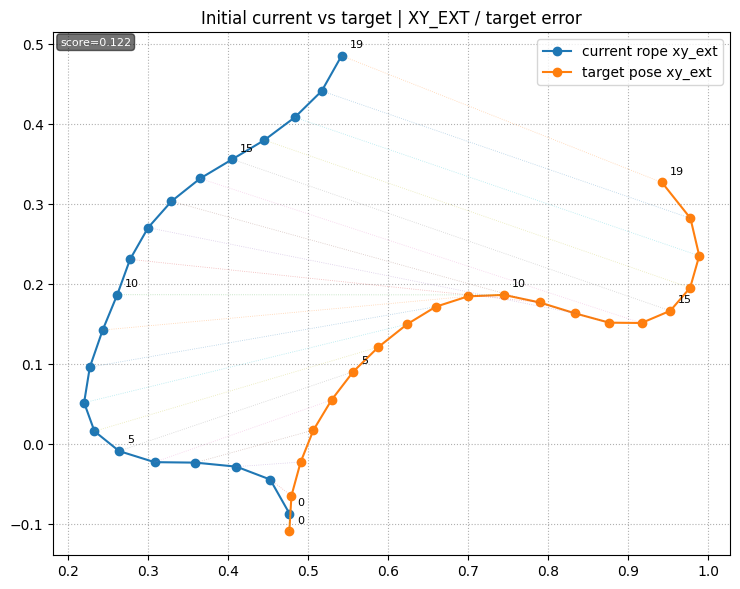

RUNTIME_NODE_SCHEDULE_ENABLED: True
RUNTIME_NODE_SCHEDULE        : ((1, 2, [7, 8, 9, 10, 11, 12, 13], 'center_warmup'), (3, 4, [15, 16, 17, 18, 19], 'endpoint_align'))
ROPE_RESET_ON_WORKSPACE_OUTSIDE: False
ROPE_MAX_OUTSIDE_RATIO       : 0.15
INITIAL_TARGET_BASED_TILT_ENABLED: True
INITIAL_TILT_NODE_IDX             : 19
INITIAL_TILT_DELTA_X              : 0.045

[eval_status_initial]
{
  "status": "running",
  "time_elapsed": 7.6,
  "time_remaining": 172.4,
  "current_score": 0.1
}

[STEP global=1/100 | schedule_step=1]

[eval_status_step_1_start]
{
  "status": "running",
  "time_elapsed": 9.9,
  "time_remaining": 170.1,
  "current_score": 0.1
}
[homography fallback #10] (u=616.00, v=201.00) -> (x=0.4699, y=-0.1092)
[INITIAL TILT] apply: {'applied': True, 'reason': 'target_based_initial_tilt', 'label': 'before_step_global_1', 'target_class': 'target_down', 'desired_label': 'left_up_for_lower_target', 'node_idx': 19, 'dx': -0.045, 'grasp_xy': [0.5352156162261963, 0.48061490058898926], '

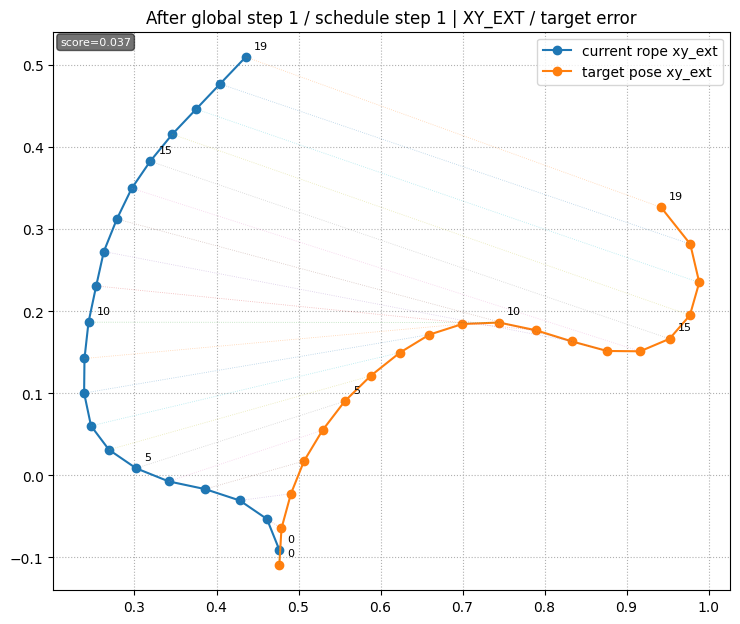


[STEP global=2/100 | schedule_step=2]

[eval_status_step_2_start]
{
  "status": "running",
  "time_elapsed": 47.3,
  "time_remaining": 132.7,
  "current_score": 0.0
}
before_mean_err_mm = 411.551
before_rmse_mm     = 462.604
[NODE SCHEDULE] global_step=2 schedule_step=2 label=center_warmup allowed_nodes=[7, 8, 9, 10, 11, 12, 13]
[WORKSPACE SAFETY] reachable grasp nodes: {'base_nodes': [7, 8, 9, 10, 11, 12, 13], 'reachable_nodes': [7, 8, 9, 10, 11, 12, 13], 'schedule_restricted': True, 'fallback_to_all_reachable_used': False}
[RL] offline actor decoded: {'node_idx': 13, 'len_idx': 6, 'theta_idx': 18, 'length': 0.4000000059604645, 'theta_deg': -18.000000500895634, 'allowed_nodes': [7, 8, 9, 10, 11, 12, 13]}
[RL] selected action: {'node_idx': 13, 'grasp_xy': array([0.3011872 , 0.35872668], dtype=float32), 'target_xy': array([0.6816098 , 0.23511988], dtype=float32), 'requested_node_idx': 13, 'workspace_safety': {'requested_node_idx': 13, 'final_node_idx': 13, 'node_changed': False, 'grasp

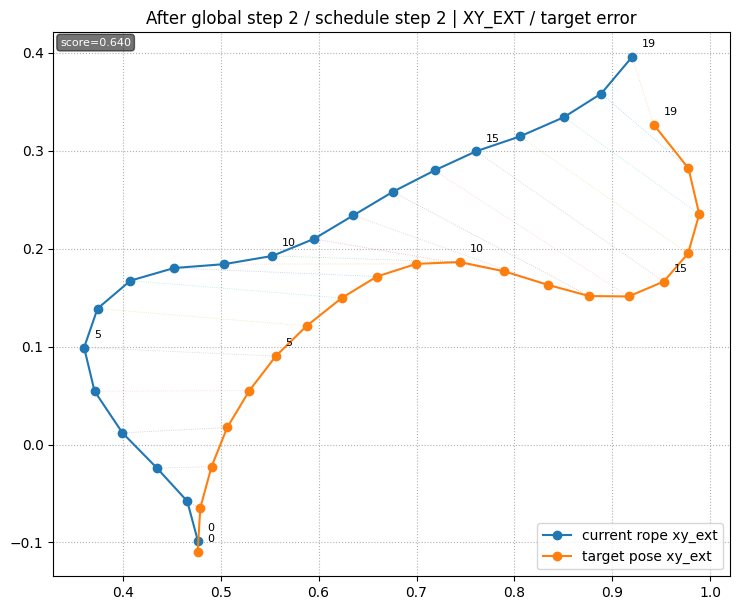


[STEP global=3/100 | schedule_step=3]

[eval_status_step_3_start]
{
  "status": "running",
  "time_elapsed": 75.3,
  "time_remaining": 104.7,
  "current_score": 0.6
}
before_mean_err_mm = 160.107
before_rmse_mm     = 172.694
[NODE SCHEDULE] global_step=3 schedule_step=3 label=endpoint_align allowed_nodes=[15, 16, 17, 18, 19]
[WORKSPACE SAFETY] reachable grasp nodes: {'base_nodes': [15, 16, 17, 18, 19], 'reachable_nodes': [15, 16, 17, 18, 19], 'schedule_restricted': True, 'fallback_to_all_reachable_used': False}
[RL] offline actor decoded: {'node_idx': 18, 'len_idx': 0, 'theta_idx': 16, 'length': 0.10000000149011612, 'theta_deg': -36.00000100179127, 'allowed_nodes': [15, 16, 17, 18, 19]}
[RL] selected action: {'node_idx': 18, 'grasp_xy': array([0.8930573, 0.3626487], dtype=float32), 'target_xy': array([0.97395897, 0.30387017], dtype=float32), 'requested_node_idx': 18, 'workspace_safety': {'requested_node_idx': 18, 'final_node_idx': 18, 'node_changed': False, 'grasp_projected': False, '

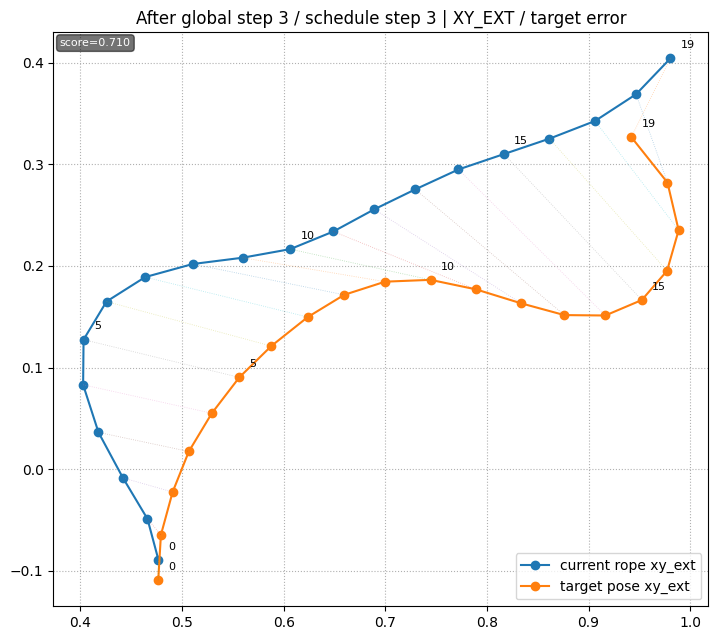


[STEP global=4/100 | schedule_step=4]

[eval_status_step_4_start]
{
  "status": "running",
  "time_elapsed": 99.2,
  "time_remaining": 80.8,
  "current_score": 0.7
}
before_mean_err_mm = 132.286
before_rmse_mm     = 142.678
[NODE SCHEDULE] global_step=4 schedule_step=4 label=endpoint_align allowed_nodes=[15, 16, 17, 18, 19]
[WORKSPACE SAFETY] reachable grasp nodes: {'base_nodes': [15, 16, 17, 18, 19], 'reachable_nodes': [15, 16, 17, 18], 'schedule_restricted': True, 'fallback_to_all_reachable_used': False}
[RL] offline actor decoded: {'node_idx': 17, 'len_idx': 0, 'theta_idx': 13, 'length': 0.10000000149011612, 'theta_deg': -62.99999833804013, 'allowed_nodes': [15, 16, 17, 18]}
[RL] selected action: {'node_idx': 17, 'grasp_xy': array([0.90635836, 0.34255555], dtype=float32), 'target_xy': array([0.95175743, 0.2534549 ], dtype=float32), 'requested_node_idx': 17, 'workspace_safety': {'requested_node_idx': 17, 'final_node_idx': 17, 'node_changed': False, 'grasp_projected': False, 'target_

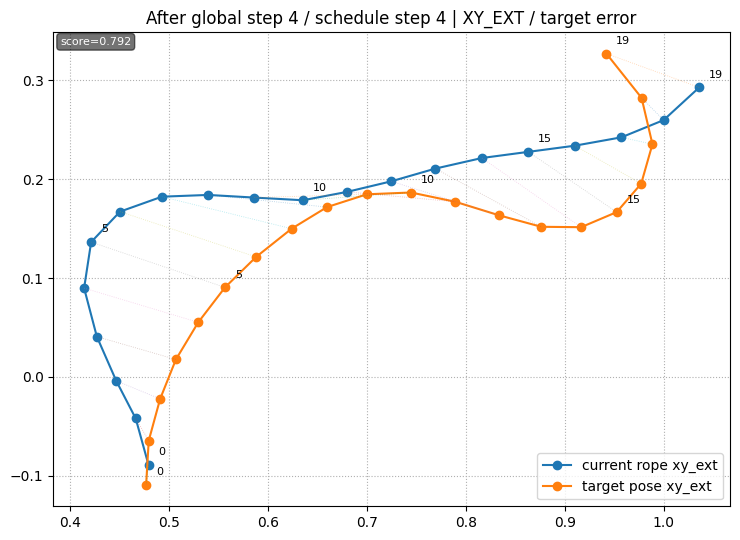


[SCORE HOLD MODE] reason=score_threshold_post_step
No additional rope manipulation, observation retry, or env_reset will be executed while hold is active.
If score falls below the dynamic threshold, hold will be released and the next step can run.
[SCORE HOLD] score=0.8 >= threshold=0.8 | label=eval_status_post_step_global_4 | elapsed=122.0 | remaining=58.0

[eval_status_score_hold]
{
  "status": "running",
  "time_elapsed": 122.8,
  "time_remaining": 57.2,
  "current_score": 0.8
}

[eval_status_score_hold]
{
  "status": "running",
  "time_elapsed": 126.5,
  "time_remaining": 53.5,
  "current_score": 0.8
}

[eval_status_score_hold]
{
  "status": "running",
  "time_elapsed": 130.0,
  "time_remaining": 50.0,
  "current_score": 0.8
}

[eval_status_score_hold]
{
  "status": "running",
  "time_elapsed": 133.5,
  "time_remaining": 46.5,
  "current_score": 0.8
}

[eval_status_score_hold]
{
  "status": "running",
  "time_elapsed": 137.0,
  "time_remaining": 43.0,
  "current_score": 0.8
}

[ev

In [4]:

# =========================================================
# Task2 Offline-RL closed loop run
# =========================================================
# Cell 2 must be run first. It starts eval/competition and initializes SELECTED_CANDIDATE.

if SELECTED_CANDIDATE is None:
    raise RuntimeError(
        "SELECTED_CANDIDATE is not initialized. "
        "Run Cell 2 first so fixed mode calls eval_start(), or competition mode calls competition_start('task2')."
    )

print("\n[RUNTIME CONTEXT]")
print("COMPETITION_MODE       :", COMPETITION_MODE)
print("ASSIGNED_ROBOT_NAME    :", ASSIGNED_ROBOT_NAME)
print("ROBOT_NAME             :", ROBOT_NAME)
print("ROBOT_ID               :", ROBOT_ID)
print("LUT_PATH               :", LUT_PATH)
print("ROBOT_MAP_DIR          :", ROBOT_MAP_DIR)
print("CALIBRATION_YAML_PATH  :", CALIBRATION_YAML_PATH)
print("PARAM_FILE             :", PARAM_FILE)
print("SIDECAR_PATH           :", SELECTED_CANDIDATE.get("sidecar_path"))
print("workspace yaml section :", workspace_cfg["section_name"])
print("X_MIN, X_MAX           :", workspace_cfg["x_min"], workspace_cfg["x_max"])
print("Y_MIN, Y_MAX           :", workspace_cfg["y_min"], workspace_cfg["y_max"])
print("ACTION_X_MIN, ACTION_X_MAX :", workspace_cfg["action_x_min"], workspace_cfg["action_x_max"])
print("ACTION_Y_MIN, ACTION_Y_MAX :", workspace_cfg["action_y_min"], workspace_cfg["action_y_max"])
print("homography_ready       :", SELECTED_CANDIDATE.get("homography_ready"))
print("homography_info        :", SELECTED_CANDIDATE.get("homography_info"))

# =========================================================
# Load Offline RL / QSafe model
# =========================================================
rl_policy, rl_ckpt = load_offline_rl_policy(RL_MODEL_PATH, RL_DEVICE)
print("offline RL/QSafe policy ready")


# target는 시작 시 한 번 읽고 고정
target_obs = retry_obs(lambda: get_target_observation(robot, SELECTED_CANDIDATE))
print("target coord_space:", target_obs["coord_space"])
print("target xy_ext_vs_lut:", target_obs["xy_ext_vs_lut_metrics"])

current_obs, target_obs, obs_recovery = get_current_obs_with_auto_reset(
    robot,
    SELECTED_CANDIDATE,
    target_obs=target_obs,
    refresh_target_fn=lambda: get_target_observation(robot, SELECTED_CANDIDATE),
    label="initial_current",
)
print("current coord_space:", current_obs["coord_space"])
print("current xy_ext_vs_lut:", current_obs["xy_ext_vs_lut_metrics"])
print("current runtime_health:", current_obs.get("runtime_health"))
if obs_recovery.get("auto_reset"):
    print("[AUTO RESET INFO] initial observation recovered by env_reset")

plot_uv_and_xy(current_obs, target_obs, title="Initial current vs target")

history = []
success = False

# =========================================================
# Runtime node schedule for real robot stabilization
# =========================================================
# 실제 로봇에서는 초기 endpoint pull이 rope를 화면 밖으로 밀거나 전체 pose를 크게 틀 수 있으므로,
# 초반에는 node 선택 영역만 제한한다. length/theta는 같은 actor가 forced node 기준으로 다시 decode한다.
RUNTIME_NODE_SCHEDULE_ENABLED = True
RUNTIME_NODE_SCHEDULE = (
    (1, 2, list(range(7, 14)), "center_warmup"),   # step 1~2: node 7~13
    (3, 4, list(range(15, 20)), "endpoint_align"), # step 3~4: node 15~19
)

def get_allowed_nodes_for_runtime_step(step_idx: int):
    if not RUNTIME_NODE_SCHEDULE_ENABLED:
        return None, "free"
    for start, end, nodes, label in RUNTIME_NODE_SCHEDULE:
        if int(start) <= int(step_idx) <= int(end):
            return list(nodes), str(label)
    return None, "free"

print("RUNTIME_NODE_SCHEDULE_ENABLED:", RUNTIME_NODE_SCHEDULE_ENABLED)
print("RUNTIME_NODE_SCHEDULE        :", RUNTIME_NODE_SCHEDULE)
print("ROPE_RESET_ON_WORKSPACE_OUTSIDE:", ROPE_RESET_ON_WORKSPACE_OUTSIDE)

print("ROPE_MAX_OUTSIDE_RATIO       :", ROPE_MAX_OUTSIDE_RATIO)

# =========================================================
# Target-dependent initial rope tilt preconditioning
# =========================================================
# Motivation:
# - After env_reset, the rope can have a biased initial slope.
# - Empirically, upper targets and lower targets can benefit from opposite
#   left-side pre-tilt directions.
# - This preconditioning is deliberately small and is applied only after reset,
#   before normal RL-controlled steps.
INITIAL_TARGET_BASED_TILT_ENABLED = True
INITIAL_TILT_REAPPLY_AFTER_ENV_RESET = True

# Node indices increase from right to left in this Task 2 setup.
# Use an inner-left node rather than the endpoint to avoid excessive endpoint pull.
INITIAL_TILT_NODE_IDX = 19
INITIAL_TILT_LEFT_SIDE_NODES = [15, 16, 17, 18, 19]
INITIAL_TILT_RIGHT_SIDE_NODES = [0, 1, 2, 3, 4]

# In the robot8/Task2 mapping, camera vertical displacement is represented
# primarily by the normalized x coordinate. Larger x roughly corresponds to
# visually lower/downward motion in the camera view.
INITIAL_TILT_VERTICAL_AXIS = "x"
INITIAL_TILT_X_SIGN_FOR_CAMERA_DOWN = 1.0

# Decide whether target is "upper" or "lower" by comparing target/current
# mean x coordinates. x larger -> visually lower.
INITIAL_TILT_TARGET_VERTICAL_MARGIN_X = 0.035

# Desired tilt margin: left side x - right side x.
# positive -> left side is lower/down; negative -> left side is upper/up.
INITIAL_TILT_EXISTING_TILT_MARGIN_X = 0.020

# Small pre-tilt displacement applied to the selected left-side node.
INITIAL_TILT_DELTA_X = 0.045
INITIAL_TILT_WAIT_AFTER = 0.35
INITIAL_TILT_VERBOSE = True

print("INITIAL_TARGET_BASED_TILT_ENABLED:", INITIAL_TARGET_BASED_TILT_ENABLED)
print("INITIAL_TILT_NODE_IDX             :", INITIAL_TILT_NODE_IDX)
print("INITIAL_TILT_DELTA_X              :", INITIAL_TILT_DELTA_X)


def _safe_mean_axis_from_obs(obs: dict, axis: int, node_indices=None):
    pts = np.asarray(obs.get("xy_ext_full"), dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] < 2:
        return None
    if node_indices is not None:
        idx = [int(i) for i in node_indices if 0 <= int(i) < len(pts)]
        if not idx:
            return None
        vals = pts[idx, axis]
    else:
        vals = pts[:, axis]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None
    return float(np.mean(vals))


def _choose_initial_tilt_node(current_obs: dict, preferred_idx: int, candidate: dict):
    pts = np.asarray(current_obs.get("xy_ext_full"), dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] < 2:
        return None
    ws = candidate["workspace_cfg"]
    preferred = int(preferred_idx)
    candidate_indices = [preferred, 15, 16, 17, 18, 14, 13, 12]
    seen = set()
    for idx in candidate_indices:
        idx = int(idx)
        if idx in seen or idx < 0 or idx >= len(pts):
            continue
        seen.add(idx)
        xy = pts[idx]
        if not np.all(np.isfinite(xy)):
            continue
        x, y = float(xy[0]), float(xy[1])
        if (ws["action_x_min"] <= x <= ws["action_x_max"] and
            ws["action_y_min"] <= y <= ws["action_y_max"]):
            return idx
    return None


def infer_target_vertical_class_for_initial_tilt(current_obs: dict, target_obs: dict):
    """Return target_up / target_down / neutral from current-vs-target vertical offset.

    Here the normalized x axis is used as the camera-vertical proxy:
    smaller x -> visually upper, larger x -> visually lower.
    """
    cur_mean_x = _safe_mean_axis_from_obs(current_obs, axis=0)
    tgt_mean_x = _safe_mean_axis_from_obs(target_obs, axis=0)
    if cur_mean_x is None or tgt_mean_x is None:
        return "unknown", {"current_mean_x": cur_mean_x, "target_mean_x": tgt_mean_x}

    offset_x = float(tgt_mean_x - cur_mean_x)
    info = {
        "current_mean_x": float(cur_mean_x),
        "target_mean_x": float(tgt_mean_x),
        "target_minus_current_x": float(offset_x),
        "margin_x": float(INITIAL_TILT_TARGET_VERTICAL_MARGIN_X),
    }

    if offset_x > float(INITIAL_TILT_TARGET_VERTICAL_MARGIN_X):
        return "target_down", info
    if offset_x < -float(INITIAL_TILT_TARGET_VERTICAL_MARGIN_X):
        return "target_up", info
    return "neutral", info


def compute_current_left_tilt_metric_x(current_obs: dict):
    """Positive means left side is visually lower/down than right side."""
    left_x = _safe_mean_axis_from_obs(current_obs, axis=0, node_indices=INITIAL_TILT_LEFT_SIDE_NODES)
    right_x = _safe_mean_axis_from_obs(current_obs, axis=0, node_indices=INITIAL_TILT_RIGHT_SIDE_NODES)
    if left_x is None or right_x is None:
        return None, {"left_mean_x": left_x, "right_mean_x": right_x}
    metric = float(left_x - right_x)
    return metric, {"left_mean_x": float(left_x), "right_mean_x": float(right_x), "left_minus_right_x": metric}


def apply_target_based_initial_tilt_if_needed(
    robot,
    current_obs: dict,
    target_obs: dict,
    candidate: dict,
    label: str = "initial_tilt",
):
    """Apply a small reset-time pre-tilt based on target vertical placement.

    Policy:
    - If target is visually upper: prefer left side lower/down.
    - If target is visually lower: prefer left side upper/up.
    - If the current reset pose already has the desired tilt sign/margin, skip.
    """
    if not INITIAL_TARGET_BASED_TILT_ENABLED:
        return {"applied": False, "reason": "disabled"}

    target_class, target_info = infer_target_vertical_class_for_initial_tilt(current_obs, target_obs)
    tilt_metric, tilt_info = compute_current_left_tilt_metric_x(current_obs)

    if target_class == "neutral":
        out = {"applied": False, "reason": "target_vertical_neutral", "target_class": target_class, **target_info, **tilt_info}
        if INITIAL_TILT_VERBOSE:
            print("[INITIAL TILT] skip:", out)
        return out
    if target_class == "unknown" or tilt_metric is None:
        out = {"applied": False, "reason": "insufficient_geometry", "target_class": target_class, **target_info, **tilt_info}
        if INITIAL_TILT_VERBOSE:
            print("[INITIAL TILT] skip:", out)
        return out

    # Desired left-side tilt:
    # - target_up   -> left_down -> positive left-minus-right x
    # - target_down -> left_up   -> negative left-minus-right x
    if target_class == "target_up":
        desired_tilt_sign = +1.0
        desired_label = "left_down_for_upper_target"
    else:
        desired_tilt_sign = -1.0
        desired_label = "left_up_for_lower_target"

    # If the reset pose already has the desired tilt with enough margin, do not touch it.
    if desired_tilt_sign > 0 and tilt_metric >= float(INITIAL_TILT_EXISTING_TILT_MARGIN_X):
        out = {"applied": False, "reason": "desired_left_down_already_present", "target_class": target_class,
               "desired_label": desired_label, **target_info, **tilt_info}
        if INITIAL_TILT_VERBOSE:
            print("[INITIAL TILT] skip:", out)
        return out
    if desired_tilt_sign < 0 and tilt_metric <= -float(INITIAL_TILT_EXISTING_TILT_MARGIN_X):
        out = {"applied": False, "reason": "desired_left_up_already_present", "target_class": target_class,
               "desired_label": desired_label, **target_info, **tilt_info}
        if INITIAL_TILT_VERBOSE:
            print("[INITIAL TILT] skip:", out)
        return out

    node_idx = _choose_initial_tilt_node(current_obs, INITIAL_TILT_NODE_IDX, candidate)
    if node_idx is None:
        out = {"applied": False, "reason": "no_reachable_initial_tilt_node", "target_class": target_class,
               "desired_label": desired_label, **target_info, **tilt_info}
        if INITIAL_TILT_VERBOSE:
            print("[INITIAL TILT] skip:", out)
        return out

    pts = np.asarray(current_obs["xy_ext_full"], dtype=np.float32)
    grasp_xy = np.asarray(pts[node_idx], dtype=np.float32).copy()
    target_xy = grasp_xy.copy()

    # Camera down is +x by default. For left_down use +dx; for left_up use -dx.
    dx = float(desired_tilt_sign) * float(INITIAL_TILT_X_SIGN_FOR_CAMERA_DOWN) * float(INITIAL_TILT_DELTA_X)
    ws = candidate["workspace_cfg"]
    target_xy[0] = float(np.clip(float(target_xy[0]) + dx, ws["action_x_min"], ws["action_x_max"]))
    target_xy[1] = float(np.clip(float(target_xy[1]), ws["action_y_min"], ws["action_y_max"]))

    if abs(float(target_xy[0]) - float(grasp_xy[0])) < 1e-5:
        out = {"applied": False, "reason": "tilt_target_clipped_no_motion", "target_class": target_class,
               "desired_label": desired_label, "node_idx": int(node_idx), **target_info, **tilt_info}
        if INITIAL_TILT_VERBOSE:
            print("[INITIAL TILT] skip:", out)
        return out

    try:
        pre_tilt_theta_deg = compute_grasp_theta_deg_from_uv_window(
            uv_full=current_obs["uv_full"],
            node_idx=int(node_idx),
            window=GRASP_ANGLE_WINDOW,
        )
        pre_tilt_theta_cmd_deg = quantize_rotate_deg(pre_tilt_theta_deg)
    except Exception:
        pre_tilt_theta_deg = None
        pre_tilt_theta_cmd_deg = None

    out = {
        "applied": True,
        "reason": "target_based_initial_tilt",
        "label": str(label),
        "target_class": target_class,
        "desired_label": desired_label,
        "node_idx": int(node_idx),
        "dx": float(dx),
        "grasp_xy": grasp_xy.tolist(),
        "target_xy": target_xy.tolist(),
        "pre_tilt_theta_deg": None if pre_tilt_theta_deg is None else float(pre_tilt_theta_deg),
        "pre_tilt_theta_cmd_deg": pre_tilt_theta_cmd_deg,
        **target_info,
        **tilt_info,
    }
    print("[INITIAL TILT] apply:", out)

    execute_rope_drag(
        robot=robot,
        grasp_xy=grasp_xy,
        target_xy=target_xy,
        candidate=candidate,
        rotate_before_pick_deg=pre_tilt_theta_cmd_deg,
        rotate_after_grasp_deg=None,
        rotate_before_release_deg=None,
    )
    sleep_cmd(INITIAL_TILT_WAIT_AFTER)
    return out

# =========================================================
# Score hold configuration
# =========================================================
# New rule assumption: final score is determined at the last evaluation moment.
# Once a sufficiently high score is reached, stop further manipulation and hold still
# until evaluation completes.
SCORE_HOLD_ENABLED = True
SCORE_HOLD_POLL_SEC = 0.35
SCORE_HOLD_VERBOSE_EVERY_SEC = 2.0
SCORE_HOLD_DEFAULT_THRESHOLD = 0.90     # time_remaining >= 120 sec
SCORE_HOLD_THRESHOLD_UNDER_60 = 0.80   # time_remaining < 120 sec
SCORE_HOLD_THRESHOLD_UNDER_30 = 0.70    # time_remaining < 60 sec
SCORE_HOLD_NO_ROBOT_MOTION = True       # do not touch/reset rope after hold trigger
# If score falls below the current dynamic threshold during hold, resume normal steps.
# A small debounce prevents one transient eval_status sample from immediately resuming.
SCORE_HOLD_RESUME_IF_BELOW_THRESHOLD = True
SCORE_HOLD_RELEASE_MARGIN = 0.0
SCORE_HOLD_RELEASE_CONSECUTIVE_BELOW = 2

#print("SCORE_HOLD_ENABLED           :", SCORE_HOLD_ENABLED)
#print("SCORE_HOLD thresholds        :", {"default": SCORE_HOLD_DEFAULT_THRESHOLD, "under_60": SCORE_HOLD_THRESHOLD_UNDER_60, "under_30": SCORE_HOLD_THRESHOLD_UNDER_30})
#print("SCORE_HOLD resumable         :", {"enabled": SCORE_HOLD_RESUME_IF_BELOW_THRESHOLD, "margin": SCORE_HOLD_RELEASE_MARGIN, "consecutive_below": SCORE_HOLD_RELEASE_CONSECUTIVE_BELOW})

# =========================================================
# Evaluation status logging + live stream overlay + 181 sec auto stop
# =========================================================

STREAM_WINDOW_NAME = "task2 camera stream"
STREAM_STATUS_POLL_SEC = 1.0
STREAM_OBJECT_POLL_SEC = 0.50
STREAM_TARGET_RETRY_SEC = 2.0
STREAM_FRAME_SLEEP_SEC = 0.03
# Overlay is intentionally compact and pinned to the far-left side.
# The rope manipulation area is usually on the right side of the stream.
STREAM_DRAW_ROPE_TARGET_OVERLAY = True
STREAM_OVERLAY_FONT_SCALE = 0.50
STREAM_OVERLAY_THICKNESS = 1
STREAM_OVERLAY_X = 6
STREAM_OVERLAY_Y = 18
STREAM_OVERLAY_LINE_H = 18
STREAM_OVERLAY_MAX_WIDTH = 330
STREAM_OVERLAY_SHOW_HINT = False

# OpenCV uses BGR colors.
STREAM_COLOR_CURRENT_ROPE = (0, 255, 0)
STREAM_COLOR_TARGET_POSE = (0, 255, 255)
STREAM_COLOR_TEXT = (255, 255, 255)
STREAM_COLOR_WARN = (0, 128, 255)
STREAM_COLOR_PANEL = (0, 0, 0)

import threading

_eval_status_lock = threading.Lock()
_latest_eval_status = {}
_stream_stop_event = threading.Event()
_eval_status_history = []

_stream_geometry_lock = threading.Lock()
_latest_stream_current_uv = (
    np.asarray(current_obs.get("uv_full"), dtype=np.float32).copy()
    if isinstance(current_obs, dict) and current_obs.get("uv_full") is not None
    else None
)
_latest_stream_target_uv = (
    np.asarray(target_obs.get("uv_full"), dtype=np.float32).copy()
    if isinstance(target_obs, dict) and target_obs.get("uv_full") is not None
    else None
)



# =========================================================
# Final-score rule adaptation: score-based hold mode
# =========================================================
# New rule assumption: final score is determined at the last evaluation moment.
# Once a sufficiently high score is reached, stop further manipulation and hold still
# until evaluation completes. This avoids destroying a good shape with late risky actions.
SCORE_HOLD_NO_ROBOT_MOTION = True       # safest: do not touch or reset rope after hold trigger

_score_hold_event = threading.Event()
_score_hold_info = {}


def get_eval_score_value(st: dict):
    """Extract current/final score as float if available."""
    if not isinstance(st, dict):
        return None
    raw = st.get("current_score", st.get("final_score", None))
    try:
        return float(raw)
    except Exception:
        return None


def get_eval_time_remaining_value(st: dict):
    """Extract time_remaining as float if available."""
    if not isinstance(st, dict):
        return None
    raw = st.get("time_remaining", None)
    try:
        return float(raw)
    except Exception:
        return None


def score_hold_threshold_from_status(st: dict) -> float:
    """Dynamic score threshold based on remaining time."""
    remain = get_eval_time_remaining_value(st)
    if remain is None:
        return float(SCORE_HOLD_DEFAULT_THRESHOLD)
    if remain < 30.0:
        return float(SCORE_HOLD_THRESHOLD_UNDER_30)
    if remain < 60.0:
        return float(SCORE_HOLD_THRESHOLD_UNDER_60)
    return float(SCORE_HOLD_DEFAULT_THRESHOLD)


def update_score_hold_watch(st: dict, label: str = "") -> bool:
    """Set hold event when score reaches the dynamic threshold."""
    if not SCORE_HOLD_ENABLED:
        return False
    if not isinstance(st, dict):
        return False
    if st.get("status") == "completed":
        return False

    score = get_eval_score_value(st)
    if score is None:
        return False
    threshold = score_hold_threshold_from_status(st)

    if score >= threshold:
        info = {
            "label": str(label),
            "score": float(score),
            "threshold": float(threshold),
            "time_elapsed": st.get("time_elapsed"),
            "time_remaining": st.get("time_remaining"),
            "status": st.get("status"),
            "trigger_wall_time": time.time(),
        }
        _score_hold_info.clear()
        _score_hold_info.update(info)
        _score_hold_event.set()
        return True
    return False


def score_hold_triggered() -> bool:
    return SCORE_HOLD_ENABLED and _score_hold_event.is_set()


def print_score_hold_trigger(prefix: str = "[SCORE HOLD]"):
    if not _score_hold_info:
        print(f"{prefix} triggered, but no detail info is available")
        return
    print(
        f"{prefix} score={_score_hold_info.get('score')} >= threshold={_score_hold_info.get('threshold')} "
        f"| label={_score_hold_info.get('label')} "
        f"| elapsed={_score_hold_info.get('time_elapsed')} "
        f"| remaining={_score_hold_info.get('time_remaining')}"
    )


def score_below_current_hold_threshold(st: dict):
    """Return (below, score, threshold) for resumable hold mode."""
    if not isinstance(st, dict) or st.get("status") != "running":
        return False, None, None
    try:
        score = float(st.get("current_score", st.get("final_score")))
    except Exception:
        return False, None, None
    threshold = score_hold_threshold_from_status(st)
    below = score < (float(threshold) - float(SCORE_HOLD_RELEASE_MARGIN))
    return bool(below), float(score), float(threshold)


def clear_score_hold(reason: str = "score_below_threshold"):
    """Clear score hold event so the main loop can resume manipulation."""
    _score_hold_event.clear()
    _score_hold_info["released"] = True
    _score_hold_info["release_reason"] = str(reason)


def is_score_hold_release_reason(reason: str) -> bool:
    return isinstance(reason, str) and reason.startswith("score_hold_released")


def hold_until_eval_complete(robot, reason: str = "score_hold"):
    """Pause manipulation while score is above threshold.

    If the score later falls below the dynamic threshold for a few consecutive
    eval_status samples, clear hold mode and let the main loop resume. This is
    important because the competition uses the final score, and an early high
    score can be transient while the rope is still settling.
    """
    print("\n" + "=" * 90)
    print(f"[SCORE HOLD MODE] reason={reason}")
    print("No additional rope manipulation, observation retry, or env_reset will be executed while hold is active.")
    print("If score falls below the dynamic threshold, hold will be released and the next step can run.")
    print_score_hold_trigger()
    print("=" * 90)

    last_verbose_ts = 0.0
    below_count = 0
    while True:
        local_elapsed = time.monotonic() - _eval_run_start_ts
        verbose_now = (time.monotonic() - last_verbose_ts) >= SCORE_HOLD_VERBOSE_EVERY_SEC
        st = safe_eval_status(robot, label="eval_status_score_hold", update_shared=True, verbose=verbose_now)
        if verbose_now:
            last_verbose_ts = time.monotonic()

        if isinstance(st, dict) and st.get("status") == "completed":
            return "score_hold_until_completed"
        if eval_time_limit_reached(st, local_elapsed, EVAL_TIME_LIMIT_SEC):
            return f"score_hold_until_time_limit: elapsed={local_elapsed:.1f}s"

        if SCORE_HOLD_RESUME_IF_BELOW_THRESHOLD:
            below, score, threshold = score_below_current_hold_threshold(st)
            if below:
                below_count += 1
                if verbose_now:
                    print(
                        f"[SCORE HOLD CHECK] below threshold {below_count}/{SCORE_HOLD_RELEASE_CONSECUTIVE_BELOW} "
                        f"| score={score:.3f} < threshold={threshold:.3f}"
                    )
                if below_count >= int(SCORE_HOLD_RELEASE_CONSECUTIVE_BELOW):
                    clear_score_hold(
                        reason=f"score_below_threshold: score={score:.3f} < threshold={threshold:.3f}"
                    )
                    return f"score_hold_released_below_threshold: score={score:.3f} < threshold={threshold:.3f}"
            else:
                below_count = 0

        time.sleep(SCORE_HOLD_POLL_SEC)


def safe_eval_status(robot, label: str = "eval_status", update_shared: bool = True, verbose: bool = True):
    """Call robot.eval_status() safely and optionally store/print it."""
    try:
        st = robot.eval_status()
    except Exception as e:
        st = {"status": "eval_status_failed", "error": repr(e)}

    if update_shared:
        with _eval_status_lock:
            _latest_eval_status.clear()
            if isinstance(st, dict):
                _latest_eval_status.update(st)
            else:
                _latest_eval_status.update({"status": "unknown", "raw": repr(st)})

    _eval_status_history.append({"label": str(label), "t_wall": time.time(), "status": st})

    # Score-hold watcher: stop future actions once dynamic score threshold is reached.
    try:
        update_score_hold_watch(st, label=label)
    except Exception as _score_hold_e:
        # Never let score watching break the control loop.
        pass

    if verbose:
        print(f"\n[{label}]")
        try:
            print(json.dumps(st, indent=2, ensure_ascii=False))
        except Exception:
            print(st)
    return st


def eval_status_score_text(st: dict) -> str:
    if not isinstance(st, dict):
        return "eval_status: unavailable"
    status = st.get("status", "?")
    if status == "completed":
        score = st.get("final_score", st.get("current_score", "?"))
        return f"status={status} | final_score={score}"
    score = st.get("current_score", st.get("final_score", "?"))
    elapsed = st.get("time_elapsed", None)
    remain = st.get("time_remaining", None)
    if elapsed is not None and remain is not None:
        return f"status={status} | score={score} | t={float(elapsed):.1f}s | remain={float(remain):.1f}s"
    return f"status={status} | score={score}"


def eval_time_limit_reached(st: Optional[dict], local_elapsed: float, limit_sec: float = EVAL_TIME_LIMIT_SEC) -> bool:
    if isinstance(st, dict):
        if st.get("status") == "completed":
            return True
        try:
            if float(st.get("time_elapsed", -1.0)) >= float(limit_sec):
                return True
        except Exception:
            pass
    return float(local_elapsed) >= float(limit_sec)



def _stream_uv_points_array(points):
    """Return an Nx2 float32 array for stream drawing, or None if invalid."""
    if points is None:
        return None

    try:
        pts = np.asarray(points, dtype=np.float32)
    except Exception:
        return None

    if pts.ndim != 2 or pts.shape[1] != 2 or len(pts) == 0:
        return None

    finite = np.isfinite(pts).all(axis=1)
    pts = pts[finite]

    if len(pts) == 0:
        return None

    return pts


def _stream_extract_eval_uv(payload):
    """Extract Task2 eval geometry points in undistorted image pixel coordinates."""
    try:
        uv, _coord_space = extract_geometry_points(payload, reverse_order=REVERSE_NODE_ORDER)
        return _stream_uv_points_array(uv)
    except Exception:
        return None


def _stream_update_current_uv_from_eval(robot):
    """Poll eval_object() and cache current rope UV points for the live overlay."""
    global _latest_stream_current_uv

    try:
        payload = robot.eval_object()
        pts = _stream_extract_eval_uv(payload)
    except Exception:
        pts = None

    if pts is not None:
        with _stream_geometry_lock:
            _latest_stream_current_uv = pts.copy()


def _stream_update_target_uv_from_eval(robot):
    """Poll eval_target() and cache target rope UV points for the live overlay."""
    global _latest_stream_target_uv

    try:
        payload = robot.eval_target()
        pts = _stream_extract_eval_uv(payload)
    except Exception:
        pts = None

    if pts is not None:
        with _stream_geometry_lock:
            _latest_stream_target_uv = pts.copy()


def update_stream_overlay_geometry(current_obs=None, target_obs=None):
    """Update live overlay geometry from already computed notebook observations."""
    global _latest_stream_current_uv, _latest_stream_target_uv

    with _stream_geometry_lock:
        if isinstance(current_obs, dict) and current_obs.get("uv_full") is not None:
            pts = _stream_uv_points_array(current_obs.get("uv_full"))
            if pts is not None:
                _latest_stream_current_uv = pts.copy()

        if isinstance(target_obs, dict) and target_obs.get("uv_full") is not None:
            pts = _stream_uv_points_array(target_obs.get("uv_full"))
            if pts is not None:
                _latest_stream_target_uv = pts.copy()


def _draw_stream_rope_polyline(frame, points, color, label):
    """Draw an open Task2 rope polyline on the camera frame."""
    pts = _stream_uv_points_array(points)

    if pts is None:
        return

    h, w = frame.shape[:2]
    pts = pts.copy()
    pts[:, 0] = np.clip(pts[:, 0], -10000, w + 10000)
    pts[:, 1] = np.clip(pts[:, 1], -10000, h + 10000)
    pts_i = np.round(pts).astype(np.int32)

    if len(pts_i) >= 2:
        cv2.polylines(
            frame,
            [pts_i.reshape((-1, 1, 2))],
            isClosed=False,
            color=color,
            thickness=2,
            lineType=cv2.LINE_AA,
        )

    for idx, (u, v) in enumerate(pts_i):
        cv2.circle(frame, (int(u), int(v)), 3, color, -1, lineType=cv2.LINE_AA)

        # Keep labels sparse so the stream remains readable.
        if idx in {0, len(pts_i) - 1} or idx % 5 == 0:
            cv2.putText(
                frame,
                str(idx),
                (int(u) + 4, int(v) - 4),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.35,
                color,
                1,
                cv2.LINE_AA,
            )

    anchor = pts_i[0]
    cv2.putText(
        frame,
        str(label),
        (int(anchor[0]) + 6, int(anchor[1]) + 16),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        color,
        1,
        cv2.LINE_AA,
    )


def _stream_score_from_status_or_geometry(st, current_uv=None, target_uv=None):
    """Return official eval score if available; otherwise use pixel RMSE score proxy."""
    score = None

    if isinstance(st, dict):
        for key in ("final_score", "current_score", "score"):
            value = st.get(key, None)
            if value is not None:
                score = value
                break

    if score is None:
        try:
            _rmse_px, score_px = task2_rmse_and_score_px_from_uv(current_uv, target_uv)
            score = score_px
        except Exception:
            score = None

    return score


def draw_eval_overlay(image, st: dict, current_uv=None, target_uv=None):
    """Draw Task2 current rope, target pose, and a score-only left panel."""
    frame = image.copy()

    if STREAM_DRAW_ROPE_TARGET_OVERLAY:
        _draw_stream_rope_polyline(frame, current_uv, STREAM_COLOR_CURRENT_ROPE, "current")
        _draw_stream_rope_polyline(frame, target_uv, STREAM_COLOR_TARGET_POSE, "target")

    score = _stream_score_from_status_or_geometry(st, current_uv=current_uv, target_uv=target_uv)

    try:
        score_text = f"score {_fmt_num(score, 3)}"
    except Exception:
        score_text = f"score {score}"

    lines = [score_text]

    x0 = int(STREAM_OVERLAY_X)
    y0 = int(STREAM_OVERLAY_Y)
    line_h = int(STREAM_OVERLAY_LINE_H)

    panel_w = min(int(STREAM_OVERLAY_MAX_WIDTH), max(110, frame.shape[1] // 5))
    panel_h = 8 + line_h * len(lines)
    cv2.rectangle(
        frame,
        (max(0, x0 - 3), max(0, y0 - line_h + 3)),
        (min(frame.shape[1] - 1, x0 - 3 + panel_w), min(frame.shape[0] - 1, y0 - line_h + 3 + panel_h)),
        STREAM_COLOR_PANEL,
        -1,
    )

    for k, txt in enumerate(lines):
        cv2.putText(
            frame,
            txt,
            (x0, y0 + k * line_h),
            cv2.FONT_HERSHEY_SIMPLEX,
            STREAM_OVERLAY_FONT_SCALE,
            STREAM_COLOR_TEXT,
            STREAM_OVERLAY_THICKNESS,
            cv2.LINE_AA,
        )

    return frame


def start_camera_stream_with_eval_overlay(robot):
    """Start camera stream thread with current rope, target pose, and score-only overlay."""
    if not STREAM_WITH_EVAL_OVERLAY:
        return None

    def _loop():
        last_status_poll = 0.0
        last_object_poll = 0.0
        last_target_retry = 0.0

        while not _stream_stop_event.is_set():
            now = time.monotonic()

            if now - last_status_poll >= STREAM_STATUS_POLL_SEC:
                safe_eval_status(robot, label="eval_status_stream", update_shared=True, verbose=False)
                last_status_poll = now

            if now - last_object_poll >= STREAM_OBJECT_POLL_SEC:
                _stream_update_current_uv_from_eval(robot)
                last_object_poll = now

            with _stream_geometry_lock:
                target_missing = _latest_stream_target_uv is None

            if target_missing or (now - last_target_retry >= STREAM_TARGET_RETRY_SEC):
                _stream_update_target_uv_from_eval(robot)
                last_target_retry = now

            try:
                image, timestamp = robot.getImageBaseUndistorted()
                if image is None:
                    time.sleep(STREAM_FRAME_SLEEP_SEC)
                    continue

                with _eval_status_lock:
                    st = dict(_latest_eval_status)

                with _stream_geometry_lock:
                    current_uv = None if _latest_stream_current_uv is None else _latest_stream_current_uv.copy()
                    target_uv = None if _latest_stream_target_uv is None else _latest_stream_target_uv.copy()

                frame = draw_eval_overlay(image, st, current_uv=current_uv, target_uv=target_uv)
                cv2.imshow(STREAM_WINDOW_NAME, frame)

                if cv2.waitKey(1) & 0xFF == ord('q'):
                    _stream_stop_event.set()
                    break

            except Exception as e:
                # Keep main control loop alive even if stream fails transiently.
                print("[STREAM WARN]", repr(e))
                time.sleep(0.2)

            time.sleep(STREAM_FRAME_SLEEP_SEC)

        try:
            cv2.destroyWindow(STREAM_WINDOW_NAME)
        except Exception:
            pass

    th = threading.Thread(target=_loop, daemon=True)
    th.start()
    return th

# Initial status + stream start
_eval_run_start_ts = time.monotonic()
safe_eval_status(robot, label="eval_status_initial", update_shared=True, verbose=True)
_stream_thread = start_camera_stream_with_eval_overlay(robot)

# =========================================================
# Main runtime loop
# =========================================================
# global_step_idx: total number of attempted loop iterations.
# runtime_step_idx: schedule-local step. It resets to 1 after env_reset.
global_step_idx = 0
runtime_step_idx = 1
stop_reason = None

_initial_tilt_pending = bool(INITIAL_TARGET_BASED_TILT_ENABLED)

try:
    while global_step_idx < MAX_STEPS:
        local_elapsed = time.monotonic() - _eval_run_start_ts
        st_preloop = safe_eval_status(robot, label=f"eval_status_pre_step_global_{global_step_idx + 1}", update_shared=True, verbose=False)
        if eval_time_limit_reached(st_preloop, local_elapsed, EVAL_TIME_LIMIT_SEC):
            stop_reason = f"eval_time_limit_or_completed_before_step: elapsed={local_elapsed:.1f}s"
            print(f"[STOP] {stop_reason}")
            break
        if score_hold_triggered():
            hold_reason = hold_until_eval_complete(robot, reason="score_threshold_before_step")
            if is_score_hold_release_reason(hold_reason):
                print(f"[SCORE HOLD RELEASE] {hold_reason}; resume main loop")
                stop_reason = None
                continue
            stop_reason = hold_reason
            print(f"[STOP] {stop_reason}")
            break

        global_step_idx += 1
        print("\n" + "=" * 90)
        print(f"[STEP global={global_step_idx}/{MAX_STEPS} | schedule_step={runtime_step_idx}]")
        print("=" * 90)

        if EVAL_STATUS_LOG_EVERY_STEP:
            st_step_start = safe_eval_status(robot, label=f"eval_status_step_{global_step_idx}_start", update_shared=True, verbose=True)
            if score_hold_triggered():
                hold_reason = hold_until_eval_complete(robot, reason="score_threshold_at_step_start")
                if is_score_hold_release_reason(hold_reason):
                    print(f"[SCORE HOLD RELEASE] {hold_reason}; resume this step")
                    stop_reason = None
                else:
                    stop_reason = hold_reason
                    print(f"[STOP] {stop_reason}")
                    break

        before_obs, target_obs, before_recovery = get_current_obs_with_auto_reset(
            robot,
            SELECTED_CANDIDATE,
            target_obs=target_obs,
            refresh_target_fn=lambda: get_target_observation(robot, SELECTED_CANDIDATE),
            label=f"before_step_global_{global_step_idx}",
        )
        if before_recovery.get("auto_reset"):
            runtime_step_idx = 1
            _initial_tilt_pending = bool(INITIAL_TILT_REAPPLY_AFTER_ENV_RESET)
            print(f"[AUTO RESET INFO] recovered before global step {global_step_idx}; schedule_step reset to 1")

        update_stream_overlay_geometry(current_obs=before_obs, target_obs=target_obs)

        # Optional reset-time preconditioning: adjust the initial left-side tilt
        # depending on whether the target is visually above or below the reset pose.
        # This is applied before normal RL action selection and is not counted as
        # a policy action in history.
        if INITIAL_TARGET_BASED_TILT_ENABLED and _initial_tilt_pending:
            try:
                tilt_info = apply_target_based_initial_tilt_if_needed(
                    robot=robot,
                    current_obs=before_obs,
                    target_obs=target_obs,
                    candidate=SELECTED_CANDIDATE,
                    label=f"before_step_global_{global_step_idx}",
                )
            except Exception as tilt_e:
                tilt_info = {"applied": False, "reason": "exception", "error": repr(tilt_e)}
                print("[INITIAL TILT WARN] failed:", repr(tilt_e))

            _initial_tilt_pending = False

            # If a pre-tilt actually moved the rope, refresh the observation before
            # computing the RL action so the policy sees the post-tilt state.
            if isinstance(tilt_info, dict) and tilt_info.get("applied"):
                before_obs, target_obs, tilt_recovery = get_current_obs_with_auto_reset(
                    robot,
                    SELECTED_CANDIDATE,
                    target_obs=target_obs,
                    refresh_target_fn=lambda: get_target_observation(robot, SELECTED_CANDIDATE),
                    label=f"after_initial_tilt_global_{global_step_idx}",
                )
                if tilt_recovery.get("auto_reset"):
                    runtime_step_idx = 1
                    _initial_tilt_pending = bool(INITIAL_TILT_REAPPLY_AFTER_ENV_RESET)
                    print("[INITIAL TILT INFO] observation failed after tilt; env_reset executed and schedule_step reset to 1")
                    continue

        current_points = np.asarray(before_obs["xy_ext_full"], dtype=np.float32)
        goal_points = np.asarray(target_obs["xy_ext_full"], dtype=np.float32)

        before_mean = mean_node_error_mm(current_points, goal_points)
        before_rmse = rmse_mm(current_points, goal_points)
        print(f"before_mean_err_mm = {before_mean:.3f}")
        print(f"before_rmse_mm     = {before_rmse:.3f}")

        allowed_nodes, node_schedule_label = get_allowed_nodes_for_runtime_step(runtime_step_idx)
        if allowed_nodes is not None:
            print(f"[NODE SCHEDULE] global_step={global_step_idx} schedule_step={runtime_step_idx} label={node_schedule_label} allowed_nodes={allowed_nodes}")
        else:
            print(f"[NODE SCHEDULE] global_step={global_step_idx} schedule_step={runtime_step_idx} label=free allowed_nodes=None")

        out = compute_rl_action(
            policy=rl_policy,
            ckpt=rl_ckpt,
            current_points=current_points,
            goal_points=goal_points,
            candidate=SELECTED_CANDIDATE,
            verbose=True,
            allowed_nodes=allowed_nodes,
        )

        node_idx = int(out["node_idx"])
        grasp_xy = np.asarray(out["grasp_xy"], dtype=np.float32)
        target_xy = np.asarray(out["target_xy"], dtype=np.float32)

            # 기존 안정화 방식: 잡기 전에는 current rope tangent 기준으로 회전하여 정확히 집는다.
        grasp_theta_deg = compute_grasp_theta_deg_from_uv_window(
            uv_full=before_obs["uv_full"],
            node_idx=node_idx,
            window=GRASP_ANGLE_WINDOW,
        )
        grasp_theta_cmd_deg = quantize_rotate_deg(grasp_theta_deg)

        # 추가 보정: claw close 이후에는 current/goal tangent blend 각도로 천천히 정렬한다.
        angle_align_info = None
        after_grasp_theta_cmd_deg = None
        release_theta_cmd_deg = None
        if ANGLE_ALIGN_AFTER_GRASP_ENABLED or ANGLE_ALIGN_BEFORE_RELEASE_ENABLED:
            try:
                angle_align_info = compute_after_grasp_angle_align_info(
                    current_uv_full=before_obs["uv_full"],
                    goal_uv_full=target_obs["uv_full"],
                    node_idx=node_idx,
                    window=GRASP_ANGLE_WINDOW,
                    alpha=ANGLE_ALIGN_ALPHA,
                    blend_sign=ANGLE_ALIGN_BLEND_SIGN,
                    use_curvature_guided_direction=ANGLE_ALIGN_USE_CURVATURE_GUIDED_DIRECTION,
                    curvature_window=ANGLE_ALIGN_CURVATURE_WINDOW,
                    curvature_eps=ANGLE_ALIGN_CURVATURE_EPS,
                    curvature_sign=ANGLE_ALIGN_CURVATURE_SIGN,
                    use_intermediate_cmds=ANGLE_ALIGN_USE_INTERMEDIATE_ROTATE_COMMANDS,
                    intermediate_step_deg=ANGLE_ALIGN_INTERMEDIATE_STEP_DEG,
                )
                if ANGLE_ALIGN_AFTER_GRASP_ENABLED:
                    after_grasp_theta_cmd_deg = list(angle_align_info.get("aligned_theta_cmd_sequence", [angle_align_info["aligned_theta_cmd_deg"]]))
                if ANGLE_ALIGN_BEFORE_RELEASE_ENABLED:
                    release_theta_cmd_deg = int(angle_align_info["aligned_theta_cmd_deg"])
            except Exception as angle_e:
                print("[ANGLE ALIGN WARN] failed to compute after-grasp alignment:", repr(angle_e))
                angle_align_info = {"enabled": False, "error": repr(angle_e)}

        print("selected node_idx          :", node_idx)
        print("selected grasp_xy          :", grasp_xy)
        print("selected target_xy         :", target_xy)
        print("predicted_mean_err_mm      :", out.get("predicted_mean_err_mm"))
        print("predicted_rmse_mm          :", out.get("predicted_rmse_mm"))
        print("grasp_theta_deg            :", grasp_theta_deg)
        print("grasp_theta_cmd_deg        :", grasp_theta_cmd_deg)
        print("after_grasp_theta_cmd_deg  :", after_grasp_theta_cmd_deg)
        print("release_theta_cmd_deg      :", release_theta_cmd_deg)
        if isinstance(angle_align_info, dict):
            print("[GEOMETRY LOG] directed_delta_deg:", angle_align_info.get("geometry_directed_delta_deg"))
            print("[GEOMETRY LOG] directed_delta_sign:", angle_align_info.get("geometry_directed_delta_sign"))
            print("[GEOMETRY LOG] signed_area_cur/goal/error:",
                  angle_align_info.get("geometry_signed_area_current"),
                  angle_align_info.get("geometry_signed_area_goal"),
                  angle_align_info.get("geometry_signed_area_error"))
            print("[GEOMETRY LOG] bend_same_sign:", angle_align_info.get("geometry_bend_same_sign"))
            print("[GEOMETRY LOG] candidate_checks:", angle_align_info.get("geometry_candidate_checks"))
            try:
                geometry_risk_summary = print_geometry_risk_summary(
                    angle_align_info,
                    step_idx=global_step_idx,
                    node_idx=node_idx,
                )
            except Exception as geom_risk_e:
                geometry_risk_summary = {"enabled": False, "error": repr(geom_risk_e)}
                print("[GEOM SUMMARY WARN] failed:", repr(geom_risk_e))
        if ANGLE_ALIGN_DEBUG:
            print("angle_align_info          :", angle_align_info)

        # Final safety check immediately before a potentially disruptive action.
        if score_hold_triggered():
            hold_reason = hold_until_eval_complete(robot, reason="score_threshold_before_execute_action")
            if is_score_hold_release_reason(hold_reason):
                print(f"[SCORE HOLD RELEASE] {hold_reason}; execute current planned action")
                stop_reason = None
            else:
                stop_reason = hold_reason
                print(f"[STOP] {stop_reason}")
                break

        execute_rope_drag(
            robot=robot,
            grasp_xy=grasp_xy,
            target_xy=target_xy,
            candidate=SELECTED_CANDIDATE,
            rotate_before_pick_deg=grasp_theta_cmd_deg,
                rotate_after_grasp_deg=after_grasp_theta_cmd_deg,
                rotate_before_release_deg=release_theta_cmd_deg,
        )
        time.sleep(float(WAIT_AFTER_RELEASE_SETTLE))

        if EVAL_STATUS_LOG_EVERY_STEP:
            st_after_action = safe_eval_status(robot, label=f"eval_status_step_{global_step_idx}_after_action", update_shared=True, verbose=True)
            if score_hold_triggered():
                hold_reason = hold_until_eval_complete(robot, reason="score_threshold_after_action")
                if is_score_hold_release_reason(hold_reason):
                    print(f"[SCORE HOLD RELEASE] {hold_reason}; continue after-action observation and next step")
                    stop_reason = None
                else:
                    stop_reason = hold_reason
                    print(f"[STOP] {stop_reason}")
                    break

        after_obs, target_obs, after_recovery = get_current_obs_with_auto_reset(
            robot,
            SELECTED_CANDIDATE,
            target_obs=target_obs,
            refresh_target_fn=lambda: get_target_observation(robot, SELECTED_CANDIDATE),
            label=f"after_step_global_{global_step_idx}",
        )
        update_stream_overlay_geometry(current_obs=after_obs, target_obs=target_obs)

        if after_recovery.get("auto_reset"):
            print(f"[AUTO RESET INFO] rope failed after global step {global_step_idx}; env_reset executed.")
            print("[AUTO RESET INFO] This action result is not counted as a normal after-state.")
            print("[AUTO RESET INFO] schedule_step reset to 1 for next action.")
            plot_uv_and_xy(after_obs, target_obs, title=f"After auto reset at global step {global_step_idx}")
            history.append(
                {
                    "global_step_idx": int(global_step_idx),
                    "runtime_step_idx": int(runtime_step_idx),
                    "policy": "offline_rl_candidate_aware_qsafe",
                    "node_idx": int(node_idx),
                    "node_schedule_label": str(node_schedule_label),
                    "allowed_nodes": None if allowed_nodes is None else list(map(int, allowed_nodes)),
                    "grasp_xy": grasp_xy.copy(),
                    "target_xy": target_xy.copy(),
                    "before_mean_err_mm": float(before_mean),
                    "after_mean_err_mm": float("nan"),
                    "before_rmse_mm": float(before_rmse),
                    "after_rmse_mm": float("nan"),
                    "predicted_mean_err_mm": float(out.get("predicted_mean_err_mm", np.nan)),
                    "predicted_rmse_mm": float(out.get("predicted_rmse_mm", np.nan)),
                    "before_obs": before_obs,
                    "after_obs": after_obs,
                    "auto_reset_after_action": True,
                    "auto_reset_reason": after_recovery.get("reset_reason"),
                    "eval_status_after_action": _eval_status_history[-1]["status"] if _eval_status_history else None,
                }
            )
            runtime_step_idx = 1
            _initial_tilt_pending = bool(INITIAL_TILT_REAPPLY_AFTER_ENV_RESET)
            continue

        after_points = np.asarray(after_obs["xy_ext_full"], dtype=np.float32)

        after_mean = mean_node_error_mm(after_points, goal_points)
        after_rmse = rmse_mm(after_points, goal_points)

        print(f"after_mean_err_mm  = {after_mean:.3f}")
        print(f"after_rmse_mm      = {after_rmse:.3f}")
        print("after xy_ext_vs_lut:", after_obs["xy_ext_vs_lut_metrics"])

        history.append(
        {
                "global_step_idx": int(global_step_idx),
                "runtime_step_idx": int(runtime_step_idx),
                "policy": "offline_rl_candidate_aware_qsafe",
                "node_idx": int(node_idx),
                "node_schedule_label": str(node_schedule_label),
                "allowed_nodes": None if allowed_nodes is None else list(map(int, allowed_nodes)),
                "grasp_xy": grasp_xy.copy(),
                "target_xy": target_xy.copy(),
                "before_mean_err_mm": float(before_mean),
                "after_mean_err_mm": float(after_mean),
                "before_rmse_mm": float(before_rmse),
                "after_rmse_mm": float(after_rmse),
                "predicted_mean_err_mm": float(out.get("predicted_mean_err_mm", np.nan)),
                "predicted_rmse_mm": float(out.get("predicted_rmse_mm", np.nan)),
                "before_obs": before_obs,
                "after_obs": after_obs,
                "eval_status_after_action": _eval_status_history[-1]["status"] if _eval_status_history else None,
        }
    )

        plot_uv_and_xy(after_obs, target_obs, title=f"After global step {global_step_idx} / schedule step {runtime_step_idx}")

        if after_mean <= STOP_MEAN_ERROR_MM:
            success = True
            stop_reason = f"reached threshold: {after_mean:.3f} mm <= {STOP_MEAN_ERROR_MM:.3f} mm"
            print(f"[STOP] {stop_reason}")
            break

        # Only advance schedule step if no env_reset happened.
        runtime_step_idx += 1

        local_elapsed = time.monotonic() - _eval_run_start_ts
        st_postloop = safe_eval_status(robot, label=f"eval_status_post_step_global_{global_step_idx}", update_shared=True, verbose=False)
        if eval_time_limit_reached(st_postloop, local_elapsed, EVAL_TIME_LIMIT_SEC):
            stop_reason = f"eval_time_limit_or_completed_after_step: elapsed={local_elapsed:.1f}s"
            print(f"[STOP] {stop_reason}")
            break
        if score_hold_triggered():
            hold_reason = hold_until_eval_complete(robot, reason="score_threshold_post_step")
            if is_score_hold_release_reason(hold_reason):
                print(f"[SCORE HOLD RELEASE] {hold_reason}; resume main loop")
                stop_reason = None
                continue
            stop_reason = hold_reason
            print(f"[STOP] {stop_reason}")
            break

finally:
    _stream_stop_event.set()
    if _stream_thread is not None:
        try:
            _stream_thread.join(timeout=2.0)
        except Exception:
            pass
    try:
        cv2.destroyWindow(STREAM_WINDOW_NAME)
    except Exception:
        pass

final_eval_status = None
if FINAL_EVAL_STATUS_ON_EXIT:
    final_eval_status = safe_eval_status(robot, label="eval_status_final", update_shared=True, verbose=True)

final_obs = history[-1]["after_obs"] if history else current_obs
final_points = np.asarray(final_obs["xy_ext_full"], dtype=np.float32)
goal_points = np.asarray(target_obs["xy_ext_full"], dtype=np.float32)

summary = {
    "success": bool(success),
    "num_records": int(len(history)),
    "global_steps_attempted": int(global_step_idx),
    "next_runtime_schedule_step": int(runtime_step_idx),
    "stop_reason": stop_reason,
    "final_mean_err_mm": float(mean_node_error_mm(final_points, goal_points)),
    "final_rmse_mm": float(rmse_mm(final_points, goal_points)),
    "final_eval_status": final_eval_status,
    "eval_status_history_len": int(len(_eval_status_history)),
    "assigned_robot_hint": ASSIGNED_ROBOT_NAME,
    "selected_robot_name": ROBOT_NAME,
    "selected_robot_id": int(ROBOT_ID),
    "lut_path": str(LUT_PATH),
    "rl_model_path": str(RL_MODEL_PATH),
    "sidecar_path": str(SELECTED_CANDIDATE.get("sidecar_path")),
    "homography_ready": bool(SELECTED_CANDIDATE.get("homography_ready")),
    "score_hold_enabled": bool(SCORE_HOLD_ENABLED),
    "score_hold_triggered": bool(score_hold_triggered()),
    "score_hold_info": dict(_score_hold_info),
}

print("\n[SUMMARY]")
print(json.dumps(summary, indent=2, ensure_ascii=False))
print("Finished")

In [6]:
robot.eval_status()
#robot.eval_object()

eval_status failed: No evaluation has been started


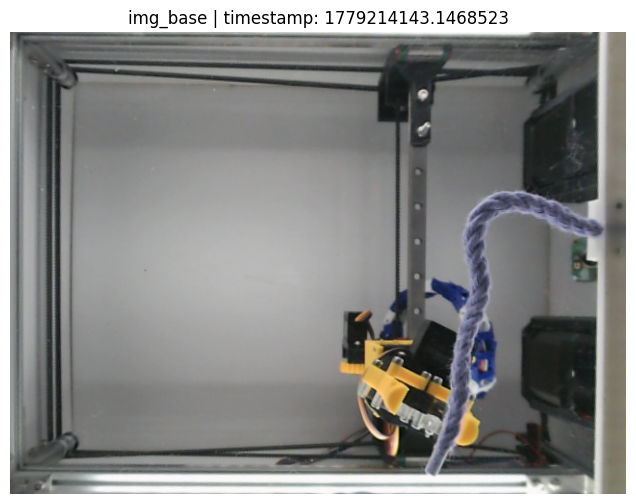

In [7]:
image, timestamp = robot.getImageBaseUndistorted()
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title(f"img_base | timestamp: {timestamp}")
plt.axis("off")
plt.show()

In [1]:
robot.env_reset()

NameError: name 'robot' is not defined